In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

from dask.distributed import LocalCluster
cluster = LocalCluster()          # Fully-featured local Dask cluster
client = cluster.get_client()

client

Python 3.10.18


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 16,Total memory: 62.51 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34381,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:41913,Total threads: 4
Dashboard: http://127.0.0.1:33611/status,Memory: 15.63 GiB
Nanny: tcp://127.0.0.1:35399,


In [2]:
### use numba to speed up the code
from numba import jit

@jit(nopython=True)
def fast_function():
    pass


### Use Memory-Efficient Pandas Operations
import pandas as pd
pd.options.mode.chained_assignment = None  # Disable warnings
pd.set_option("display.float_format", "{:.4f}".format)  # Reduce memory usage



# 1. Workbook setups

## 1.1 Import packages

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import proplot as plot
import cartopy.crs as ccrs
import seaborn as sns

import shapefile as shp
from shapely.geometry import Point, Polygon
import shapely
from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import bayspar as bsr

import string
import os
import requests
import io
from tqdm import tqdm
import time
import h5py
import scipy.io

## 1.2 Miscellaneous codes

In [4]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

def label_pvalues(x):
    if x<0.001:
        return r'$\it{P}$<.001'
    elif x<0.01:
        return r'$\it{P}$<.01'
    elif x<0.05:
        return r'$\it{P}$<.05'
    elif x<0.1:
        return r'$\it{P}$<.1'
    elif x>=0.1:
        return r'$\it{P}$>.1'


## 1.4 Set local paths

In [6]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('nutrient-effect-on-TEX')+len('nutrient-effect-on-TEX')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

# 2. Import data

## 2.1 Processed coretop_df_full


In [7]:
local_github_path

'/home/rrattan/Documents/GitHub/nutrient-effect-on-TEX'

In [8]:
fpath = fr'{local_github_path}/spreadsheets'
fname = 'ds03_processed_coretop_tex.csv'

coretop_df = pd.read_csv(f'{fpath}/{fname}')
exclude_coretop = coretop_df[coretop_df['QC_flag']=='exclude']

display(coretop_df)

,sampleID,index_column,core_name,core_type,sample_depth_start,sample_depth_end,Latitude,Longitude,modernWaterDepth,TEX86,...,thermocline_depth,thermocline_T,thermocline_T_depthIntegral,SSN,thermocline_nitrate,thermocline_nitrate_depthIntegral,region_ID,regionName,pred_tex,tex_residuals
0,RR00001,JET_RR_00001,GeoB7702-3,GC,5.0000,6.0000,31.6517,34.0733,562.0000,0.6620,...,55.0000,19.0069,21.5897,0.0882,0.0039,0.0257,NaN,NaN,0.5933,0.0687
1,RR00002,JET_RR_00002,KNR195-5-5 MC11,MC,6.0000,8.0000,-1.5327,-86.7852,2288.0000,0.6029,...,25.0000,20.8615,22.5202,4.0946,8.3004,5.3182,10.0000,East Equatorial Pacific,0.6032,-0.0003
2,RR00003,JET_RR_00003,KNR195-5-6 MC12,MC,0.0000,1.0000,-3.7105,-81.1153,378.0000,0.5700,...,15.0000,20.7300,22.0932,3.5177,5.8044,4.2084,NaN,NaN,0.5986,-0.0286
3,RR00004,JET_RR_00004,KNR195-5-7 MC16,MC,0.0000,1.0000,-3.7502,-81.1358,379.0000,0.5720,...,15.0000,20.5830,22.0416,4.4152,7.1120,5.3783,NaN,NaN,0.5981,-0.0261
4,RR00005,JET_RR_00005,KNR195-5-8 MC18,MC,4.0000,6.0000,-3.9690,-81.3100,1024.0000,0.5994,...,15.0000,20.1193,21.3194,4.3262,6.4625,4.9695,10.0000,East Equatorial Pacific,0.5904,0.0091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2077,RR02080,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.6000,-65.4000,267.0000,0.4000,...,10.0000,-0.8792,-0.6309,3.0862,3.1556,3.1075,60.0000,Baffin Bay,0.3557,0.0443
2078,RR02081,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.4100,-64.4000,1054.0000,0.3226,...,10.0000,-0.8413,-0.5349,2.9766,3.0433,2.9951,60.0000,Baffin Bay,0.3568,-0.0342
2079,RR02082,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.9700,-59.4900,1012.0000,0.3750,...,10.0000,0.0889,0.3247,2.7838,2.8294,2.7958,60.0000,Baffin Bay,0.3660,0.0090
2080,RR02083,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0000,3.0000,-31.5843,164.4487,2131.0000,0.6712,...,65.0000,19.6539,20.4559,0.4950,0.9179,0.5756,61.0000,Tasman Sea,0.5811,0.0900


In [9]:
import matplotlib.colors as mcolors
##### concatenate three colormaps

colors1 = plot.get_colors('tab10')
colors2 = plot.get_colors('tab20b')
colors3 = plot.get_colors('538')
colors4 = plot.get_colors('tab20c')
colors5 = plot.get_colors('bmh')

combined_cmap = np.concatenate((colors1,colors2,colors3,colors4,colors5))
extended_cmap = mcolors.LinearSegmentedColormap.from_list('my_colormap',combined_cmap)
#########
region_list_full = coretop_df['regionName'].unique()
color_list_full = plot.get_colors(extended_cmap,len(region_list_full))

region_color_dict_full = dict(zip(region_list_full,color_list_full))
region_color_dict_full

region_color_dict_full_rgb = {k:mpl.colors.to_rgba(v) for k,v in region_color_dict_full.items()}
region_color_dict_full_rgb

{nan: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0),
 'East Equatorial Pacific': (0.984313725490196,
  0.5019607843137255,
  0.058823529411764705,
  1.0),
 'Mozambique Channel': (0.2, 0.6078431372549019, 0.17254901960784313, 1.0),
 'Pacific-Southern Ocean': (0.8235294117647058,
  0.16862745098039217,
  0.19215686274509805,
  1.0),
 'Tasman-Antarctica 140E Transect': (0.5764705882352941,
  0.4,
  0.7058823529411765,
  1.0),
 'NZ-SW Pacific': (0.5843137254901961,
  0.34901960784313724,
  0.3411764705882353,
  1.0),
 'Equatorial Pacific': (0.7450980392156863,
  0.47843137254901963,
  0.6627450980392157,
  1.0),
 'West Equatorial Pacific': (0.592156862745098,
  0.592156862745098,
  0.3568627450980392,
  1.0),
 'Tonga-Tropical South Pacific': (0.47058823529411764,
  0.7411764705882353,
  0.4117647058823529,
  1.0),
 'South China Sea': (0.14901960784313725,
  0.5215686274509804,
  0.6666666666666666,
  1.0),
 'Chilean Offshore': (0.26666666666666666,
  0.2745098039215686

In [10]:
regionName_df = coretop_df.pivot_table(index=('region_ID','regionName'),values='TEX86',aggfunc='count').reset_index()[['region_ID','regionName']]
regionID_to_regionName_dict = dict(zip(regionName_df['region_ID'],regionName_df['regionName']))
regionID_to_regionName_dict


{1.0: 'Amundsen Sea',
 2.0: 'Arabian Sea',
 3.0: 'Arctic Ocean',
 4.0: 'Baltic Sea',
 5.0: 'Bering Sea',
 6.0: 'Black Sea',
 7.0: 'Chilean Offshore',
 8.0: 'Chukchi Sea',
 9.0: 'Drake Passage',
 10.0: 'East Equatorial Pacific',
 11.0: 'Eastern Indian Ocean (Offshore Indonesia)',
 12.0: 'Eastern North America Offshore',
 13.0: 'Eastern South America Offshore',
 14.0: 'Greenland Sea',
 15.0: 'Gulf of Aqaba',
 16.0: 'Gulf of California',
 17.0: 'Gulf of Mexico',
 18.0: 'Hudson Bay',
 19.0: 'Indian Ocean Gyre',
 20.0: 'Indonesian Throughflow',
 21.0: 'Japan Sea',
 22.0: 'Kara Sea',
 23.0: 'Laptev Sea',
 24.0: 'Mediterranean',
 25.0: 'Mozambique Channel',
 26.0: 'North Atlantic',
 27.0: 'North Sea',
 28.0: 'Northern Pacific',
 29.0: 'NZ-SW Pacific',
 30.0: 'Pacific-Southern Ocean',
 31.0: 'Red Sea',
 32.0: 'Ross Sea',
 33.0: 'Santa Barbara Bay',
 34.0: 'SE Pacific',
 35.0: 'Sea of Okhotsk',
 36.0: 'South Africa Offshore',
 37.0: 'South Atlantic Gyre',
 38.0: 'South China Sea',
 39.0: 'South

## 2.2 Calculated ocean products

### 2.2.1 WOA23 thermocline-integrated temperatures and thermocline depths

In [12]:
fpath2 = fr'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
ts = xr.open_dataset(os.path.join(fpath2,'woa23_decav91C0_t00_04.nc'),decode_times=False).drop('time')

T_da = ts.isel(time=0).t_an.load()
T_da

<xarray.DataArray 't_an' (depth: 102, lat: 720, lon: 1440)>
array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [-1.6605101, -1.66081  , -1.65491  , ..., -1.6598101,
         -1.66031  , -1.66041  ],
        [-1.66861  , -1.66521  , -1.66721  , ..., -1.66961  ,
         -1.6665   , -1.66871  ],
        [-1.44921  , -1.44921  , -1.44921  , ..., -1.44921  ,
         -1.44921  , -1.44921  ]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
  * depth    (depth) float32 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
Attributes:
    standard_name:  sea_water_temperature
    long_name:      Objectively analyzed mean fields for sea_water_temperatur...
    cell_methods:   area: mean depth: mean time: mean within years time: mean...
    grid_mapping:   crs
    units:          degrees_celsius

In [13]:
from scipy.stats import gamma
### calculate gamma-weighted mean of subT from 0-200m from T_da
T_0_200m = T_da.sel(depth=slice(0,200))

# 1) grab your depth coordinate
depth = T_0_200m["depth"].values  

# 2) compute the gamma PDF at each depth
a = 4.5       # shape
scale = 15.0  # scale (this is your “b”)
pdf = gamma.pdf(depth, a, scale=scale)

w = xr.DataArray(
    pdf,
    coords={"depth": T_0_200m.depth},
    dims=("depth",),
    name="gamma_wt"
)

T_0_200m_gamma_mean = T_0_200m.weighted(w).mean(dim="depth")
T_0_200m_gamma_mean = T_0_200m_gamma_mean.rename('subT_gamma_mean_200m')
T_0_200m_linear_mean = T_0_200m.mean(dim="depth")
T_0_200m_linear_mean = T_0_200m_linear_mean.rename('subT_linear_mean_200m')

In [14]:
coretop_df['subT_gamma_mean_200m'] = np.nan
coretop_df['subT_linear_mean_200m'] = np.nan

for i in tqdm(range(len(coretop_df))):
    lon = coretop_df['Longitude'].iloc[i]
    lat = coretop_df['Latitude'].iloc[i]
    
    try:
        sel_t = T_0_200m_gamma_mean.sel(lon=lon,lat=lat,method='nearest')
        coretop_df['subT_gamma_mean_200m'].iloc[i] = np.atleast_1d(sel_t.values)[0]
    except:
        continue
    
    try:    
        sel_t = T_0_200m_linear_mean.sel(lon=lon,lat=lat,method='nearest')
        coretop_df['subT_linear_mean_200m'].iloc[i] = np.atleast_1d(sel_t.values)[0]
    except:
        continue

exclude_coretop['subT_gamma_mean_200m'] = np.nan
exclude_coretop['subT_linear_mean_200m'] = np.nan

for i in tqdm(range(len(exclude_coretop))):
    lon = exclude_coretop['Longitude'].iloc[i]
    lat = exclude_coretop['Latitude'].iloc[i]
    try:
        sel_t = T_0_200m_gamma_mean.sel(lon=lon,lat=lat,method='nearest')
        exclude_coretop['subT_gamma_mean_200m'].iloc[i] = np.atleast_1d(sel_t.values)[0]
    except:
        continue

    try:
        sel_t = T_0_200m_linear_mean.sel(lon=lon,lat=lat,method='nearest')
        exclude_coretop['subT_linear_mean_200m'].iloc[i] = np.atleast_1d(sel_t.values)[0]
    except:
        continue






100%|██████████| 82/82 [00:00<00:00, 1137.06it/s]


In [16]:
### ocean properties dataset
fpath = fr'{local_github_path}/ncfiles'
fname = 'ds06_calculated_ocean_properties.nc'
ocean_properties_ds = xr.open_dataset(os.path.join(fpath,fname),decode_times=False)
ocean_properties_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

In [17]:
t_sf2tc_da = ocean_properties_ds.t_sf2tc_avg
t_sf2tc_da

<xarray.DataArray 't_sf2tc_avg' (lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [18]:
thermocline_depth_da = ocean_properties_ds.tc_depth
thermocline_depth_da

<xarray.DataArray 'tc_depth' (lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

### 2.2.2 CMEMS thermocline-integrated nitrate concentrations

In [19]:
thermocline_nitrate_da = ocean_properties_ds.no3_sf2tc_avg
thermocline_nitrate_da

<xarray.DataArray 'no3_sf2tc_avg' (lat: 720, lon: 1440)>
[1036800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9

In [20]:
### CMEMS nitrate
fpath = fr'{local_onedrive_path}/Postdoc/Project/TEXAS/netcdf/Copernicus Marine Service/processed-files/Global-Biogeochemistry/climo-monthly/no3'
fname = 'mercatorfreebiorys2v4_global_mean_ANN_199301_202212_climo.nc'

cmems_nitrate_da = xr.open_dataset(os.path.join(fpath,fname),decode_times=False).no3.drop('time')
cmems_nitrate_da

<xarray.DataArray 'no3' (time: 1, depth: 75, latitude: 681, longitude: 1440)>
[73548000 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float32 -80.0 -79.75 -79.5 -79.25 ... 89.5 89.75 90.0
  * depth      (depth) float32 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Dimensions without coordinates: time
Attributes:
    long_name:      Nitrate
    standard_name:  mole_concentration_of_nitrate_in_sea_water
    units:          mmol m-3
    unit_long:      millimoles of Nitrate per cubic meter
    valid_min:      0.0
    valid_max:      59.31268
    cell_methods:   time: mean

## 2.3 Gridded TEX

In [23]:
fpath = fr'{local_github_path}/ncfiles'
fname = 'ds04_gridded_coretop_tex.nc'
gridded_coretop_ds = xr.open_dataset(os.path.join(fpath,fname))
gridded_coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    region_ID      (lon, lat) float64 ...
    tex_count      (lon, lat) float64 ...
    tex_median     (lon, lat) float64 ...
    tex_mean       (lon, lat) float64 ...
    tex_std        (lon, lat) float64 ...
    tex_residuals  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], thermocline-integrated T [degC], dep...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

## 2.4 Gridded amOxRate data

In [25]:
fpath = fr'{local_github_path}/ncfiles'
fname = 'ds05_gridded_AOM_ds.nc'
merged_ammOxR_gridded_ds = xr.open_dataset(os.path.join(fpath,fname))
merged_ammOxR_gridded_ds

<xarray.Dataset>
Dimensions:           (lat: 720, lon: 1440, depth: 55)
Coordinates:
  * lat               (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon               (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * depth             (depth) float32 0.0 5.0 10.0 ... 2.5e+03 3e+03 3.5e+03
Data variables: (12/16)
    ammOxRate_count   (lat, lon, depth) float64 ...
    ammOxRate_median  (lat, lon, depth) float64 ...
    ammOxRate_mean    (lat, lon, depth) float64 ...
    ammOxRate_std     (lat, lon, depth) float64 ...
    NH4_count         (lat, lon, depth) float64 ...
    NH4_median        (lat, lon, depth) float64 ...
    ...                ...
    NO2_mean          (lat, lon, depth) float64 ...
    NO2_std           (lat, lon, depth) float64 ...
    NO3_count         (lat, lon, depth) float64 ...
    NO3_median        (lat, lon, depth) float64 ...
    NO3_mean          (lat, lon, depth) float64 ...
    NO3_std           (lat, lon, depth) float64 ...
Attributes:
    title:             Gridded Ammonia Oxidation Data
    summary:           This dataset contains gridded ammonia oxidation data f...
    data_sources:      Global Ocean Ammonia Oxidation Database (Tang et al. 2...
    processing_level:  Derived product
    history:           Gridded from the original dataset by interpolating to ...
    Conventions:       CF-1.7
    references:        Tang et al. 2023

## 2.5 Global nitrification database by Tang et al. (2023)

In [26]:
fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = r'Weiyi23_EarthSystSciData_nitrification_database.xlsx'

global_AOA_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='ammonia oxidizer')
global_AOA_df = global_AOA_df.rename(
    columns={
        'Depth (m)': 'Depth',
        'shallow clade AOA (copies L-1)': 'shallow_clade_AOA_copiesL', 
        'deep clade AOA (copies L-1)': 'deep_clade_AOA_copiesL',
        'total AOA (copies L-1)': 'total_AOA_copiesL', 
        'Thaumarchaeota 16S rRNA (copies L-1)': 'Thaum_16S_rRNA_copiesL',
        ' βAOB (copies L-1)': 'beta_AOB_copiesL', 
        'shallow clade AOA transcript (copies L-1)': 'shallow_clade_AOA_transcript_copiesL',
        'deep clade AOA transcript (copies L-1)': 'deep_clade_AOA_transcript_copiesL',
        'total AOA transcript (copies L-1)': 'total_AOA_transcript_copiesL', 
        ' βAOB transcript (copies L-1)': 'beta_AOB_transcript_copiesL',
        'PAR (μmol Einstein m-2 s-1)': 'PAR', 
        'Light level (%)': 'light_level', 
        'Temperature (°C)': 'insituT',
        'Salinity (psu)': 'insituS', 
        'Potential density (kg m-3)': 'insituSigmaT', 
        'Ammonium+ammonia (μM)': 'NH4_uM',
        'Nitrite (μM)': 'NO2_uM', 
        'Nitrate (μM)': 'NO3_uM', 
        'O2 (μM)': 'insituOxy'}
    )
global_AOA_df

,Data source,data_source,Date,Latitude,Longitude,Depth,shallow_clade_AOA_copiesL,deep_clade_AOA_copiesL,total_AOA_copiesL,Thaum_16S_rRNA_copiesL,...,PAR,light_level,insituT,insituS,insituSigmaT,NH4_uM,NO2_uM,NO3_uM,pH,insituOxy
0,"Agogue et al., 2008. Nature","Agogue et al., 2008",2002 September,61.6300,-20.8200,2071.0000,2360000,NaN,NaN,78400000,...,NaN,NaN,2.4160,34.9830,27.9240,NaN,NaN,NaN,NaN,292.3000
1,"Agogue et al., 2008. Nature","Agogue et al., 2008",2002 September,61.6300,-20.8200,1633.0000,498000.0000,NaN,NaN,13900000.0000,...,NaN,NaN,3.2630,34.9520,27.8220,NaN,NaN,NaN,NaN,287.4000
2,"Agogue et al., 2008. Nature","Agogue et al., 2008",2002 September,61.6300,-20.8200,1014.0000,2390000,NaN,NaN,135000000,...,NaN,NaN,5.5520,35.0650,27.6600,NaN,NaN,NaN,NaN,247.8000
3,"Agogue et al., 2008. Nature","Agogue et al., 2008",2002 September,61.6300,-20.8200,498.0000,4680000,NaN,NaN,39900000,...,NaN,NaN,7.8250,35.1960,27.4550,NaN,NaN,NaN,NaN,265.9000
4,"Agogue et al., 2008. Nature","Agogue et al., 2008",2002 September,61.6300,-20.8200,99.0000,7080000,NaN,NaN,63100000.0000,...,NaN,NaN,9.0890,35.2280,27.2830,NaN,NaN,NaN,NaN,264.2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,"Zhang et al., 2020. PNAS.","Zhang et al., 2020",2015 April,30.0000,147.0000,500.0000,NaN,NaN,623000,969342.7681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2245,"Zhang et al., 2020. PNAS.","Zhang et al., 2020",2015 April,30.0000,147.0000,650.0000,NaN,NaN,1620000,2356267.4720,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2246,"Zhang et al., 2020. PNAS.","Zhang et al., 2020",2015 April,30.0000,147.0000,750.0000,NaN,NaN,1460000,3740288.1866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2247,"Zhang et al., 2020. PNAS.","Zhang et al., 2020",2015 April,30.0000,147.0000,800.0000,NaN,NaN,1360000,2532082.0546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = r'Weiyi23_EarthSystSciData_nitrification_database.xlsx'

global_AOM_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='volumetric ammonia oxidation')
global_AOM_df = global_AOM_df.rename(
    columns={
        'Depth (m)':'Depth',
        'Rate (nmol N L-1 d-1)':'ammoniaOxidationRate', 
        'Standard deviation of rate (nmol N L-1 d-1)':'AOR_std',
        'PAR (μmol Einstein m-2 s-1)':'PAR',
        'Light level (%)':'light_level',
        'Temperature (°C)':'insituT',
        'Salinity (psu)':'insituS',
        'Potential density (kg m-3)':'insituSigmaT',
        'Ammonium+ammonia (μM)':'NH4_uM',
        'Nitrite (μM)':'NO2_uM',
        'Nitrate (μM)':'NO3_uM',
        'O2 (μM)':'insituOxy'}
    )
global_AOM_df = global_AOM_df.replace(
    {'NM':np.nan,
     'BDL':np.nan,}
)

In [28]:
global_AOM_df['thermocline_depth'] = np.nan

for i in range(len(global_AOM_df)):
    lookup_lat = global_AOM_df['Latitude'][i]
    lookup_lon = global_AOM_df['Longitude'][i]
    
    try:
        thermocline_depth_tmp = thermocline_depth_da.sel(lat=lookup_lat,lon=lookup_lon,method='nearest').values
        global_AOM_df['thermocline_depth'][i] = thermocline_depth_tmp
        
    except:
        continue
    

In [29]:
global_AOM_df['thermocline_depth_position'] = global_AOM_df['Depth']-global_AOM_df['thermocline_depth']

## 2.6 Global sedimentary d15N database by NICOPP (Tesdal et al., 2013)

https://www.ncei.noaa.gov/access/paleo-search/study/14114

### 2.6.1 Coretop dataset

In [30]:
fpath = fr'{local_github_path}/spreadsheets/published_data/NICOPP_d15Nsed_database'
fname = 'NICOPP_coretop_published_130307.mat'

mat_coretop = scipy.io.loadmat(os.path.join(fpath,fname))
print(mat_coretop.keys())
print(mat_coretop['__header__'])

dict_keys(['__header__', '__version__', '__globals__', 'ctop_pub'])
b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu Mar  7 20:13:16 2013'


In [31]:

df_tmp = []
features = ['name','region','ref',
            'lat','lon','depth','d15N',]
for i in range(len(mat_coretop['ctop_pub'][0][0][0])):
    for feature in features:
        if ('name' in feature) or ('region' in feature) or ('ref' in feature):
            try:
                sel_feature = (mat_coretop['ctop_pub'][feature][0][0][i])[0][0]
            except:
                sel_feature = np.nan
        else:
            try:
                sel_feature = (mat_coretop['ctop_pub'][feature][0][0][i])[0]
            except:
                sel_feature = np.nan
        df_tmp.append(sel_feature)
        

### convert df_tmp into a dataframe with 7 columns
coretop_d15N_df = pd.DataFrame(np.reshape(df_tmp, (2176,7)),columns=features)
coretop_d15N_df

### covert datatype of columns
coretop_d15N_df = coretop_d15N_df.astype({'lat':float,'lon':float,'depth':float,'d15N':float})
coretop_d15N_df


,name,region,ref,lat,lon,depth,d15N
0,ODP 1228,Eastern Pacific,Agnihotri et al. (2006),-11.0642,-78.0778,273.0000,5.3506
1,ODP 1229,Iberian Margin,Alt-Epping et al. (2007),38.6345,-9.4542,NaN,5.6000
2,ODP 1230,Iberian Margin,Alt-Epping et al. (2007),38.6250,-9.5083,102.0000,5.8000
3,ODP 1231,Iberian Margin,Alt-Epping et al. (2007),38.6922,-9.2606,19.0000,6.3000
4,ODP 1232,Iberian Margin,Alt-Epping et al. (2007),38.6461,-9.4242,54.0000,6.1000
...,...,...,...,...,...,...,...
2171,EW0408-084 MC-7,Gulf of Alaska,Walinsky et al. (2009),59.5300,-144.1300,686.0000,3.3000
2172,EW0408-091 MC-8,Gulf of Alaska,Walinsky et al. (2009),59.6500,-145.1500,198.0000,2.5000
2173,EW0408-094 MC-8,Gulf of Alaska,Walinsky et al. (2009),60.6600,-147.7100,744.0000,3.7000
2174,EW0408-097 MC-8,Gulf of Alaska,Walinsky et al. (2009),60.5600,-146.7700,401.0000,4.2000


In [32]:
### gridded coretop d15N
mid_lat_array = thermocline_depth_da.lat.values
mid_lon_array = thermocline_depth_da.lon.values

coretop_d15N_df['match_lat'] = [mid_lat_array[np.abs(mid_lat_array-lat).argmin()] for lat in coretop_d15N_df['lat']]
coretop_d15N_df['match_lon'] = [mid_lon_array[np.abs(mid_lon_array-lon).argmin()] for lon in coretop_d15N_df['lon']]

features = ['match_lat','match_lon','d15N']
pregridded_coretop_d15N_df = coretop_d15N_df[features]
pregridded_coretop_d15N_df = pregridded_coretop_d15N_df.dropna().reset_index(drop=True)

new_features = ['d15N_count','d15N_median','d15N_mean','d15N_std']
agg_func_list = ['count','median','mean','std']
for i, new_feature in enumerate(features):
    pregridded_coretop_d15N_df[new_features[i]] = pregridded_coretop_d15N_df.groupby([
        'match_lat','match_lon'])['d15N'].transform(agg_func_list[i])
    
pregridded_coretop_d15N_df = pregridded_coretop_d15N_df.drop_duplicates(
    subset=['match_lat','match_lon'],keep='first').reset_index(drop=True)

coretop_gridded_d15N_da = xr.Dataset.from_dataframe(pregridded_coretop_d15N_df.set_index(['match_lat','match_lon']))
coretop_gridded_d15N_da = coretop_gridded_d15N_da.rename({'match_lon':'lon','match_lat':'lat'})
## nan mask
# coretop_gridded_d15N_da = coretop_gridded_d15N_da.where(coretop_gridded_d15N_da['d15N_count']>1)
coretop_gridded_d15N_da

    
### combine all dataarrays into a single dataset
SST_da = thermocline_depth_da
coretop_gridded_d15N_ds = xr.merge([SST_da,coretop_gridded_d15N_da]).drop_vars(['tc_depth','d15N'])
coretop_gridded_d15N_ds

<xarray.Dataset>
Dimensions:      (lat: 720, lon: 1440)
Coordinates:
  * lat          (lat) float32 -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon          (lon) float32 -179.9 -179.6 -179.4 -179.1 ... 179.4 179.6 179.9
Data variables:
    d15N_count   (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan nan
    d15N_median  (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan nan
    d15N_mean    (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan nan

### 2.6.2 Downcore dataset

In [33]:
fpath = fr'{local_github_path}/spreadsheets/published_data/NICOPP_d15Nsed_database'
fname = 'NICOPP_downcore_published_130307.mat'

mat_data = scipy.io.loadmat(os.path.join(fpath,fname))
print(mat_data.keys())
print(mat_data['__header__'])

dict_keys(['__header__', '__version__', '__globals__', 'core_pub'])
b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu Mar  7 13:22:48 2013'


In [34]:
tmp_df = []
for i in range(len(mat_data['core_pub']['name'][0])):
    core_name = np.squeeze(mat_data['core_pub']['name'][0][i])
    core_lat = np.squeeze(mat_data['core_pub']['lat'][0][i])
    core_lon = np.squeeze(mat_data['core_pub']['lon'][0][i])
    core_depth = np.squeeze(mat_data['core_pub']['depth'][0][i])
    try:
        core_depth = np.atleast_1d(core_depth).astype(float)[0]
    except:
        core_depth = np.nan
    core_ref = np.squeeze(mat_data['core_pub']['ref'][0][i])
    core_acidified = np.squeeze(mat_data['core_pub']['acidified'][0][i])
    
    ### check if age and d15N data are available for the core
    age_len = len(mat_data['core_pub']['age'][0][i])
    d15N_len = len(mat_data['core_pub']['d15N'][0][i])
    mbsf_len = len(mat_data['core_pub']['mbsf'][0][i])
    N_len = len(mat_data['core_pub']['N'][0][i])
    Corg_len = len(mat_data['core_pub']['Corg'][0][i])
    if (age_len == d15N_len) and (age_len>0):
        ### before loop through age and d15N data, check if the core has mbsf, N, and Corg data
        for j in range(age_len):
            age = np.squeeze(mat_data['core_pub']['age'][0][i][j])
            d15N = np.squeeze(mat_data['core_pub']['d15N'][0][i][j])
            
            if mbsf_len==age_len:
                mbsf = np.squeeze(mat_data['core_pub']['mbsf'][0][i][j])
            else:
                ### nan with the same length as age and d15N
                mbsf = np.nan
            
            if N_len==age_len:
                N = np.squeeze(mat_data['core_pub']['N'][0][i][j])
            else:
                ### nan with the same length as age and d15N
                N = np.nan
                
            if Corg_len==age_len:
                Corg = np.squeeze(mat_data['core_pub']['Corg'][0][i][j])
            else:
                ### nan with the same length as age and d15N
                Corg = np.nan
                
            tmp_df.append([core_name,core_lat,core_lon,core_depth,core_ref,core_acidified,age,d15N,mbsf,N,Corg])

downcore_d15N_df = pd.DataFrame(tmp_df, columns=['core_name', 'Latitude', 'Longitude',
                                                 'modernWaterDepth', 'ref', 'acidified',
                                                 'Age', 'd15N', 'mbsf', 'N', 'Corg'])

# Convert columns to appropriate data types
downcore_d15N_df = downcore_d15N_df.astype({
    'core_name': str,
    'Latitude': float,
    'Longitude': float,
    # 'modernWaterDepth': float,
    'ref': str,
    'acidified': str,
    'Age': float,
    'd15N': float,
    'mbsf': float,
    'N': float,
    'Corg': float
})

downcore_d15N_df

,core_name,Latitude,Longitude,modernWaterDepth,ref,acidified,Age,d15N,mbsf,N,Corg
0,AII 125-8 JPC-56,27.4693,-112.1043,818.0000,Pride et al. (1999),n,5.4600,10.9000,1.0100,NaN,NaN
1,AII 125-8 JPC-56,27.4693,-112.1043,818.0000,Pride et al. (1999),n,5.7602,11.2600,1.2500,NaN,NaN
2,AII 125-8 JPC-56,27.4693,-112.1043,818.0000,Pride et al. (1999),n,6.0854,11.5900,1.5100,NaN,NaN
3,AII 125-8 JPC-56,27.4693,-112.1043,818.0000,Pride et al. (1999),n,6.3856,11.4600,1.7500,NaN,NaN
4,AII 125-8 JPC-56,27.4693,-112.1043,818.0000,Pride et al. (1999),n,6.6983,11.7650,2.0000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
33543,ODP 745,-59.5952,85.8600,4082.0000,Billups et al. (2013),n,6395.8000,3.5585,209.0000,NaN,NaN
33544,ODP 745,-59.5952,85.8600,4082.0000,Billups et al. (2013),n,6422.3000,3.8386,210.5000,NaN,NaN
33545,ODP 745,-59.5952,85.8600,4082.0000,Billups et al. (2013),n,6447.0000,2.4970,212.0000,NaN,NaN
33546,ODP 745,-59.5952,85.8600,4082.0000,Billups et al. (2013),n,6469.9000,3.9018,213.5000,NaN,NaN


In [35]:
core_name = [np.squeeze(mat_data['core_pub']['name'][0][i]) for i in range(len(mat_data['core_pub']['name'][0]))]
core_lat = [np.squeeze(mat_data['core_pub']['lat'][0][i]) for i in range(len(mat_data['core_pub']['lat'][0]))]
core_lon = [np.squeeze(mat_data['core_pub']['lon'][0][i]) for i in range(len(mat_data['core_pub']['lon'][0]))]
core_modernWaterDepth = [np.squeeze(mat_data['core_pub']['depth'][0][i]) for i in range(len(mat_data['core_pub']['depth'][0]))]
max_age = []

for i in range(len(mat_data['core_pub']['age'][0])):
    try:
        max_age.append(np.nanmax(np.squeeze(mat_data['core_pub']['age'][0][i])))
    except:
        max_age.append(np.nan)

downcore_d15N_siteInfo_df = pd.DataFrame({'core_name':core_name,
                                  'lat':core_lat,
                                  'lon':core_lon,
                                  'modernWaterDepth':core_modernWaterDepth,
                                  'max_age':max_age})
downcore_d15N_siteInfo_df

,core_name,lat,lon,modernWaterDepth,max_age
0,AII 125-8 GGC-55,27.4703,-112.1055,820,NaN
1,AII 125-8 JPC-44,27.9015,-111.655,655,NaN
2,AII 125-8 JPC-48,27.94,-111.79833,530,NaN
3,AII 125-8 JPC-56,27.4693,-112.1043,818,16.7900
4,SEAX96024-A1C1,41.09888,-73.3317283333333,8.6,NaN
...,...,...,...,...,...
161,RC13-112,-1.2,-101.367,3299,147.0000
162,ODP 849,0.18333333333333332,-110.50166666666667,3839,1101.5586
163,ODP 806,0.319,159.361,2522,1148.0000
164,RNDB-74P,0.3413333333333333,159.37483333333333,2547,155.0000


# 3. Figures for main text

## Fig. 1: Coretop TEX residuals

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class FlatCenterNormalize(Normalize):
    def __init__(self, vmin=None, vmax=None, center=0, plateau_width=0.025, clip=False):
        self.center = center
        self.plateau_width = plateau_width
        super().__init__(vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Process input value(s)
        result, is_scalar = self.process_value(value)
        vmin, vmax = self.vmin, self.vmax
        # Map values in a piecewise linear fashion:
        # vmin --> 0, (center - plateau) --> 0.5, (center + plateau) --> 0.5, vmax --> 1
        mapped = np.ma.masked_array(np.interp(result, 
                    [vmin, self.center - self.plateau_width, self.center + self.plateau_width, vmax],
                    [0, 0.5, 0.5, 1]))
        if is_scalar:
            mapped = mapped[0]
        return mapped


In [37]:
plot_coretop = xr.merge([gridded_coretop_ds,t_sf2tc_da,T_0_200m_gamma_mean,T_0_200m_linear_mean]
                        ).to_dataframe().reset_index().dropna(subset=['tex_residuals','t_sf2tc_avg']).reset_index(drop=True)


plot_coretop['pred_kim12_subt_tex'] = np.nan
for i in tqdm(range(len(plot_coretop))):
    try:
        sel_t = plot_coretop['subT_gamma_mean_200m'].iloc[i]
        slope = 54.7
        intercept = 30.7
        pred_tex86h = (sel_t - intercept)/slope
        plot_coretop['pred_kim12_subt_tex'].iloc[i] = 10**pred_tex86h
    except:
        continue
plot_coretop['pred_bsr_subt_tex'] = np.nan
for i in tqdm(range(len(plot_coretop))):
    try:
        sel_t = plot_coretop['subT_gamma_mean_200m'].iloc[i]
        subt_range = np.arange(sel_t-0.2,sel_t+0.3,0.1)
        sel_lon = plot_coretop['lon'].iloc[i]
        sel_lat = plot_coretop['lat'].iloc[i]
        plot_coretop['pred_bsr_subt_tex'].iloc[i] = np.percentile(bsr.predict_tex(subt_range, lon=sel_lon, lat=sel_lat, temptype='subt').percentile(50),50)
    except:
        continue


plot_coretop

100%|██████████| 1503/1503 [01:31<00:00, 16.46it/s]


,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,tex_residuals,t_sf2tc_avg,subT_gamma_mean_200m,subT_linear_mean_200m,pred_kim12_subt_tex,pred_bsr_subt_tex
0,-77.8750,-40.3750,46.0000,1.0000,0.4136,0.4136,NaN,0.0686,-1.6360,-1.7923,-1.7811,0.2547,0.3580
1,-77.3750,-158.3750,32.0000,1.0000,0.3510,0.3510,NaN,0.0055,-1.5869,-1.6979,-1.6984,0.2557,0.3510
2,-77.1250,-45.3750,46.0000,1.0000,0.3670,0.3670,NaN,0.0226,-1.6926,-1.8509,-1.8275,0.2541,0.3585
3,-76.6250,-35.3750,46.0000,1.0000,0.3360,0.3360,NaN,-0.0105,-1.4989,-1.7279,-1.7009,0.2554,0.3599
4,-76.3750,-33.8750,46.0000,1.0000,0.3423,0.3423,NaN,-0.0025,-1.6512,-1.8045,-1.7870,0.2545,0.3593
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1498,84.8750,40.6250,3.0000,1.0000,0.3340,0.3340,NaN,-0.0138,-1.3739,-1.5600,-1.1958,0.2572,0.3349
1499,86.6250,152.1250,3.0000,1.0000,0.4900,0.4900,NaN,0.1399,-1.1560,-1.5691,-1.3334,0.2571,0.3479
1500,86.8750,-146.1250,3.0000,1.0000,0.4380,0.4380,NaN,0.0913,-1.4774,-1.5597,-1.4344,0.2572,0.3437
1501,87.1250,104.6250,3.0000,1.0000,0.5000,0.5000,NaN,0.1522,-1.3774,-1.6847,-1.3954,0.2558,0.3478


In [38]:
plot_coretop_no3 = xr.merge([gridded_coretop_ds,t_sf2tc_da,thermocline_nitrate_da,T_0_200m_gamma_mean,T_0_200m_linear_mean]
                        ).to_dataframe().reset_index().dropna(subset=['tex_residuals','t_sf2tc_avg','no3_sf2tc_avg']).reset_index(drop=True)


plot_coretop_no3['pred_kim12_subt_tex'] = np.nan
for i in tqdm(range(len(plot_coretop_no3))):
    try:
        sel_t = plot_coretop_no3['subT_gamma_mean_200m'].iloc[i]
        slope = 54.7
        intercept = 30.7
        pred_tex86h = (sel_t - intercept)/slope
        plot_coretop_no3['pred_kim12_subt_tex'].iloc[i] = 10**pred_tex86h
    except:
        continue
plot_coretop_no3['pred_bsr_subt_tex'] = np.nan
for i in tqdm(range(len(plot_coretop_no3))):
    try:
        sel_t = plot_coretop_no3['subT_gamma_mean_200m'].iloc[i]
        subt_range = np.arange(sel_t-0.2,sel_t+0.3,0.1)
        sel_lon = plot_coretop_no3['lon'].iloc[i]
        sel_lat = plot_coretop_no3['lat'].iloc[i]
        plot_coretop_no3['pred_bsr_subt_tex'].iloc[i] = np.percentile(bsr.predict_tex(subt_range, lon=sel_lon, lat=sel_lat, temptype='subt').percentile(50),50)
    except:
        continue

plot_coretop_no3

100%|██████████| 1440/1440 [01:34<00:00, 15.29it/s]


,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,tex_residuals,t_sf2tc_avg,no3_sf2tc_avg,subT_gamma_mean_200m,subT_linear_mean_200m,pred_kim12_subt_tex,pred_bsr_subt_tex
0,-76.6250,-35.3750,46.0000,1.0000,0.3360,0.3360,NaN,-0.0105,-1.4989,28.3656,-1.7279,-1.7009,0.2554,0.3592
1,-76.3750,-33.8750,46.0000,1.0000,0.3423,0.3423,NaN,-0.0025,-1.6512,29.1189,-1.8045,-1.7870,0.2545,0.3597
2,-76.1250,-54.1250,46.0000,2.0000,0.3478,0.3478,0.0091,0.0014,-1.5114,28.1840,-1.7792,-1.7556,0.2548,0.3603
3,-76.1250,-33.6250,46.0000,1.0000,0.3401,0.3401,NaN,-0.0045,-1.6663,28.7775,-1.8214,-1.8003,0.2544,0.3597
4,-75.8750,-29.1250,46.0000,1.0000,0.3558,0.3558,NaN,0.0117,-1.7144,27.7264,-1.6900,-1.7241,0.2558,0.3608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,84.8750,40.6250,3.0000,1.0000,0.3340,0.3340,NaN,-0.0138,-1.3739,7.6658,-1.5600,-1.1958,0.2572,0.3337
1436,86.6250,152.1250,3.0000,1.0000,0.4900,0.4900,NaN,0.1399,-1.1560,7.0598,-1.5691,-1.3334,0.2571,0.3485
1437,86.8750,-146.1250,3.0000,1.0000,0.4380,0.4380,NaN,0.0913,-1.4774,8.3845,-1.5597,-1.4344,0.2572,0.3429
1438,87.1250,104.6250,3.0000,1.0000,0.5000,0.5000,NaN,0.1522,-1.3774,6.8284,-1.6847,-1.3954,0.2558,0.3467


r2 score = 0.7639197678579358
best_window_size = 19


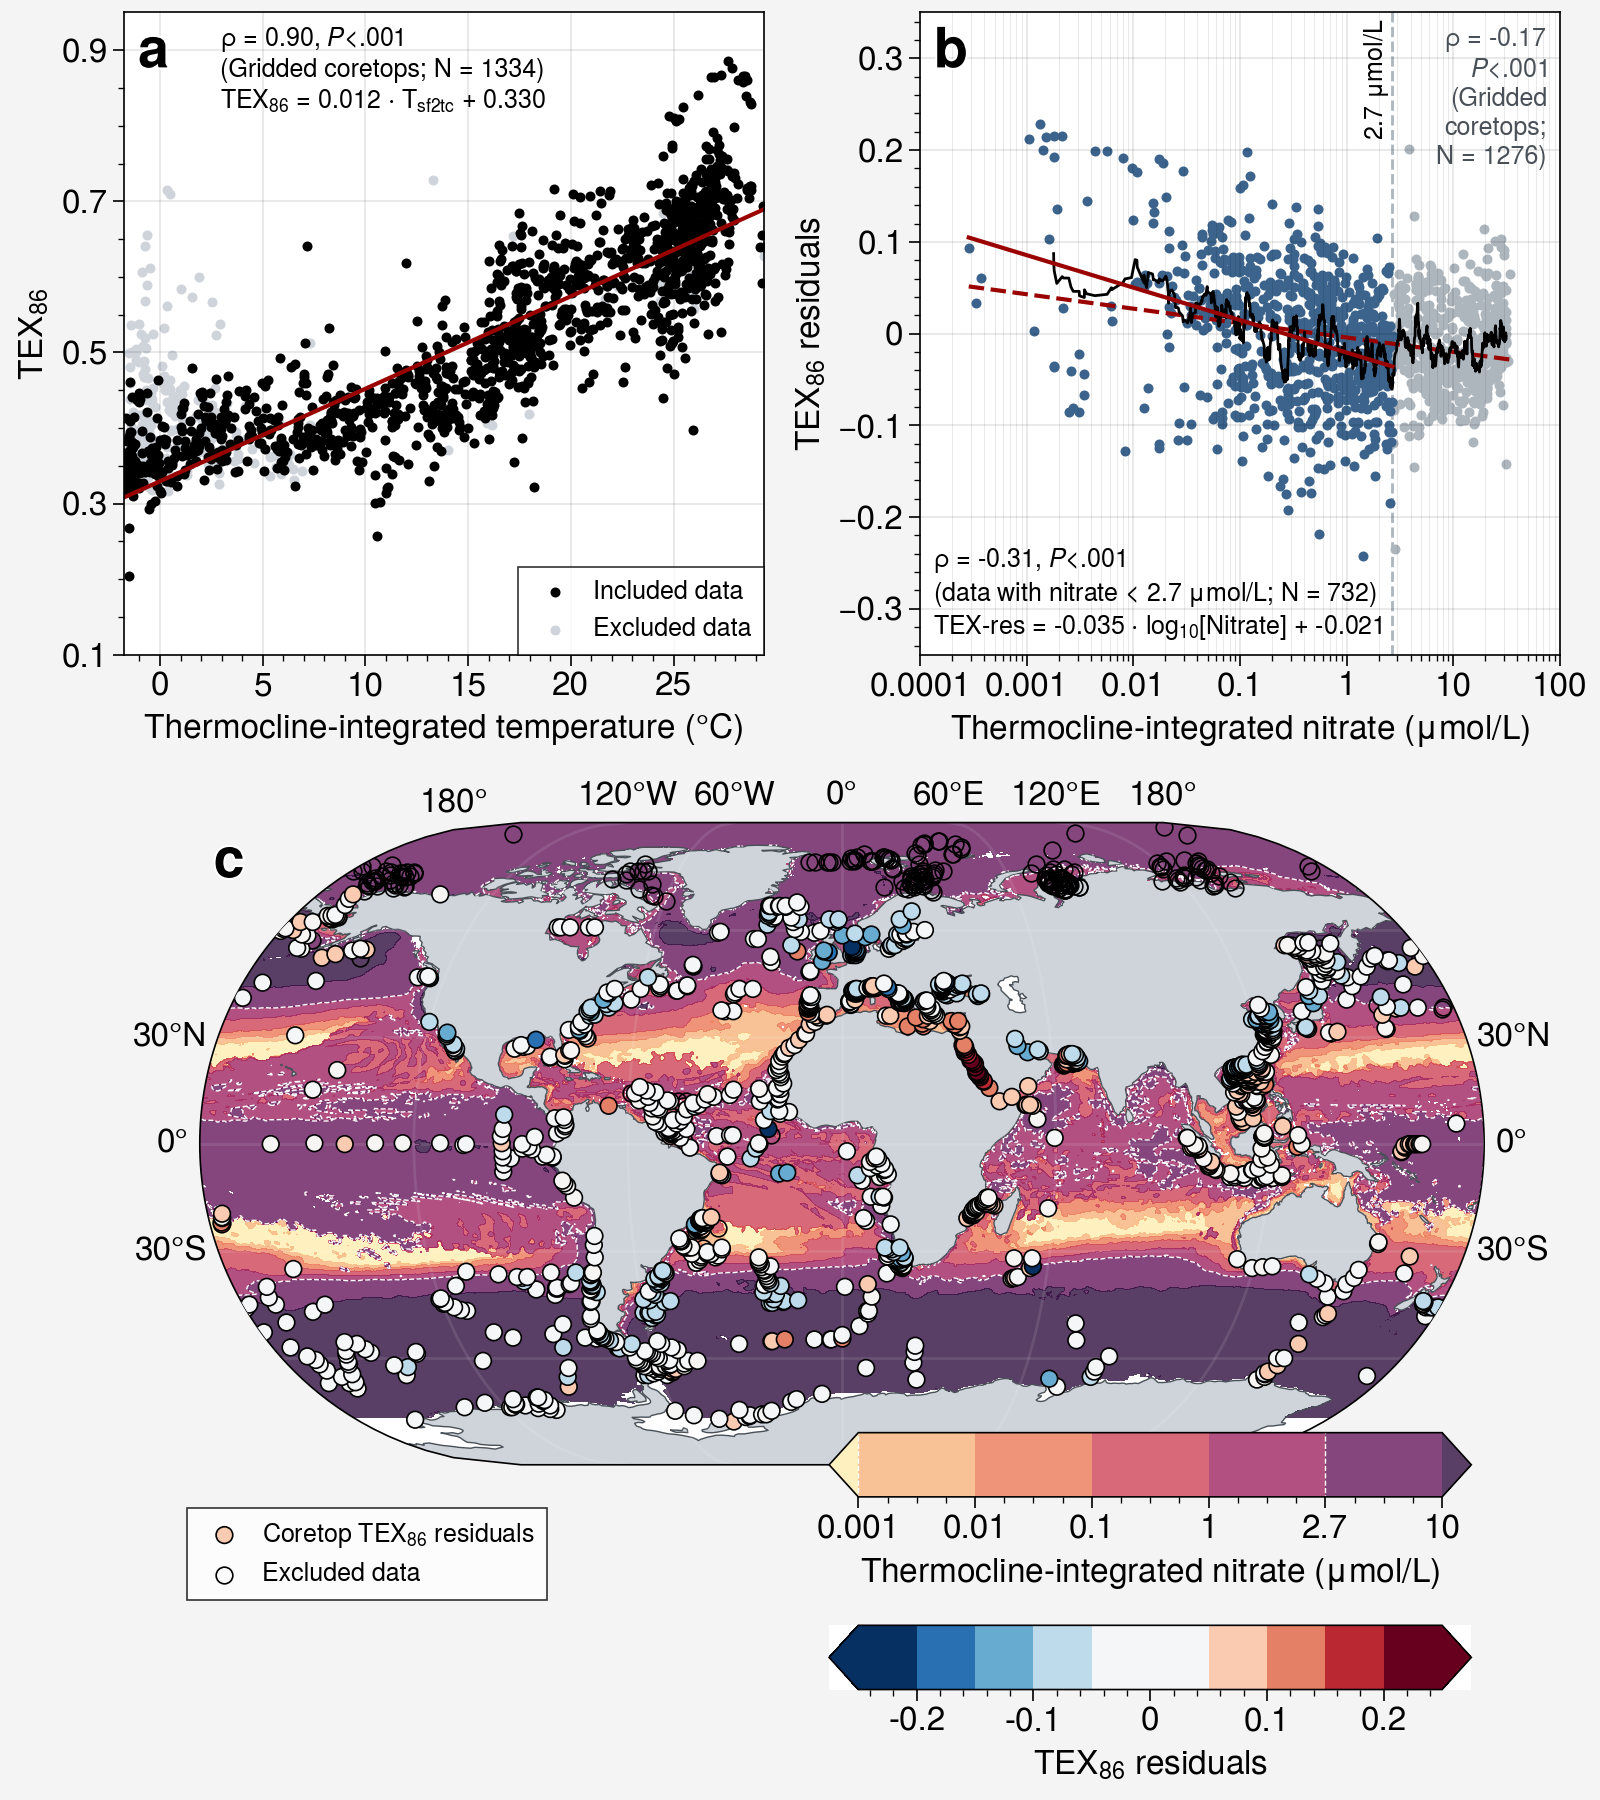

In [39]:
def running_mean_log10(x, y, window_size):
        # Convert x to log10 scale
        log_x = np.log10(x)
        
        # Create a DataFrame with log_x and y
        df = pd.DataFrame({'log_x': log_x, 'y': y})
        
        # Sort the DataFrame by log_x
        df = df.sort_values(by='log_x')
        
        # Calculate the running mean of y with the specified window size
        df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
        
        return df['log_x'], df['y_running_mean']

array = [
    [1,2],
    [3,3]
]
projs = (None,None,'eck3')
fig, axs = plot.subplots(array,proj=projs,
                         figsize=(8,9),
                         share=False,
                         )

axs.format(fontsize=12)

ax = axs[0]
ax.format(
    xlabel='Thermocline-integrated temperature (\N{DEGREE SIGN}C)',
    ylabel='TEX$_{86}$'
)
plot_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['t_sf2tc_avg',
                                                  'tex_median']).reset_index()
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
ax.scatter(plot_x,plot_y,
           m='.',c='k',zorder=2,label='Included data')

plot_data = plot_coretop[plot_coretop['lat']>70].dropna(subset=['t_sf2tc_avg','tex_median'])
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
ax.scatter(plot_x,plot_y,
           m='.',c='gray4',zorder=1,
           label='Excluded data')

plot_x = exclude_coretop['thermocline_T_depthIntegral']
plot_y = exclude_coretop['TEX86']
ax.scatter(plot_x,plot_y,m='.',c='gray4',zorder=0,label='')

reg_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['t_sf2tc_avg','tex_median'])
reg_data2 = reg_data.dropna(subset=['t_sf2tc_avg','tex_median'])
ols_tex_thermoT_thisStudy = LinearRegression()
XX = reg_data2['t_sf2tc_avg']
yy = reg_data2['tex_median']
ols_tex_thermoT_thisStudy.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols_tex_thermoT_thisStudy.predict(XX_sample.reshape(-1,1))
ax.plot(XX_sample,yy_pred,c='deep red')
rho, pval = spearmanr(reg_data2['t_sf2tc_avg'],reg_data2['tex_median'])
### add linear regression equation as text in axs[0]
slope_text = f'{ols_tex_thermoT_thisStudy.coef_[0]:.3f}'
intercept_text = f'{ols_tex_thermoT_thisStudy.intercept_:.3f}'
equation_text = f'TEX$_{{86}}$ = {slope_text} $\cdot$ T$_{{sf2tc}}$ + {intercept_text}'

print(f'r2 score = {ols_tex_thermoT_thisStudy.score(XX.values.reshape(-1,1),yy)}')
pval_label = label_pvalues(pval)
r2_ = ols_tex_thermoT_thisStudy.score(XX.values.reshape(-1,1),yy)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(Gridded coretops; N = {len(reg_data2)})\n{equation_text}',
        transform=ax.transAxes,
        ha='left',va='top')

h, l = ax.get_legend_handles_labels()
ax.legend(h,l,loc='lr',ncols=1)
ax.format(
        ylim=(0.1,0.95),
        yticks=np.arange(0.1,1,0.2),
)
#########################################################################################
ax = axs[1]

plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['no3_sf2tc_avg','tex_residuals'])
reg_data = plot_data
reg_data['log_thermocl_depthIntg_nitrate'] = np.log10(reg_data['no3_sf2tc_avg'])
reg_data['log_thermocl_depthIntg_nitrate'] = reg_data['log_thermocl_depthIntg_nitrate'].replace([-np.inf,np.inf],np.nan)
ols = LinearRegression()
XX = reg_data['log_thermocl_depthIntg_nitrate']
yy = reg_data['tex_residuals']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))
ax.plot(10**XX_sample,yy_pred,c='deep red',ls='--')
rho, pval = spearmanr(reg_data['no3_sf2tc_avg'],reg_data['tex_residuals'])
pval_label = label_pvalues(pval)
r2_ = ols.score(XX.values.reshape(-1,1),yy)
ax.text(0.98,0.98,f'$\\rho$ = {rho:.2f}\n{pval_label}\n(Gridded\ncoretops;\nN = {len(reg_data)})',
        transform=ax.transAxes,
        ha='right',va='top',
        c='gray7')

sel_x_param = 'no3_sf2tc_avg'
sel_y_param = 'tex_residuals'
### linear fit between log(nitrate) and TEX residuals
pre_reg_data = plot_data
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)

### determine best window size
window_size_fig1 = np.arange(5,101,1)
score_list_fig1 = []
pval_list_fig1 = []
for sel_window_size in window_size_fig1:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size)
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
        score_list_fig1.append(rho)
        pval_list_fig1.append(pval)
best_window_size = window_size_fig1[np.argmin(score_list_fig1)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size)
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)
ax.plot(10**log_x,y_running_mean,c='k',lw=1)

plot_x = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_x_param]
plot_y = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_y_param]
ax.scatter(plot_x,plot_y,marker='.',color='denim',label='Coretops')


plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=[sel_x_param,sel_y_param])
plot_x_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_x_param]
plot_y_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_y_param]
ax.scatter(plot_x_exclude,plot_y_exclude,
            marker='.',color='gray5',
            label='Excluded data',zorder=0)


reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold]

reg_data['log_'+sel_x_param] = np.log10(reg_data[sel_x_param])
reg_data['log_'+sel_x_param] = reg_data['log_'+sel_x_param].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=[sel_x_param,sel_y_param,'log_'+sel_x_param])
ols = sm.OLS(reg_data[sel_y_param],sm.add_constant(reg_data['log_'+sel_x_param])).fit()
plot_x_fit = np.linspace(reg_data['log_'+sel_x_param].min(),reg_data['log_'+sel_x_param].max(),100)
plot_y_fit = ols.predict(sm.add_constant(plot_x_fit))
ax.plot(10**plot_x_fit,plot_y_fit,c='deep red',
        label='TEX residuals')

### print regression equation
slope_text = f'{ols.params[1]:.3f}'
intercept_text = f'{ols.params[0]:.3f}'
equation_text = f'TEX-res = {slope_text} $\cdot$ log$_{{10}}$[Nitrate] + {intercept_text}'

rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
pval_label = label_pvalues(pval)
r2_ = ols.rsquared
ax.text(0.02,0.02,
        f'$\\rho$ = {rho:.2f}, {pval_label}\n(data with nitrate < {lowno3_threshold:.1f} $\mu$mol/L; N = {len(reg_data)})\n{equation_text}',
        transform=ax.transAxes,
        ha='left',va='bottom')



ax.format(
    xscale='log',
    xlim=(1e-4,1e2),
    xgridminor=True,
    ylim=(-0.35,0.35),
    xlabel='Thermocline-integrated nitrate ($\mu$mol/L)',
    ylabel='TEX$_{86}$ residuals'
)
#########################################################################################
ax = axs[2]
ax.format(land=True, landcolor='gray4',landzorder=0,
        latlabels='lr', lonlabels='top',
        gridcolor='w',gridlinewidth=1,
        latlines=30,
        latlocator=[-60,-30,0,30,60],
        coast=True, coastcolor='gray7',
        coastlinewidth=0.5,
        coastzorder=1,
        labelsize=12)
##### plot a contour line of thermocline-integrated nitrate at lowno3_threshold μM
m = thermocline_nitrate_da.plot.contourf(ax=ax,levels=[1e-3,1e-2,1e-1,1,lowno3_threshold,10],
                                        cmap='matter',alpha=0.8,
                                        add_colorbar=False,robust=True,
                                        label=None,rasterized=True)

axins1 = inset_axes(
    ax,
    width="50%",
    height="10%",
    loc="lower right",
    bbox_to_anchor=(-0.01,-0.05,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

axins1.patch.set_alpha(0)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",)
cbar.set_label('Thermocline-integrated nitrate ($\mu$mol/L)', size=12)
axins1.xaxis.set_ticklabels(['0.001','0.01','0.1','1',f'{lowno3_threshold}','10'])
cbar.ax.tick_params(labelsize=12)
m2 = thermocline_nitrate_da.plot.contour(ax=ax,levels=[0,lowno3_threshold],
                                                 linewidths=0.5,
                                                 linestyles='dashed',
                                                 colors='w',robust=True)
cbar.add_lines(m2)
cbar.lines[0].set_linestyle('dashed')

ax.set_title('')
###### plot tex residuals on map

plot_x = exclude_coretop['Longitude']
plot_y = exclude_coretop['Latitude']
ax.scatter(plot_x,plot_y,m='o',mec='k',facecolor='none',zorder=2,label='')

plot_data = plot_coretop[plot_coretop['lat']>70][['lon','lat','tex_median']].dropna(subset=['tex_median'])
plot_x = plot_data['lon']
plot_y = plot_data['lat']
ax.scatter(plot_x,plot_y,
           m='o',mec='k',facecolor='none',zorder=2,
           label='Excluded data')

plot_data = plot_coretop[plot_coretop['lat']<70][['lon','lat','tex_residuals']].dropna()
plot_x = plot_data['lon']
plot_y = plot_data['lat']
plot_c = plot_data['tex_residuals']

norm = FlatCenterNormalize(vmin=-0.2, vmax=0.2, center=0, plateau_width=0.025)
m=ax.scatter(plot_x,plot_y,
           c=plot_c, 
           norm=norm,
           mec='k',
           levels=10,
        #    levels=np.arange(-0.2,0.21,0.02),
           transform=ccrs.PlateCarree(),
           m='o',cmap='burd',
           label='Coretop TEX$_{86}$ residuals',
           zorder=3)

h,l = axs[2].get_legend_handles_labels()

ax.legend(h[::-1],l[::-1],loc='lower left',
          bbox_to_anchor=(-0.01,-0.21,1,1),
          ncols=1)

axins1 = inset_axes(
    ax,
    width="50%",
    height="10%",
    loc="lower right",
    bbox_to_anchor=(-0.01,-0.35,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",
             extend='both')
cbar.set_label('TEX$_{86}$ residuals', size=12)
cbar.ax.tick_params(labelsize=12)
cbar.ax.xaxis.set_ticks(np.arange(-0.2,0.21,0.1))
cbar.ax.xaxis.set_ticklabels(['-0.2','-0.1','0','0.1','0.2'])



#########################################################################################
axs.format(abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':20},)


fpath = fr'{local_github_path}/figures/'
fname = 'gridded_coretops_regression_nitrate_effect_global.png'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

In [40]:
import pickle
# Save the regression model to a pickle file
with open(os.path.join(fpath,'ols_tex_thermoT_thisStudy.pkl'), 'wb') as f:
    pickle.dump(ols_tex_thermoT_thisStudy, f)

## Fig. 2: Regional nutrient effects

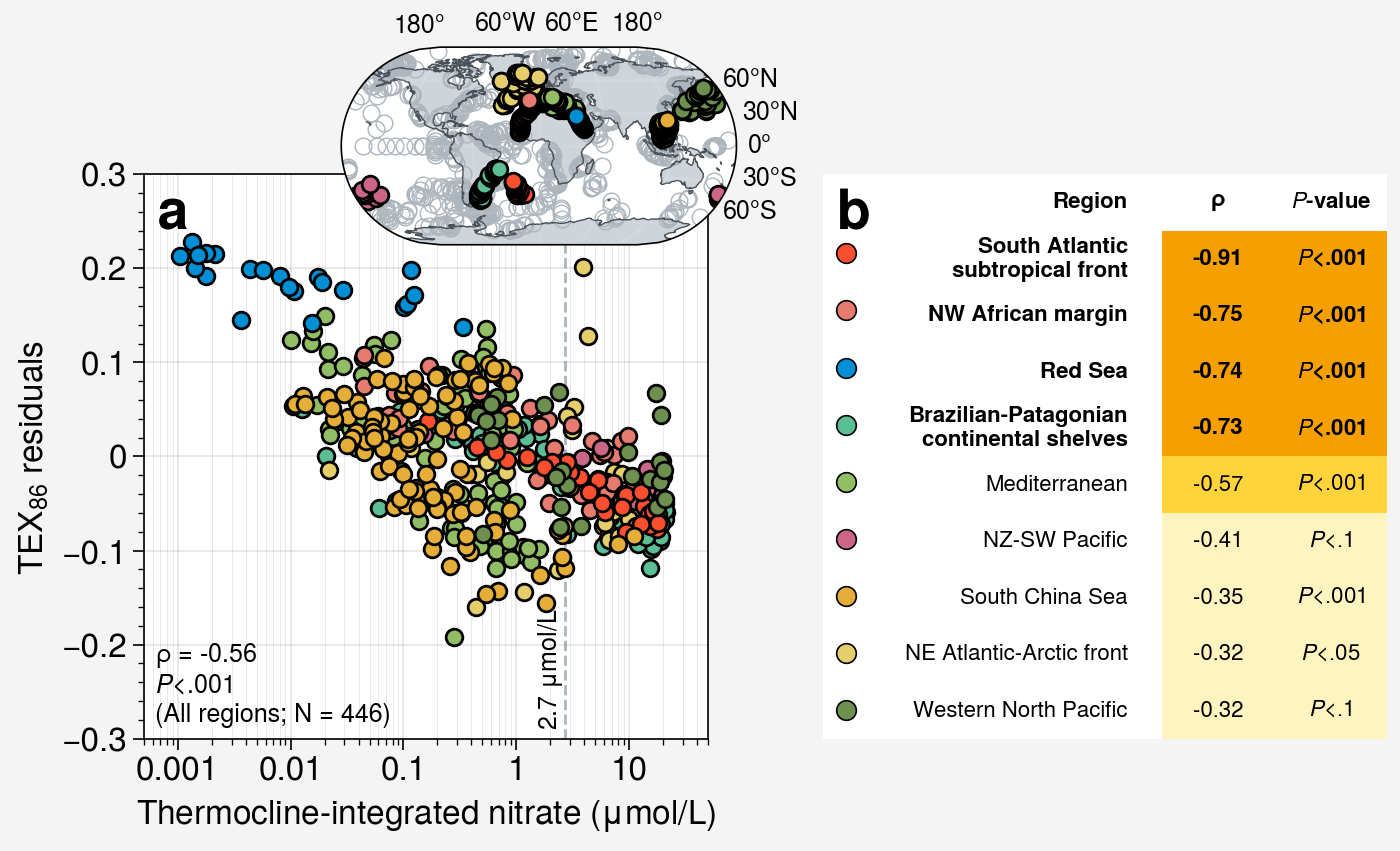

In [41]:
# array = [
#     [1,1,2,2],
#     [1,1,2,2]
# ]
cyc1 = plot.get_colors('qual1',N=5)
cyc2 = plot.get_colors('538',N=5)

sel_cyc = plot.Cycle(cyc1+cyc2)
### param for plotting
optimal_pval_cutoff = 0.1
nitrate_cutoff = 100

fig, axs = plot.subplots(ncols=2,
                         share=0,
                         width=7)
axs.format(fontsize=12)
plot_data = xr.merge([gridded_coretop_ds,t_sf2tc_da,thermocline_nitrate_da,coretop_gridded_d15N_ds])
plot_gridded_data = plot_data[['lat','lon','t_sf2tc_avg','no3_sf2tc_avg',
                                'tex_median','tex_residuals','tex_std',
                                'd15N_mean','region_ID']].to_dataframe().dropna(subset=['region_ID']).reset_index()
plot_gridded_data['regionName'] = plot_gridded_data['region_ID'].map(regionID_to_regionName_dict)
plot_gridded_data['regionName'] = plot_gridded_data['regionName'].replace({
    'Eastern Indian Ocean (Offshore Indonesia)' : 'Indonesian Offshore',
    'Northern Pacific':'Western North Pacific',
    'Eastern South America Offshore':'Brazilian-Patagonian\ncontinental shelves',
    'South Atlantic Gyre':'South Atlantic\nsubtropical front',
    'Tropical West African Offshore':'NW African margin',
    'North Atlantic':'NE Atlantic-Arctic front',
})

plot_gridded_data = plot_gridded_data[plot_gridded_data['no3_sf2tc_avg']<nitrate_cutoff]

# Create an inset axis overlapping on the top right corner of axs[0]
ax_inset = axs[0].inset_axes([0.35, 0.7, 0.7, 0.7],proj='eck3')

ax_inset.format(land=True, landcolor='gray4',landzorder=0,
        latlabels='r', lonlabels='top',
        gridcolor='w',gridlinewidth=1,
        latlocator=[-60,-30,0,30,60],
        coast=True, coastcolor='gray7',
        coastlinewidth=0.5,
        coastzorder=1,)
grouped = plot_gridded_data.groupby('regionName')

#### calculate rho and pval between tex_residuals and thermocl_depthIntg_nitrate by regions
rho_list = []
pval_list = []
region_name_list = []
for name, group in grouped:
    reg_data = group[['no3_sf2tc_avg', 'tex_residuals']].dropna()
    if len(reg_data) < 10:
        continue
    else:
        rho, pval = spearmanr(reg_data['no3_sf2tc_avg'], reg_data['tex_residuals'])
        rho_pearson, pval_pearson = pearsonr(reg_data['no3_sf2tc_avg'], reg_data['tex_residuals'])
        region_name_list.append(name)
        rho_list.append(rho)
        pval_list.append(pval)

### build a dataframe to sort by rho
rho_df = pd.DataFrame({'regionName': region_name_list,
                       'rho': rho_list,
                       'pval': pval_list})

sig_regions_ = rho_df[((rho_df['pval'] < optimal_pval_cutoff)
                       & (rho_df['rho'] < 0))]

sig_regions_ = rho_df[((rho_df['pval'] < optimal_pval_cutoff)
                       & (rho_df['rho'] < 0))][rho_df['regionName'].isin([
                           'Weddell Sea', 'Arctic Ocean', 'Drake Passage',
                           'Kara Sea', 'Greenland Sea',
                           'Laptev Sea',
                           'Sea of Okhotsk',
                        #    'Eastern South America Offshore_far'
                           ]) == False]
sig_regions_color_dict = dict(zip(sig_regions_['regionName'], plot.get_colors(sel_cyc, N=len(sig_regions_))))

for name, group in grouped:
    ### check rho and pval of each region
    if name not in sig_regions_['regionName'].unique():
        ax_inset.scatter(group['lon'], group['lat'],
                         c='none',
                         mec='gray5', mew=0.5,
                         label=name,
                         zorder=1)
    else:
        rho_ = rho_df[rho_df['regionName'] == name]['rho'].values[0]
        pval_ = rho_df[rho_df['regionName'] == name]['pval'].values[0]

        if (pval_ < optimal_pval_cutoff
            and (rho_ < 0)
            and name != 'Weddell Sea'
            and name != 'Arctic Ocean'
            and name != 'Drake Passage'
            and name != 'Kara Sea'
            and name != 'Greenland Sea'
            and name != 'Laptev Sea'
            and name != 'Sea of Okhotsk'
            # and name != 'Eastern South America Offshore_far'
            ):
            ax_inset.scatter(group['lon'], group['lat'],
                            #  cycle=sel_cyc,
                             c=sig_regions_color_dict.get(name, 'gray5'),
                             mec='k', mew=1,
                             label=name,
                             zorder=2)
            
ax = axs[0]
sig_plot_data = plot_gridded_data[plot_gridded_data['regionName'].isin(sig_regions_['regionName'])]
grouped = sig_plot_data.groupby('regionName')   
for name, group in grouped:
    ### plot data
    ax.scatter(group['no3_sf2tc_avg'],group['tex_residuals'],
                cycle=sel_cyc,
                mec='k',mew=1,
                label=name,
                zorder=2)
    
### add low-nitrate threshold
ax.axvline(lowno3_threshold,color='gray5',ls='--',lw=1,zorder=0)
### add vertical text 
x_pos = lowno3_threshold
y_pos = -0.29
ax.text(x_pos,y_pos,f'{lowno3_threshold:.1f} $\mu$mol/L',
        # transform=ax.get_xaxis_transform(),
        ha='right',va='bottom',
        rotation=90)
    
### ols regression of all significant regions
reg_data = sig_plot_data[['no3_sf2tc_avg','tex_residuals']].dropna()
reg_data['Log10_nitrate'] = np.log10(reg_data['no3_sf2tc_avg'])
ols = LinearRegression()
XX = reg_data['Log10_nitrate']
yy = reg_data['tex_residuals']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))
# ax.plot(10**XX_sample,yy_pred,c='deep red')
### spearman rho and pval
rho, pval = spearmanr(reg_data['no3_sf2tc_avg'],reg_data['tex_residuals'])
pval_label = label_pvalues(pval)
ax.text(0.02,0.02,f'$\\rho$ = {rho:.2f}\n{pval_label}\n(All regions; N = {len(reg_data)})',
        transform=ax.transAxes,
        ha='left',va='bottom')

### orthoganal distance regression 
X = reg_data['Log10_nitrate']
y = reg_data['tex_residuals']
covx = np.cov(X)
covy = np.cov(y)
odr_dat = scipy.odr.Data(X,y)
def linear_func(B, x):
    '''Linear function y = m*x + b'''
    # B is a vector of the parameters.
    # x is an array of the current x values.
    # x is in the same format as the x passed to Data or RealData.
    #
    # Return an array in the same format as y passed to Data or RealData.
    return B[0]*x + B[1]
odr_func = scipy.odr.Model(linear_func)
odr = scipy.odr.ODR(odr_dat,odr_func,beta0=[-2.,0.2])
out = odr.run()
slope = out.beta[0]
intercept = out.beta[1]
X_pred = np.linspace(X.min(),X.max(),100)
y_pred = linear_func(out.beta,X_pred)
# ax.plot(10**X_pred,y_pred,c='k',ls='--',lw=2,label='ODR fit')

ax.format(
    xlabel='Thermocline-integrated nitrate ($\mu$mol/L)',
    ylabel='TEX$_{86}$ residuals',
    xlim=(5e-4,5e1),
    xscale='log',
    xgridminor=True,
    ylim=(-0.3,0.3),
)


axs.format(
    abc='a',rc_kw={'abc.size':20},abcloc='ul',
)

### plot a table reporting rho and pval of significant regions
table_ax = axs[1]
table_ax.axis('off')
table_data = sig_regions_[['regionName','rho','pval']]

### formatted values to be displayed in the table as 4 significant figures
table_data['rho'] = table_data['rho'].apply(lambda x: f'{x:.2f}')
table_data['pval'] = table_data['pval'].apply(lambda x: f'{x:.4f}')
table_data['pval_labels'] = table_data['pval'].apply(lambda x: label_pvalues(float(x)))
table_data = table_data.rename(columns={'regionName':'Region',
                                        'rho':'$\\rho$',
                                        'pval_labels':r'$\it{P}$-value'})


table_data2 = table_data[['Region','$\\rho$',r'$\it{P}$-value']].sort_values(by='$\\rho$',ascending=False).copy()
### color cell with rho < -0.7
### set header text bold
### set header background color
# Define the number of rows and columns in the table
num_rows, num_cols = table_data2.shape

# Create a list for cell colors, keeping the first column (Region) white
cell_colors = [['white'] * num_cols for _ in range(num_rows)]

# Apply colors only to the second and third columns based on rho values
for i, rho in enumerate(table_data2['$\\rho$']):
    rho_value = float(rho)
    color = (
        'yellow7' if rho_value < -0.7 else 
        'yellow4' if rho_value < -0.5 else 
        'yellow1'
    )
    cell_colors[i][1] = color  # Apply color to the rho column
    cell_colors[i][2] = color  # Apply the same color to the p-value column

table = table_ax.table(cellText=table_data2.values,
                colLabels=table_data2.columns,
                loc='top',
                bbox=[0,0,1,1],
                colWidths=[0.6,0.2,0.2],
                cellColours=cell_colors,
                fontsize=12
                )

# Style table text
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.get_text().set_fontweight('bold')
    if col == 0:
        cell.get_text().set_ha('right')  # Align first column to the right
        if row > 0:
            region_name = table_data2.iloc[row-1]['Region'][2:]  
    else:
        cell.get_text().set_ha('center')
        if col == 1 and row > 0:
            if float(cell.get_text().get_text()) < -0.7:
                table[(row, 0)].get_text().set_fontweight('bold')
                table[(row, 1)].get_text().set_fontweight('bold')                
                table[(row, 2)].get_text().set_fontweight('bold')
    
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.5, 1.5)
#change table line color to white
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)

# Add colored markers manually using scatter()
num_rows = len(table_data2)
x_offset = -0.15  # Adjust this to position the circles
y_offset = np.linspace(0.86, 0.05, num_rows)  # Evenly space markers in the column

for i, region in enumerate(table_data2['Region']):
    color = sig_regions_color_dict.get(region, 'black')  # Default to black if not found
    table_ax.scatter(x_offset, y_offset[i], color=color, s=50, edgecolor='k', zorder=3)
    


table_ax.set_xlim(-0.2, 1)  # Adjust limits to ensure markers are visible
table_ax.set_ylim(0, 1)

fpath = fr'{local_github_path}/figures/'
fname = 'gridded_regional_nitrate_effect_sig_regions.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=1440)

## Fig. 3: Paleo case study - Arabian Sea

In [42]:
fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'Seierstad2014_NGRIP_d18O_dataset.xlsx'

### data sheet name is "4) d18O and Ca 50 yrs mean"
### data starts from line 6
### header is in line 4
ngrip_df = pd.read_excel(os.path.join(fpath,fname),sheet_name="3) d18O and Ca 20 yrs mean",skiprows=51)

### grab column names from line 4 in the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name="3) d18O and Ca 20 yrs mean",skiprows=49)
header = header.iloc[0,:].values

### add column names to dataframe
ngrip_df.columns = header
ngrip_df = ngrip_df[ngrip_df['Age']<20000]
ngrip_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1996
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1997 non-null   int64  
 1   NGRIP1 depth   980 non-null    float64
 2   d18O NGRIP1    980 non-null    float64
 3   NGRIP2 depth   1045 non-null   float64
 4   d18O NGRIP2    1045 non-null   float64
 5   [Ca2+] NGRIP2  965 non-null    float64
 6   GRIP depth     1997 non-null   float64
 7   d18O GRIP      1997 non-null   float64
 8   [Ca2+] GRIP    1201 non-null   float64
 9   GISP2 depth    1989 non-null   float64
 10  d18O GISP2     1951 non-null   float64
 11  [Ca2+] GISP2   1989 non-null   float64
 12  MCE            1997 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 218.4 KB


In [43]:
import bayspline as bsl

#### read data from tab file to pandas dataframe; data starts after the last line with */

fpath = fr'{local_github_path}/spreadsheets/published_data/Huguet2006_ArabianSea_paleorecords'
fname = 'SO42-74KL_SST.tab'

with open(os.path.join(fpath,fname),'r') as f:
    lines = f.readlines()
    
for i,line in enumerate(lines):
    if line.startswith('*/'):
        break
# header = lines[i+1].split()
data = lines[i+2:]
data = [line.split() for line in data]
df = pd.DataFrame(data,columns=['Age_kaBP','SST_UK37','SST_TEX86'])
SO42_75KL_SST_df = df.apply(pd.to_numeric,errors='ignore')
SO42_75KL_SST_df['uk37'] = 0.033*SO42_75KL_SST_df['SST_UK37']+0.044
SO42_75KL_SST_df['sst'] = bsl.predict_sst(SO42_75KL_SST_df['uk37'], prior_std=10).percentile(50)
SO42_75KL_SST_df

100%|██████████| 500/500 [00:13<00:00, 37.87it/s]


,Age_kaBP,SST_UK37,SST_TEX86,uk37,sst
0,0.2000,27.3000,26.3900,0.9449,28.5093
1,0.4000,27.3600,27.4700,0.9469,28.6358
2,0.6000,27.2700,27.1300,0.9439,28.4005
3,0.8200,27.3600,26.8200,0.9469,28.5898
4,1.0300,27.1200,27.8100,0.9390,28.1095
...,...,...,...,...,...
71,20.2900,25.1200,25.2100,0.8730,24.7723
72,20.9000,24.8500,23.9300,0.8641,24.4093
73,21.5000,25.0900,23.7800,0.8720,24.7526
74,22.1100,25.1500,25.0200,0.8740,24.8081


In [44]:
#### read data from tab file to pandas dataframe; data starts after the last line with */

fpath = fr'{local_github_path}/spreadsheets/published_data/Huguet2006_ArabianSea_paleorecords'
fname = 'NIOP-C2_905_PC_SST.tab'

with open(os.path.join(fpath,fname),'r') as f:
    lines = f.readlines()
    
for i,line in enumerate(lines):
    if line.startswith('*/'):
        break
# header = lines[i+1].split()
data = lines[i+2:]
data = [line.split() for line in data]
df = pd.DataFrame(data,columns=['Age_kaBP','SST_UK37','SST_TEX86'])
NIOP905_SST_df = df.apply(pd.to_numeric,errors='ignore')
NIOP905_SST_df ['uk37'] = 0.033*NIOP905_SST_df['SST_UK37']+0.044
NIOP905_SST_df ['sst'] = bsl.predict_sst(NIOP905_SST_df['uk37'], prior_std=10).percentile(50)
NIOP905_SST_df

100%|██████████| 500/500 [00:14<00:00, 34.87it/s]


,Age_kaBP,SST_UK37,SST_TEX86,uk37,sst
0,0.0190,26.3000,25.7100,0.9119,26.6184
1,0.2080,26.3300,26.2400,0.9129,26.6858
2,0.3970,26.3300,25.7900,0.9129,26.6439
3,0.5860,26.4900,26.0900,0.9182,26.9560
4,0.7820,26.4200,26.4200,0.9159,26.8501
...,...,...,...,...,...
106,21.9060,25.0900,22.5900,0.8720,24.7417
107,22.1640,25.4900,22.4700,0.8852,25.2895
108,22.4220,25.3900,NaN,0.8819,25.1438
109,22.6800,25.7700,NaN,0.8944,25.7142


In [45]:
NIOP905_SST_df

,Age_kaBP,SST_UK37,SST_TEX86,uk37,sst
0,0.0190,26.3000,25.7100,0.9119,26.6184
1,0.2080,26.3300,26.2400,0.9129,26.6858
2,0.3970,26.3300,25.7900,0.9129,26.6439
3,0.5860,26.4900,26.0900,0.9182,26.9560
4,0.7820,26.4200,26.4200,0.9159,26.8501
...,...,...,...,...,...
106,21.9060,25.0900,22.5900,0.8720,24.7417
107,22.1640,25.4900,22.4700,0.8852,25.2895
108,22.4220,25.3900,NaN,0.8819,25.1438
109,22.6800,25.7700,NaN,0.8944,25.7142


In [46]:
slope = ols_tex_thermoT_thisStudy.coef_[0]
intercept = ols_tex_thermoT_thisStudy.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)

NIOP905_tex_df = PhanSST_df[PhanSST_df['SiteName']=='NIOP-C2_905_PC'].reset_index(drop=True)
NIOP905_tex_df['subT'] = (NIOP905_tex_df['ProxyValue'] - intercept)/slope
NIOP905_tex_df['subT_kim12_0_200m'] = (np.log10(NIOP905_tex_df['ProxyValue']) * 54.7) + 30.7
NIOP905_tex_df['subT_bsr'] = bsr.predict_seatemp(NIOP905_tex_df['ProxyValue'], 
                                                lon=NIOP905_tex_df['ModLon'].unique(),
                                                lat=NIOP905_tex_df['ModLat'].unique(),
                                                prior_std=6,
                                                temptype='subt').percentile(50)

SO42_75KL_tex_df = PhanSST_df[PhanSST_df['SiteName']=='SO42-74KL'].reset_index(drop=True)
SO42_75KL_tex_df['subT'] = (SO42_75KL_tex_df['ProxyValue'] - intercept)/slope
SO42_75KL_tex_df['subT_kim12_0_200m'] = (np.log10(SO42_75KL_tex_df['ProxyValue']) * 54.7) + 30.7
SO42_75KL_tex_df['subT_bsr'] = bsr.predict_seatemp(SO42_75KL_tex_df['ProxyValue'],
                                                lon=SO42_75KL_tex_df['ModLon'].unique(),
                                                lat=SO42_75KL_tex_df['ModLat'].unique(),
                                                prior_std=6,
                                                temptype='subt').percentile(50)

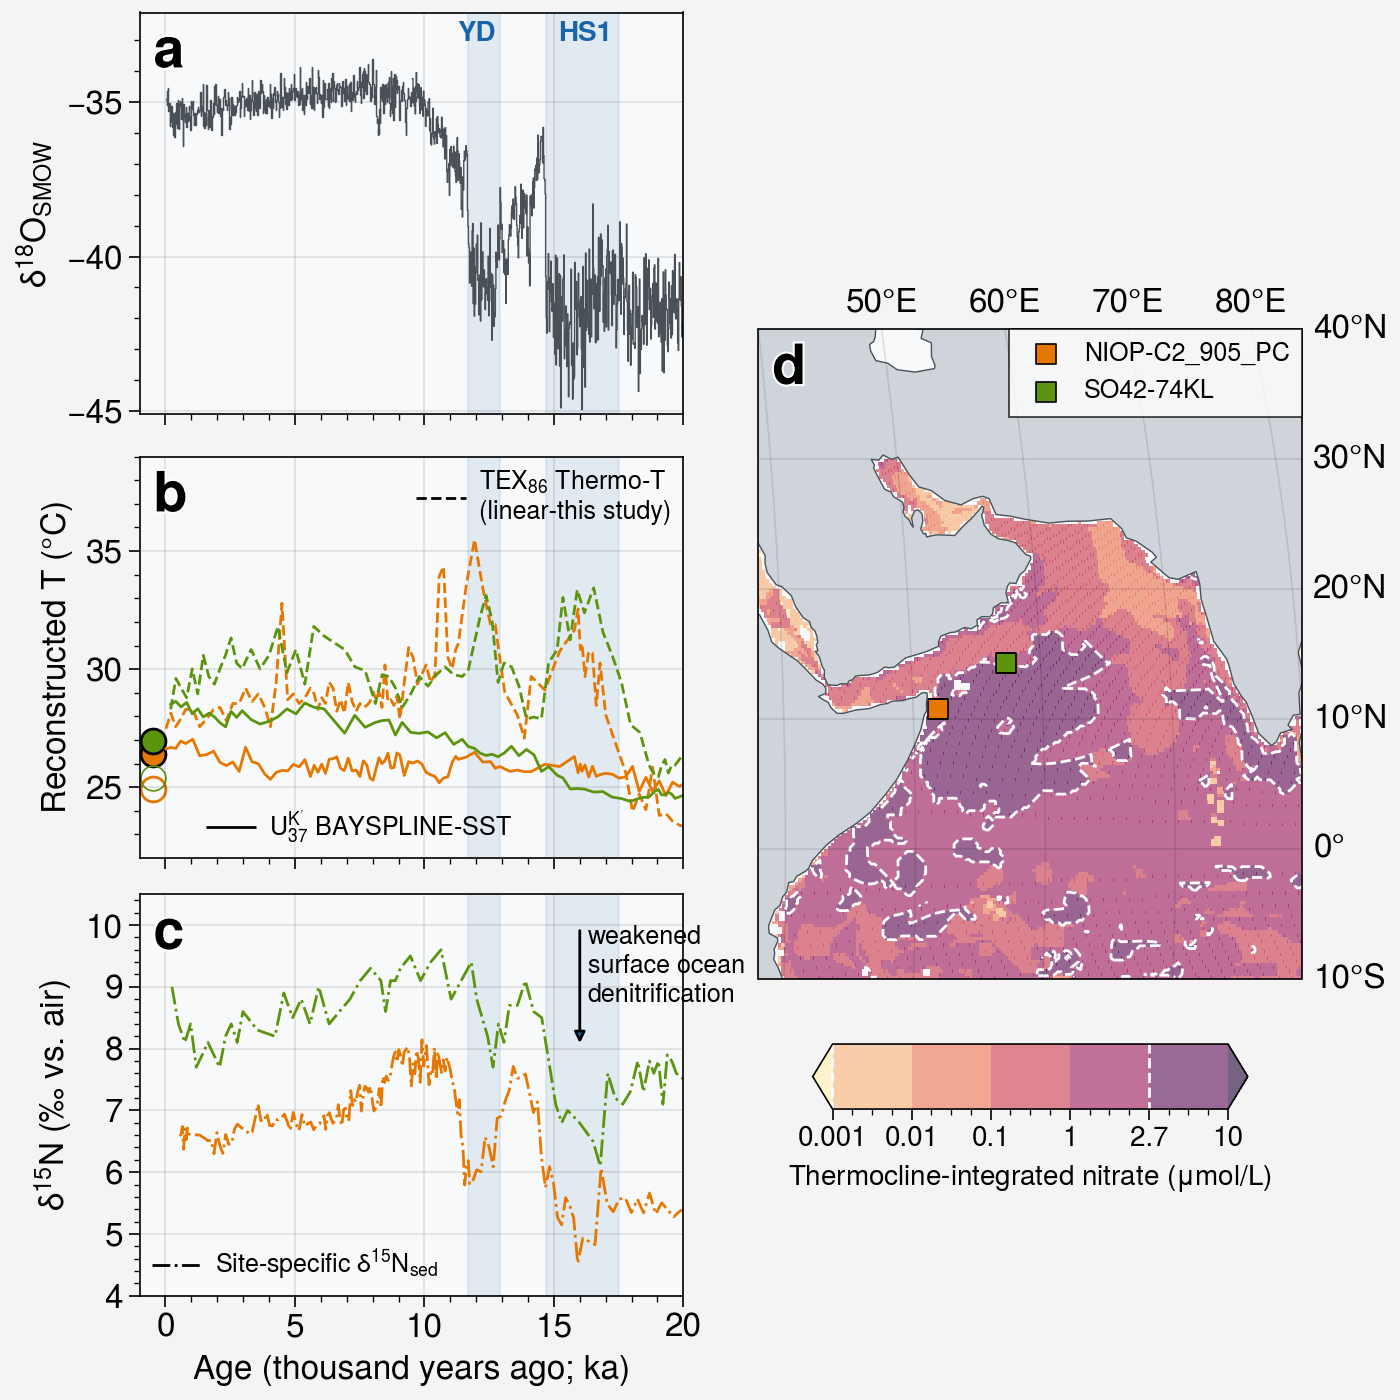

In [47]:
array = [
    [1,1,4,4],
    [2,2,4,4],
    [3,3,4,4],
]
fig, axs = plot.subplots(
    array,
    figsize=(7,7),
    share=0,
    wspace=3,
    proj=(None,None,None,'eck3')
    )

axs.format(facecolor='gray0',fontsize=12)
########## site locations
ax = axs[3]
ax.format(land=True,landcolor='gray4',landzorder=0,
          coast=True,coastcolor='gray7',coastlinewidth=0.5,
          latlim=(-10,40),lonlim=(40,80),
          latlabels='r',lonlabels='t',
          labelsize=12,latlines=10,lonlines=10,)


### lat lon for NIOP-C2_905_PC = 10.767N,51.95E
### lat lon for SO42-74KL = 14.321N, 57.347E
ax.scatter(51.95,10.767,c='yellow9',
           mec='k',marker='s',s=50,
           label='NIOP-C2_905_PC',
           zorder=2)

ax.scatter(57.347,14.321,c='lime9',
           mec='k',marker='s',s=50,
           label='SO42-74KL',
           zorder=2)
### plot sst and thermoT of modern sst for two core locations
NIOP905_today_sst = T_da.isel(depth=0).sel(lat=10.767,lon=51.95,method='nearest').values
axs[1].scatter(-0.5,NIOP905_today_sst, c='yellow9', mec='k', mew=1, marker='o',s=80, clip_on=False)
NIOP905_today_thermoT = t_sf2tc_da.sel(lat=10.767,lon=51.95,method='nearest').values
axs[1].scatter(-0.5,NIOP905_today_thermoT, facecolor='none', mec='yellow9', mew=1, marker='o',s=80, clip_on=False)

SO42_today_sst = T_da.isel(depth=0).sel(lat=14.321,lon=57.347,method='nearest').values
axs[1].scatter(-0.5,SO42_today_sst, c='lime9', mec='k', mew=1, marker='o',s=80, clip_on=False)
SO42_today_thermoT = t_sf2tc_da.sel(lat=14.321,lon=57.347,method='nearest').values
axs[1].scatter(-0.5,SO42_today_thermoT, facecolor='none', mec='lime9',marker='o',s=80, clip_on=False)

### plot modern d15N for arabian sea regions

plot_data = coretop_gridded_d15N_ds.sel(lat=slice(10,20),
                                        lon=slice(50,60)
                                        ).to_dataframe().dropna(subset=['d15N_mean']).reset_index()

m=thermocline_nitrate_da.sel(lat=slice(-10,30),lon=slice(25,90)).plot(ax=ax,
                                                                    zorder=0,
                                                                    levels=[1e-3,1e-2,1e-1,1,lowno3_threshold,10],
                                                                    cmap='matter',
                                                                    add_colorbar=False,
                                                                    alpha=0.65,
                                                                    rasterized=True)
ax.set_title('')
### plot the lowno3_threshold μM contour line
m2=thermocline_nitrate_da.sel(lat=slice(-10,30),lon=slice(25,90)
                                       ).plot.contour(ax=ax,levels=[0,lowno3_threshold],
                                                        zorder=1,
                                                        linewidths=1,
                                                        linestyles='dashed',
                                                        colors='w',robust=True)

axins1 = inset_axes(
    ax,
    width="80%",
    height="10%",
    loc="lower center",
    bbox_to_anchor=(0,-0.2,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

axins1.patch.set_alpha(0)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",
             extend='both'
             )
cbar.set_label('Thermocline-integrated nitrate ($\mu$mol/L)', size=10)
cbar.ax.tick_params(labelsize=10)
cbar.add_lines(m2)
cbar.lines[0].set_linestyle('dashed')
axins1.xaxis.set_ticklabels(['0.001','0.01','0.1','1',f'{lowno3_threshold}','10'])

###### time series plot
ax = axs[0]
ax.format(
    ylabel='$\delta^{18}$O$_{SMOW}$',
)
plot_data = ngrip_df.dropna(how='all',subset=['d18O NGRIP1']).reset_index(drop=True)
plot_x = plot_data['Age']/1000
plot_y = plot_data['d18O NGRIP1']
ax.plot(plot_x,plot_y,c='gray7',lw=0.5,label='NGRIP')

plot_data = ngrip_df.dropna(how='all',subset=['d18O NGRIP2']).reset_index(drop=True)
plot_x = plot_data['Age']/1000
plot_y = plot_data['d18O NGRIP2']
ax.plot(plot_x,plot_y,c='gray7',lw=0.5,label='')


ax = axs[1]
ax.format(
    ylabel='Reconstructed T ($\degree$C)',
    yticks=[25,30,35],
)
plot_data = NIOP905_SST_df
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='yellow9',lw=1)

plot_data = NIOP905_tex_df
plot_x = plot_data['Age']*1000
plot_y2 = plot_data['subT']
ax.plot(plot_x,plot_y2,c='yellow9',ls='--',lw=1)

plot_data = SO42_75KL_SST_df 
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='lime9',lw=1)

plot_data = SO42_75KL_tex_df
plot_x = plot_data['Age']*1000
plot_y2 = plot_data['subT']
ax.plot(plot_x,plot_y2,c='lime9',ls='--',lw=1)

#### plotting d15N data


ax = axs[2]
ax.format(
    ylabel='$\delta^{15}$N (‰ vs. air)',
    ylim=(4,10.5)
)
    
#### add an arrow with annotation showing reduced denitrification during YD and HS1
ax.annotate('',
            xy=(16,10),xytext=(16,8),
            arrowprops=dict(arrowstyle='<|-',lw=1),
            ha='center',va='center',fontsize=8)
ax.text(16.3,10,'weakened\nsurface ocean\ndenitrification',
        ha='left',va='top',fontsize=9)

sel_sites = ['NIOP 905','SO42-74KL']
sel_colors = ['yellow9','lime9']
plot_data = downcore_d15N_df[downcore_d15N_df['core_name'].isin(sel_sites)].dropna(subset=['Age','d15N'])
grouped = plot_data.groupby('core_name')
for name, group in grouped:
    group = group.sort_values(by='Age').reset_index(drop=True)
    plot_x = group['Age']
    plot_y = group['d15N']
    ax.plot(plot_x,plot_y,
            c=sel_colors[sel_sites.index(name)],
            lw=1,ls='-.',label='site-specific $\delta^{15}$N$_{sed}$')

#### add shaded area highlighting Younger Dryas (YD; 12.9-11.7 ka) and Heinrich stadial 1 (HS1; 16.9-14.5 ka) for all plots
for ax in axs[:3]:
    ax.axvspan(11.7,12.9,color='blue9',alpha=0.1)
    ax.axvspan(14.7,17.5,color='blue9',alpha=0.1)
### add text labels for YD and HS1 at the top of subplot A
ax = axs[0]
ax.text(0.62,0.98,'YD',transform=ax.transAxes,
        ha='center',va='top',color='blue9',
        fontsize=10,fontweight='bold')
ax.text(0.82,0.98,'HS1',transform=ax.transAxes,
        ha='center',va='top',color='blue9',
        fontsize=10,fontweight='bold')



############################################################

h, l = axs[1].get_legend_handles_labels()
h2, l2 = axs[2].get_legend_handles_labels()
h3,l3 = axs[-1].get_legend_handles_labels()


axs[1].legend(h[1],loc='ur',c='k',
              frameon=False,
              ncols=1,
              bbox_to_anchor=(0,0,1,1),
              labels=['TEX$_{86}$ Thermo-T\n(linear-this study)'],
              fontsize=8,
              )
axs[1].legend(h[0],loc='ll',c='k',
              frameon=False,
              ncols=1,
              bbox_to_anchor=(0.1,0,1,1),
              labels=["U$^{K'}_{37}$ BAYSPLINE-SST"],
              fontsize=8,
              )


axs[2].legend([h2[i] for i in [1]],
              loc='ll',ncols=1,
              c='k',
              frameon=False,
              labels=['Site-specific $\delta^{15}$N$_{sed}$']
              )

axs[-1].legend(h3,loc='upper right',ncol=1,
               bbox_to_anchor=(0,0,1,1),
               labels=['NIOP-C2_905_PC','SO42-74KL'],)


## set the color for the first two marker elements as black

axs.format( abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':20})

axs[:,0].format(
    xlim=(-1,20),
    xlabel='Age (thousand years ago; ka)',
)

axs[:2,0].format(
    xlabel='',
    xticklabels=[],
)
### set ylims for each plot
axs[0].format(ylim=(-45.1,-32.1),yticks=[-45,-40,-35])
axs[1].set_ylim(22,39)
plt.show()

fpath = fr'{local_github_path}/figures/'
fname = 'paleo_showcase_ArabianSea.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

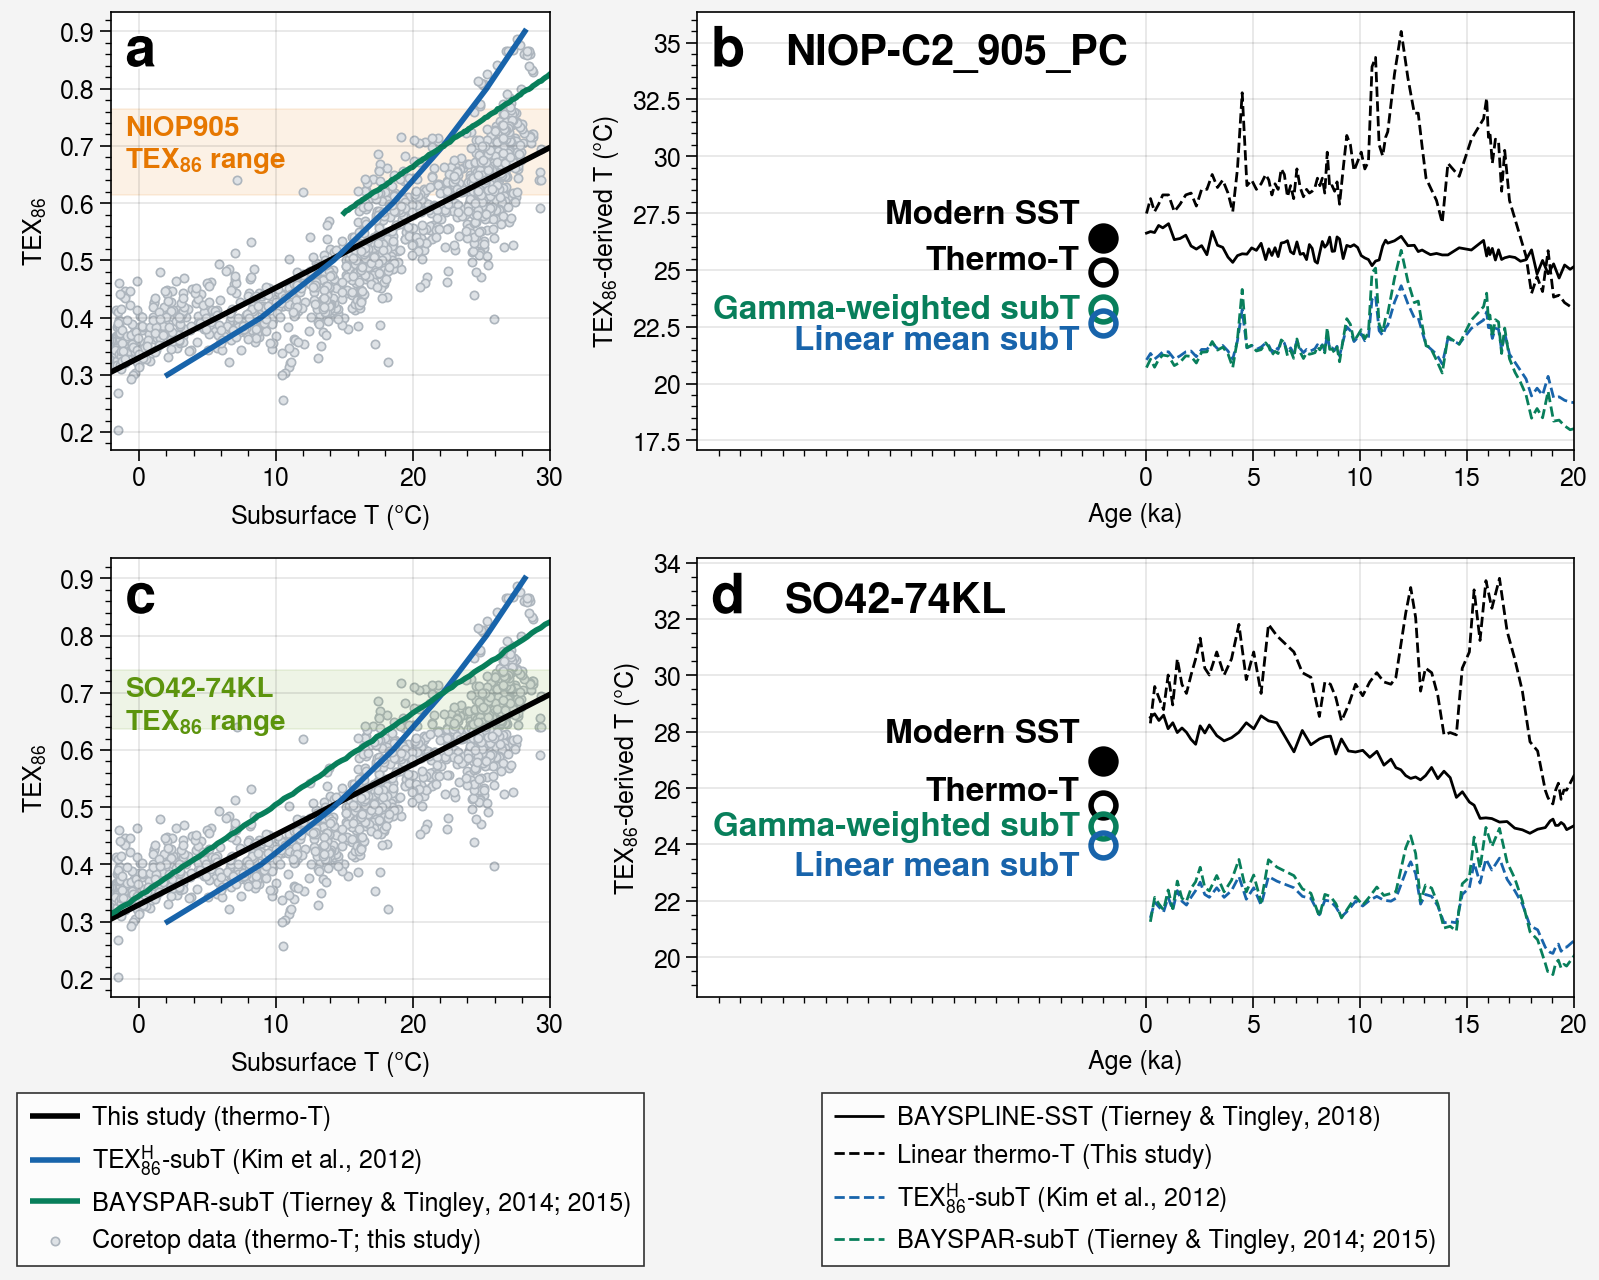

In [48]:
array = [
    [1,2,2],
    [3,4,4],
]
fig, axs = plot.subplots(array,width=8,share=0)



### shaded NIOP905 ProxyValue range
max_TEX = NIOP905_tex_df['ProxyValue'].max()
min_TEX = NIOP905_tex_df['ProxyValue'].min()

axs[0,0].fill_betweenx([min_TEX,max_TEX],-2,30,zorder=0,
                       color='yellow9',alpha=0.1)
axs[0,0].text(-1,max_TEX-0.01,'NIOP905\nTEX$_{86}$ range',
              color='yellow9',fontsize=10,fontweight='bold',
              va='top',ha='left')


### plot calibration curve of each model

### this study
slope = ols_tex_thermoT_thisStudy.coef_[0]
intercept = ols_tex_thermoT_thisStudy.intercept_
plot_x = np.linspace(-2,30,100)
plot_y = (slope * plot_x) + intercept
axs[:,0].plot(plot_x,plot_y,c='k',lw=2,zorder=1,label='This study (thermo-T)')

plot_y = np.arange(0.3,0.9,0.1)
plot_x = (np.log10(plot_y) * 54.7) + 30.7
axs[:,0].plot(plot_x,plot_y,c='blue9',lw=2,zorder=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')


### BAYSPAR
sel_lat = NIOP905_tex_df['ModLat'].unique()[0]
sel_lon = NIOP905_tex_df['ModLon'].unique()[0]

plot_x = np.linspace(15,30,100)
plot_y = bsr.predict_tex(plot_x, 
                    lon=sel_lon,
                    lat=sel_lat,
                    temptype='subt').percentile(50)                        
axs[0,0].plot(plot_x,plot_y,c='teal9',lw=2,zorder=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')


#### plot coretop data

plot_data = plot_coretop[plot_coretop['lat']<70]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
axs[:,0].scatter(plot_x,plot_y,m='.',c='gray3',mec='gray5',zorder=0,
                 label='Coretop data (thermo-T; this study)')


################################################################
ax = axs[0,1]

### plot SST from UK37
plot_data = NIOP905_SST_df
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='k',lw=1)

nonnan_idx = ~NIOP905_tex_df['ProxyValue'].isna() & ~NIOP905_tex_df['Age'].isna()
# ax.plot(NIOP905_tex_df['Age'].values[nonnan_idx],NIOP905_tex_df['ProxyValue'].values[nonnan_idx],
#         c='k')
ax.plot(NIOP905_tex_df['Age'].values[nonnan_idx]*1e3,NIOP905_tex_df['subT'].values[nonnan_idx],
        c='k',ls='--',lw=1,label='Linear thermo-T (This study)')
ax.plot(NIOP905_tex_df['Age'].values[nonnan_idx]*1e3,NIOP905_tex_df['subT_kim12_0_200m'].values[nonnan_idx],
        c='blue9',ls='--',lw=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')
ax.plot(NIOP905_tex_df['Age'].values[nonnan_idx]*1e3,NIOP905_tex_df['subT_bsr'].values[nonnan_idx],
        c='teal9',ls='--',lw=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')


sel_T = T_da.isel(depth=0).sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-2,sel_T,c='k',mec='k',mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-3.1,sel_T+1,'Modern SST',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = t_sf2tc_da.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-2,sel_T,
                 facecolor='none',mec='k',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-3.1,sel_T+0.5,'Thermo-T',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-2,sel_T,
                 facecolor='none',mec='teal9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-3.1,sel_T,'Gamma-weighted subT',c='teal9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_linear_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-2,sel_T,
                 facecolor='none',mec='blue9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-3.1,sel_T-0.75,'Linear mean subT',c='blue9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

###########################################################################
### BAYSPAR
sel_lat = SO42_75KL_tex_df['ModLat'].unique()[0]
sel_lon = SO42_75KL_tex_df['ModLon'].unique()[0]

plot_x = np.linspace(-2,30,100)
plot_y = bsr.predict_tex(plot_x, 
                    lon=sel_lon,
                    lat=sel_lat,
                    temptype='subt').percentile(50)                        
axs[1,0].plot(plot_x,plot_y,c='teal9',lw=2,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')

### shaded NIOP905 ProxyValue range
max_TEX = SO42_75KL_tex_df['ProxyValue'].max()
min_TEX = SO42_75KL_tex_df['ProxyValue'].min()

axs[1,0].fill_betweenx([min_TEX,max_TEX],-2,30,zorder=0,
                       color='lime9',alpha=0.1)
axs[1,0].text(-1,max_TEX-0.01,'SO42-74KL\nTEX$_{86}$ range',
              color='lime9',fontsize=10,fontweight='bold',
              va='top',ha='left')

ax = axs[1,1]

### plot SST from UK37
plot_data = SO42_75KL_SST_df
plot_x = plot_data['Age_kaBP']
plot_y = plot_data['sst']
ax.plot(plot_x,plot_y,c='k',lw=1,label='BAYSPLINE-SST (Tierney & Tingley, 2018)')

nonnan_idx = ~SO42_75KL_tex_df['ProxyValue'].isna() & ~SO42_75KL_tex_df['Age'].isna()
ax.plot(SO42_75KL_tex_df['Age'].values[nonnan_idx]*1e3,SO42_75KL_tex_df['subT'].values[nonnan_idx],
        c='k',ls='--',lw=1,label='Linear thermo-T (This study)')
ax.plot(SO42_75KL_tex_df['Age'].values[nonnan_idx]*1e3,SO42_75KL_tex_df['subT_kim12_0_200m'].values[nonnan_idx],
        c='blue9',ls='--',lw=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')
ax.plot(SO42_75KL_tex_df['Age'].values[nonnan_idx]*1e3,SO42_75KL_tex_df['subT_bsr'].values[nonnan_idx],
        c='teal9',ls='--',lw=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')



sel_T = T_da.isel(depth=0).sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[1,1].scatter(-2,sel_T,c='k',mec='k',mew=2,marker='o',s=80,clip_on=False)
axs[1,1].text(-3.1,sel_T+1,'Modern SST',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = t_sf2tc_da.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[1,1].scatter(-2,sel_T,
                 facecolor='none',mec='k',
                 mew=2,marker='o',s=80,clip_on=False)
axs[1,1].text(-3.1,sel_T+0.5,'Thermo-T',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[1,1].scatter(-2,sel_T,
                 facecolor='none',mec='teal9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[1,1].text(-3.1,sel_T,'Gamma-weighted subT',c='teal9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_linear_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[1,1].scatter(-2,sel_T,
                 facecolor='none',mec='blue9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[1,1].text(-3.1,sel_T-0.75,'Linear mean subT',c='blue9',
                ha='right',va='center',fontsize=12,fontweight='bold',)



axs[:,0].format(xlabel='Subsurface T ($\degree$C)',ylabel='TEX$_{86}$',)

h1, l1 = axs[0,0].get_legend_handles_labels()
axs[1,0].legend(h1,l1,loc='b',ncols=1)

h2, l2 = axs[1,1].get_legend_handles_labels()
axs[1,1].legend(h2,l2,loc='b',ncols=1)

axs.format(abc=True,abcstyle='a',abcloc='ul',rc_kw={'abc.size':20},)
axs[0,1].text(0.1,0.95,'NIOP-C2_905_PC',transform=axs[0,1].transAxes,
        ha='left',va='top',color='k',
        fontsize=15,fontweight='bold')
axs[1,1].text(0.1,0.95,'SO42-74KL',transform=axs[1,1].transAxes,
        ha='left',va='top',color='k',
        fontsize=15,fontweight='bold')
axs[:,1].format(xlim=(-21,20),
          xticks=np.arange(0,21,5),
          xtickrange=(0,20),
          ylabel='TEX$_{86}$-derived T ($\degree$C)',
          xlabel='Age (ka)',
          )

fpath = fr'{local_github_path}/figures/'
fname = 'paleo_showcase_ArabianSea_compare_with_previous_models.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

## Fig. 4: Paleo case study - Tasman Sea

In [49]:
fpath = fr'{local_github_path}/spreadsheets/'
fname = 'ds07_TasmanSea_paleorecords.xlsx'

slope = ols_tex_thermoT_thisStudy.coef_[0]
intercept = ols_tex_thermoT_thisStudy.intercept_

#################
DSDP591_uk37_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_Alkenones',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_Alkenones',skiprows=2).iloc[0,:].values
DSDP591_uk37_df.columns = header
DSDP591_uk37_df = DSDP591_uk37_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                  "UK37'":'uk37',
                                                  'BAYSPLINE-derived SST':'SST_bayspline',
                                                  "UK37 Total":'uk37_conc_ng_g'})
features = ['Depth_mbsf','Age','uk37','SST_bayspline','uk37_conc_ng_g']
DSDP591_uk37_df = DSDP591_uk37_df[features].dropna(subset=['uk37','SST_bayspline','uk37_conc_ng_g'])
display(DSDP591_uk37_df.head())

#################
DSDP591_tex86_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_GDGTs',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='DSDP591_GDGTs',skiprows=2).iloc[0,:].values
DSDP591_tex86_df.columns = header

DSDP591_tex86_df = DSDP591_tex86_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                    'GDGTs':'gdgt_conc_ng_g'})
features = ['Depth_mbsf','Age','TEX86','BIT','MI','%GDGT-0',
            'TEX86H-derived SST','BAYSPAR-derived SST','gdgt_conc_ng_g',
            'GDGT-2/GDGT-3']
DSDP591_tex86_df = DSDP591_tex86_df[features].dropna(subset=['TEX86','gdgt_conc_ng_g'])
DSDP591_tex86_df['subt_new'] = (DSDP591_tex86_df['TEX86']-intercept)/slope

### calculate BAYSPAR-subT and TEX86H-subT
## modern lat/lon for DSDP591 = -31.5842, 164.4487
sel_lat = -31.5842
sel_lon = 164.4487
DSDP591_tex86_df['subT_bsr'] = bsr.predict_seatemp(
    DSDP591_tex86_df['TEX86'],
    lon=sel_lon,
    lat=sel_lat,
    temptype='subt',prior_std=6).percentile(50)
DSDP591_tex86_df['subT_kim12_0_200m'] = 54.7 * np.log10(DSDP591_tex86_df['TEX86']) +30.7

display(DSDP591_tex86_df.head())

#################
IODPU1510_uk37_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_Alkenones',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_Alkenones',skiprows=2).iloc[0,:].values
IODPU1510_uk37_df.columns = header
IODPU1510_uk37_df = IODPU1510_uk37_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                  "UK37'":'uk37',
                                                  'BAYSPLINE-derived SST':'SST_bayspline',
                                                  "UK37 Total":'uk37_conc_ng_g'})
features = ['Depth_mbsf','Age','uk37','SST_bayspline','uk37_conc_ng_g']
IODPU1510_uk37_df = IODPU1510_uk37_df[features].dropna(subset=['uk37','SST_bayspline','uk37_conc_ng_g'])
display(IODPU1510_uk37_df.head())

################
IODPU1510_tex86_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_GDGTs',skiprows=4)
## header is in line 3 of the excel sheet
header = pd.read_excel(os.path.join(fpath,fname),sheet_name='IODPU1510_GDGTs',skiprows=2).iloc[0,:].values
IODPU1510_tex86_df.columns = header
IODPU1510_tex86_df = IODPU1510_tex86_df.rename(columns={'Mid Depth':'Depth_mbsf',
                                                    'GDGTs':'gdgt_conc_ng_g'})
features = ['Depth_mbsf','Age','TEX86','BIT','MI','%GDGT-0',
            'TEX86H-derived SST','BAYSPAR-derived SST','gdgt_conc_ng_g',
            'GDGT-2/GDGT-3']
IODPU1510_tex86_df = IODPU1510_tex86_df[features].rename(columns={'Mid Depth':'Depth_mbsf',})
IODPU1510_tex86_df['subt_new'] = (IODPU1510_tex86_df['TEX86']-intercept)/slope

### calculate BAYSPAR-subT and TEX86H-subT
## modern lat/lon for IODPU1510 = -36.329, 164.559
sel_lat = -36.329
sel_lon = 164.559
IODPU1510_tex86_df['subT_bsr'] = bsr.predict_seatemp(
    IODPU1510_tex86_df['TEX86'],
    lon=sel_lon,
    lat=sel_lat,
    temptype='subt',prior_std=6).percentile(50)
IODPU1510_tex86_df['subT_kim12_0_200m'] = 54.7 * np.log10(IODPU1510_tex86_df['TEX86']) +30.7

display(IODPU1510_tex86_df.head())


,Depth_mbsf,Age,uk37,SST_bayspline,uk37_conc_ng_g
1,0.0800,3.7333,0.7803,21.5670,60.1421
2,0.1300,6.0667,0.7821,21.6121,55.2160
3,0.1500,7.0000,0.7784,21.5189,42.3467
4,0.2100,9.8000,0.7586,20.9047,51.5504
5,0.2600,12.1333,0.7519,20.7060,51.6537


,Depth_mbsf,Age,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m
0,0.0150,0.7000,0.6712,0.0690,0.2224,35.9651,26.7554,28.2017,32.7647,6.6434,27.9036,26.0399,21.2278
1,0.0800,3.7333,0.6421,0.0376,0.2215,34.7351,25.4377,26.2825,15.9661,6.7420,25.5248,24.1769,20.1740
2,0.1300,6.0667,0.6422,0.0531,0.2209,31.2206,25.4445,26.4147,10.1822,7.3327,25.5367,24.1408,20.1794
3,0.1500,7.0000,0.6544,0.0497,0.2256,33.1066,26.0049,27.0389,5.3064,7.0530,26.5358,25.0305,20.6276
4,0.2100,9.8000,0.6687,0.2402,0.2060,33.4894,26.6438,28.1010,4.7224,6.7164,27.6980,25.7192,21.1386


,Depth_mbsf,Age,uk37,SST_bayspline,uk37_conc_ng_g
0,0.0700,1.4651,0.6335,17.1269,83.5713
1,0.2600,5.4419,0.6981,19.0839,58.1933
2,0.3900,8.1628,0.6731,18.3331,85.3466
3,0.4800,10.0465,0.6598,17.9272,117.0404
4,0.6000,12.5581,0.6488,17.6053,174.6079


,Depth_mbsf,Age,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m
0,0.0700,1.4651,0.5573,0.0289,0.2026,40.0189,21.2341,19.8962,41.7409,7.6450,18.6044,17.9588,16.8123
1,0.2600,5.4419,0.6051,0.2859,0.2115,39.1803,23.6774,23.0845,13.5792,6.6879,22.5073,21.0771,18.7663
2,0.3900,8.1628,0.5867,0.2219,0.2187,39.8798,22.7586,21.7442,29.9760,6.1144,21.0018,19.9302,18.0315
3,0.4800,10.0465,0.5844,0.0681,0.2030,37.3392,22.6425,21.7445,111.2544,8.5746,20.8149,19.7274,17.9387
4,0.6000,12.5581,0.5572,0.0931,0.2382,43.7782,21.2256,19.9518,116.0566,8.4501,18.5915,18.0167,16.8056


In [50]:
### read LR04_benthic_stack data
fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'lisiecki2005-d18o-stack-noaa.txt'
with open(os.path.join(fpath,fname),'r') as f:
    lines = f.readlines()
    
for i,line in enumerate(lines):
    if not line.startswith('#'):
        break
    
data = lines[i+1:]
header = ['Age_kyrBP','d18O_benthic','d18O_benthic_error']
data = [line.split() for line in data]
LR04_benthic_df = pd.DataFrame(data,columns=header)
LR04_benthic_df = LR04_benthic_df.apply(pd.to_numeric,errors='ignore')
LR04_benthic_df

,Age_kyrBP,d18O_benthic,d18O_benthic_error
0,0.0000,3.2300,0.0300
1,1.0000,3.2300,0.0400
2,2.0000,3.1800,0.0300
3,3.0000,3.2900,0.0300
4,4.0000,3.3000,0.0300
...,...,...,...
2110,5300.0000,2.9100,0.0600
2111,5305.0000,2.7900,0.0400
2112,5310.0000,2.7900,0.0900
2113,5315.0000,2.8400,0.0700


In [51]:
#### read vostok atmospheric d18O data
fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'deutnat-vostok-noaa.txt'

with open(os.path.join(fpath,fname),'r') as f:
    lines = f.readlines()
    
for i,line in enumerate(lines):
    if i == 0:
        continue
    else:
        if not line.startswith('#'):
            break
    
data = lines[i+1:]
header = ['depth_m','ice_ageBP','deltaD','deltaTS']
data = [line.split() for line in data]
Vostok_deltaTS_df = pd.DataFrame(data,columns=header)
Vostok_deltaTS_df = Vostok_deltaTS_df.apply(pd.to_numeric,errors='ignore')
Vostok_deltaTS_df['Age_kaBP'] = Vostok_deltaTS_df['ice_ageBP']/1000
Vostok_deltaTS_df

,depth_m,ice_ageBP,deltaD,deltaTS,Age_kaBP
0,0,0,-438.0000,0.0000,0.0000
1,1,17,-438.0000,0.0000,0.0170
2,2,35,-438.0000,0.0000,0.0350
3,3,53,-438.0000,0.0000,0.0530
4,4,72,-438.0000,0.0000,0.0720
...,...,...,...,...,...
3306,3306,420281,-435.2000,0.5400,420.2810
3307,3307,420888,-436.4000,0.3200,420.8880
3308,3308,421507,-437.3000,0.1500,421.5070
3309,3309,422135,-437.6000,0.0800,422.1350


In [52]:
IODPU1510_tex86_df.columns

Index(['Depth_mbsf', 'Age', 'TEX86', 'BIT', 'MI', '%GDGT-0',
       'TEX86H-derived SST', 'BAYSPAR-derived SST', 'gdgt_conc_ng_g',
       'GDGT-2/GDGT-3', 'subt_new', 'subT_bsr', 'subT_kim12_0_200m'],
      dtype='object')

GDGT-2/GDGT-3 mean:  6.506961824305459
GDGT-2/GDGT-3 median:  6.796351726213745
GDGT-2/GDGT-3 mean:  7.90100993749896
GDGT-2/GDGT-3 median:  8.02724782067248
20.96759
18.09761


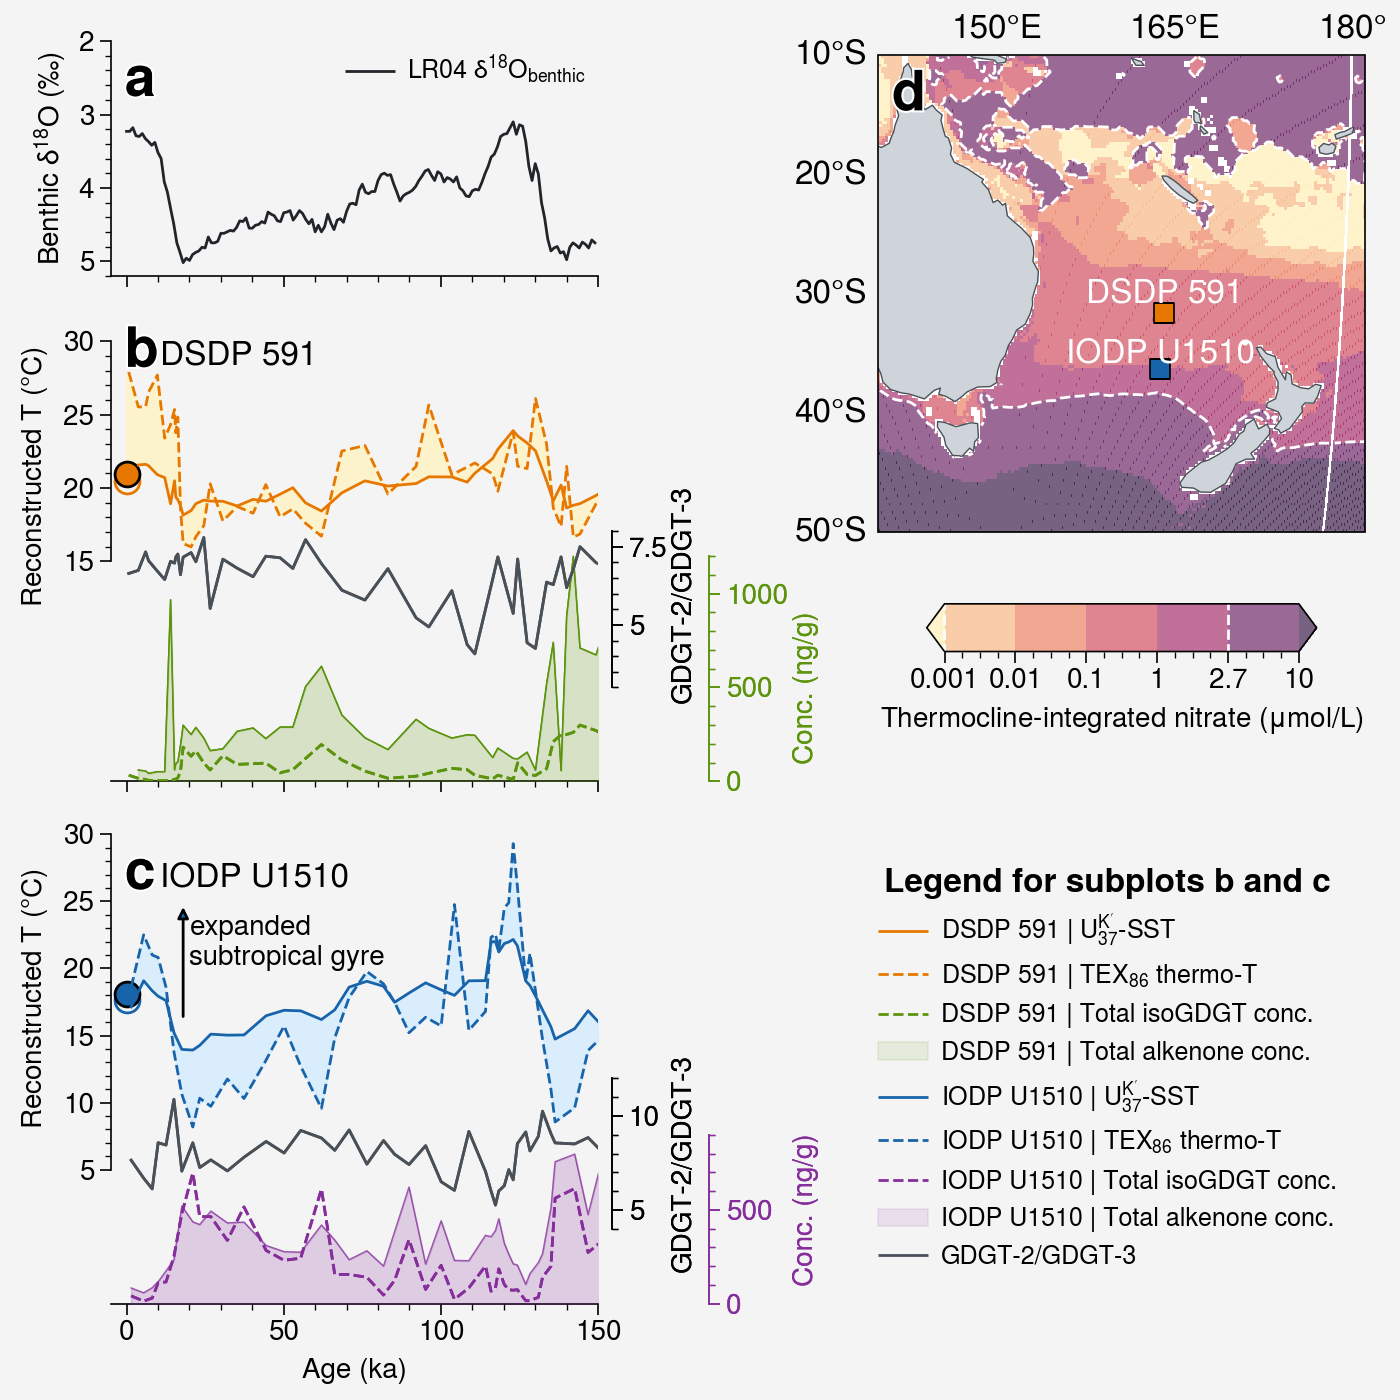

In [53]:
%matplotlib inline
array = [
    [1,1,4,4],
    [2,2,4,4],
    [2,2,0,0],
    [3,3,0,0],
    [3,3,0,0],
]

lowno3_threshold = 2.7

fig, axs = plot.subplots(
    array,
    figsize=(7,7),
    share=0,
    proj=(None,None,None,'eck3'),
    proj_kw={'lon_0': 150}
    )
axs.format(fontsize=12)
#### plot LR04 benthic d18O
ax = axs[0]
# ax.spines['left'].set_bounds((5,3))
plot_data = LR04_benthic_df[LR04_benthic_df['Age_kyrBP']<150]
plot_x = plot_data['Age_kyrBP']
plot_y = plot_data['d18O_benthic']
ax.plot(plot_x,plot_y,lw=1,c='gray9',label = 'LR04 $\delta^{18}$O$_{benthic}$')
ax.format(
    ylim=(5.2,2.0),
    ylabel='Benthic $\delta^{18}$O (‰)',
    fontsize=10,
    color='k' ## for dark background
)

h, l = ax.get_legend_handles_labels()
ax.legend(h,l,loc='ur',ncol=2,frameon=False,fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.patch.set_visible(False)
#### plot uk37-SST and tex86-SST as line plots on the same subplot for comparison 
ax = axs[1]
ax.spines['left'].set_bounds((15,30))

ax2 = ax.twinx()
ax2.spines['right'].set_position(('outward', 40))  # Move the right spine outward by 60 points
ax2.spines['right'].set_bounds((0, 1200))
ax2.spines['right'].set_color('lime9')

plot_data = DSDP591_uk37_df.dropna(subset=['uk37_conc_ng_g']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['uk37_conc_ng_g']
ax2.plot(plot_x, plot_y, color='lime9',lw=0.5, label='')
y1 = np.zeros_like(plot_x)
y2 = plot_y
ax2.fill_between(plot_x, y1, y2, label='DSDP 591 | Total alkenone conc.',
                 color='lime9',alpha=0.1,zorder=0)

plot_data = DSDP591_tex86_df.dropna(subset=['gdgt_conc_ng_g']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['gdgt_conc_ng_g']
ax2.plot(plot_x, plot_y, color='lime9',lw=1, ls='--', label='DSDP 591 | Total isoGDGT conc.')
ax2.format(
    ylim=(0,2500),
    yticks=np.arange(0,1201,300),  # Ensures major ticks span full range
    ytickminor=False,  # Consistent with ylim
    ytickcolor='lime9',
    ytickloc='right',
    yticklabelcolor='lime9',
    ylabelcolor='lime9',
    ylabel='Conc. (ng/g)',
    fontsize=10
)
ax2.yaxis.set_label_coords(1.4,0.2)

h2, l2 = ax2.get_legend_handles_labels()

ax2.set_frame_on(True)
ax2.patch.set_visible(False)

ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 5))
ax3.spines['right'].set_bounds((3,8))

plot_data = DSDP591_tex86_df.dropna(subset=['GDGT-2/GDGT-3']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['GDGT-2/GDGT-3']
ax3.plot(plot_x, plot_y, color='gray7',lw=1, label='')
ax3.format(
    ylim=(0,15),fontsize=10,ylabel='GDGT-2/GDGT-3',
    color='k' ## for dark background
)
ax3.yaxis.set_label_coords(1.15,0.4)
print('GDGT-2/GDGT-3 mean: ',np.mean(plot_y))
print('GDGT-2/GDGT-3 median: ',np.median(plot_y))

# Make ax1 spines opaque and drawn last
ax.patch.set_visible(False)  # so ax2 doesn't cover the plot area
for spine in ax.spines.values():
    spine.set_zorder(3)  # Ensure ax1 spines are on top

plot_data = DSDP591_uk37_df.dropna(subset=['SST_bayspline']).sort_values(by='Age').reset_index(drop=True)
plot_x1 = plot_data['Age']
plot_y1 = plot_data['SST_bayspline']
ax.plot(plot_x1,plot_y1,label="DSDP 591 | U$^{K'}_{37}$-SST",c='yellow9',lw=1)

plot_data = DSDP591_tex86_df[
    ((DSDP591_tex86_df['BIT']<=0.5)
    &(DSDP591_tex86_df['MI']<=0.5)
    &(DSDP591_tex86_df['%GDGT-0']<=60))].dropna(subset=['subt_new']).sort_values(by='Age').reset_index(drop=True)
plot_x2 = plot_data['Age']
plot_y2 = plot_data['subt_new']
ax.plot(plot_x2,plot_y2,label='DSDP 591 | TEX$_{86}$ thermo-T', lw=1, ls='--', c='yellow9')


### shade color between y of two lines ---if tex is higher than uk37, shade red else shade blue
### need to interpolate the two lines to get the y values at the same x

x = np.linspace(0,150,100)
y1 = np.interp(x,plot_x1,plot_y1)
y2 = np.interp(x,plot_x2,plot_y2)
ax.fill_between(x,y1,y2,color='yellow1',alpha=0.75)


h, l = ax.get_legend_handles_labels()
ax.text(0.1,0.94,'DSDP 591',transform=ax.transAxes,
        ha='left',va='top',fontsize=12)
ax.format(
    ylim=(0,32),
    ytickrange=(15,30,5),
    ytickminor=False,
    yticks=[15,20,25,30],
    ylabel='Reconstructed T ($\degree$C)',
    fontsize=10,
    color='k' ## for dark background
)
ax.yaxis.set_label_coords(-0.125,0.65)
ax.spines['top'].set_visible(False)
#####################################################
ax = axs[2]
ax.spines['left'].set_bounds((5,30))
ax2 = ax.twinx()
ax2.spines['right'].set_position(('outward', 40))  # Move the right spine outward by 60 points
ax2.spines['right'].set_bounds((0, 900))
ax2.spines['right'].set_color('grape9')
plot_data = IODPU1510_uk37_df[IODPU1510_uk37_df['uk37_conc_ng_g']<8000
                              ].dropna(subset=['uk37_conc_ng_g']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['uk37_conc_ng_g']
# ax2.fill_between(plot_x, plot_y-10, color='gray3',lw=1,label='')
ax2.plot(plot_x, plot_y, color='grape9',lw=0.5, label='',alpha=0.5)
y1 = np.zeros_like(plot_x)
y2 = plot_y
ax2.fill_between(plot_x, y1, y2, label='IODP U1510 | Total alkenone conc.',
                 color='grape9',alpha=0.1,zorder=0)

plot_data = IODPU1510_tex86_df.dropna(subset=['gdgt_conc_ng_g']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['gdgt_conc_ng_g']
ax2.plot(plot_x, plot_y, color='grape9',lw=1, ls='--', label='IODP U1510 | Total isoGDGT conc.')
ax2.format(
    ylim=(0,2500),
    ytickcolor='grape9',
    ytickloc='right',
    yticklabelcolor='grape9',
    ylabelcolor='grape9',
    ylabel='Conc. (ng/g)',
    fontsize=10
)
ax2.yaxis.set_label_coords(1.4,0.2)
h4, l4 = ax2.get_legend_handles_labels()
# Turn on the frame for the twin axis, but then hide all 
# but the bottom spine
ax2.set_frame_on(True)
ax2.patch.set_visible(False)

ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 5))
ax3.spines['right'].set_bounds((4,12))

plot_data = IODPU1510_tex86_df.dropna(subset=['GDGT-2/GDGT-3']).sort_values(by='Age').reset_index(drop=True)
plot_x = plot_data['Age']
plot_y = plot_data['GDGT-2/GDGT-3']
ax3.plot(plot_x, plot_y, color='gray7',lw=1, label='GDGT-2/GDGT-3')
print('GDGT-2/GDGT-3 mean: ',np.mean(plot_y))
print('GDGT-2/GDGT-3 median: ',np.median(plot_y))
ax3.format(
    ylim=(0,25),fontsize=10,ylabel='GDGT-2/GDGT-3',
    color='k' ## for dark background
    
)
ax3.yaxis.set_label_coords(1.15,0.3)


# Make ax1 spines opaque and drawn last
ax.patch.set_visible(False)  # so ax2 doesn't cover the plot area
for spine in ax.spines.values():
    spine.set_zorder(3)  # Ensure ax1 spines are on top

##############################3
plot_data = IODPU1510_uk37_df.dropna(subset=['SST_bayspline']).sort_values(by='Age').reset_index(drop=True)
plot_x1 = plot_data['Age']
plot_y1 = plot_data['SST_bayspline']
ax.plot(plot_x1,plot_y1,label="IODP U1510 | U$^{K'}_{37}$-SST", lw=1, c='blue9')

plot_data = IODPU1510_tex86_df[
    ((IODPU1510_tex86_df['BIT']<=0.5)
    &(IODPU1510_tex86_df['MI']<=0.5)
    &(IODPU1510_tex86_df['%GDGT-0']<=60))].dropna(subset=['subt_new']).sort_values(by='Age').reset_index(drop=True)
plot_x2 = plot_data['Age']
plot_y2 = plot_data['subt_new']
ax.plot(plot_x2,plot_y2,label='IODP U1510 | TEX$_{86}$ thermo-T', lw=1, ls='--', c='blue9')

### shade pale yellow between y of two lines
### need to interpolate the two lines to get the y values at the same x
x = np.linspace(0,150,100)
y1 = np.interp(x,plot_x1,plot_y1)
y2 = np.interp(x,plot_x2,plot_y2)
ax.fill_between(x,y1,y2,color='blue1',alpha=0.75)

h3, l3 = ax.get_legend_handles_labels()

ax.text(0.1,0.94,'IODP U1510',transform=ax.transAxes,
        ha='left',va='top',fontsize=12)

ax.format(
    ylim=(-5,30),
    ytickrange=(5,30,5),
    ytickminor=False,
    yticks=[5,10,15,20,25,30],
    ylabel='Reconstructed T ($\degree$C)',
    fontsize=10,
    color='k' ## for dark background
)
ax.spines['top'].set_visible(False)
#### add an arrow with annotation showing reduced denitrification during YD and HS1
ax.annotate('',
            xy=(18,16),xytext=(18,25),
            arrowprops=dict(arrowstyle='<|-',lw=1),
            ha='center',va='center',fontsize=8)
ax.text(20,24,'expanded\nsubtropical gyre',
        ha='left',va='top',fontsize=10)
ax.yaxis.set_label_coords(-0.125,0.65)

####################################################
ax = axs[3]
ax.format(
    land=True,landcolor='gray4',landzorder=0,
    coast=True,coastcolor='gray7',coastlinewidth=0.5,
    latlim=(-50,-10),lonlim=(-220,-179),
    latlines=10,lonlines=15,
    latlabels='l',lonlabels='t',
    labelsize=12,
)


### plot thermocline-integrated nitrate on the map
m = thermocline_nitrate_da.sel(lat=slice(-60,-10)).plot(ax=ax,
                                                    zorder=0,
                                                    levels=[1e-3,1e-2,1e-1,1,lowno3_threshold,10],
                                                    cmap='matter',
                                                    add_colorbar=False,
                                                    alpha=0.65,
                                                    rasterized=True)


### plot contour line for lowno3_threshold μM nitrate
m2 = thermocline_nitrate_da.sel(lat=slice(-60,-10)).plot.contour(ax=ax,levels=[0,lowno3_threshold],
                                                zorder=1,
                                                linewidths=1,
                                                linestyles='dashed',
                                                colors='w',robust=True)

ax.set_title('')

axins1 = inset_axes(
    ax,
    width="80%",
    height="10%",
    loc="lower center",
    bbox_to_anchor=(0,-0.25,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0
)
axins1.patch.set_alpha(0)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",
             extend='both'
             )
cbar.set_label('Thermocline-integrated nitrate ($\mu$mol/L)', size=10)
cbar.ax.tick_params(labelsize=10)
cbar.add_lines(m2)
cbar.lines[0].set_linestyle('dashed')

axins1.xaxis.set_ticklabels(['0.001','0.01','0.1','1',f'{lowno3_threshold}','10'])
### lat/lon for DSDP591 = -31.5843	 164.4487
### lat/lon for IODP U1510 = 36°19.7385′S, 164°33.5220′E, water depth 1238 m

axs[-1:].scatter(164.4487,-31.5843,c='yellow9',
           mec='k',marker='s',s=50,
           label='DSDP591',
           zorder=2)
axs[-1:].text(164.4487,-30,'DSDP 591',
              ha='center',va='center',
              fontsize=12,transform=ccrs.PlateCarree(),
              c='w',zorder=3)

axs[-1:].scatter(164.33,-36.33,c='blue9',
              mec='k',marker='s',s=50,
              label='IODP U1510',
              zorder=2)

axs[-1:].text(164.33,-35,'IODP U1510',
              ha='center',va='center',
              fontsize=12,transform=ccrs.PlateCarree(),
              c='w',zorder=3)


#### plot today's SST from T_da and thermocline-integrated T data
DSDP591_today_sst = T_da.isel(depth=0).sel(lat=-31.5843,lon=164.4487,method='nearest').values
DSDP591_thermoT = t_sf2tc_da.sel(lat=-31.5843,lon=164.4487,method='nearest').values
axs[1].scatter(0,DSDP591_thermoT,mec='yellow9',mew=1,marker='o',facecolor='none',s=80)
axs[1].scatter(0,DSDP591_today_sst,c='yellow9',mec='k',mew=1,marker='o',s=80)
print(DSDP591_today_sst)

IODPU1510_today_sst = T_da.isel(depth=0).sel(lat=-36.33,lon=164.33,method='nearest').values
IODPU1510_thermoT = t_sf2tc_da.sel(lat=-36.33,lon=164.33,method='nearest').values
axs[2].scatter(0,IODPU1510_thermoT,mec='blue9',mew=1,marker='o',facecolor='none',s=80)
axs[2].scatter(0,IODPU1510_today_sst,c='blue9',mec='k',mew=1,marker='o',s=80)
print(IODPU1510_today_sst)

######### LEGEND
h5, l5 = ax3.get_legend_handles_labels()

legend = ax3.legend(h+h2+h3+h4+h5,l+l2+l3+l4+l5,
          titlefontweight='bold',
          loc='r',
          bbox_to_anchor=(1,0,1,1),
          frameon=False,
          ncol=1)
legend.set_title('Legend for subplots b and c', prop={'size': 12,
                                                      'weight':'bold'})



#################


axs[:3].format(
    xlim=(-5,150),
    xlabel='Age (ka)',
)
axs[:2].format(
    xlabel='',
    xticklabels=[],
)

axs.format(
    abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':20},
    grid=False
)


# axs[:].axvline(125,zorder=0,c='gray5',lw=2,alpha=0.5)
    
fpath = fr'{local_github_path}/figures/'
fname = 'paleo_showcase_SPSTG.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

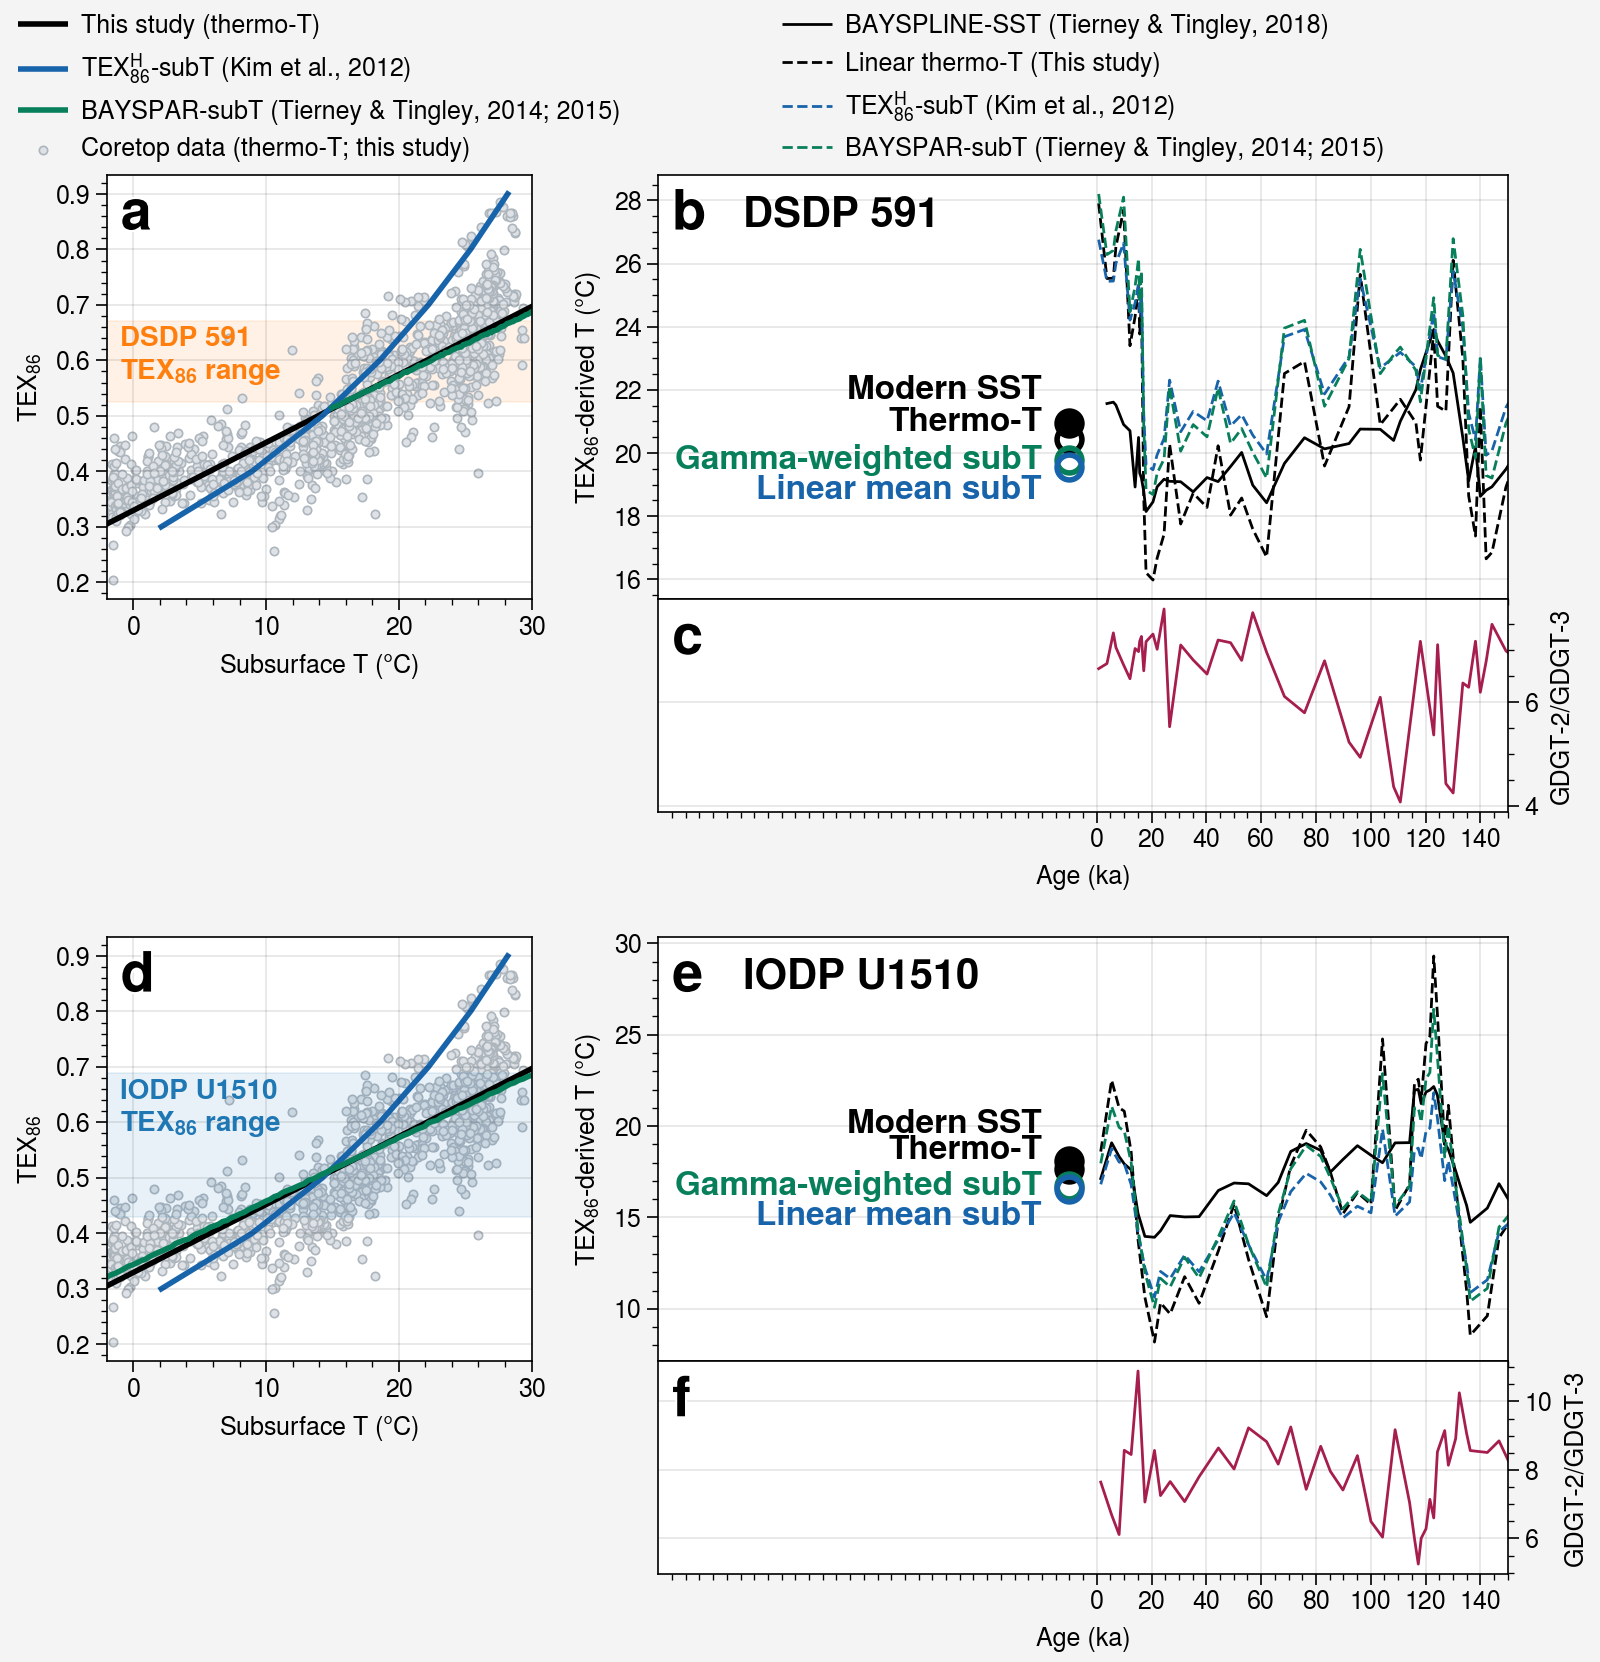

In [54]:
%matplotlib inline
array = [
    [1,2,2],
    [0,3,3],
    [4,5,5],
    [0,6,6],

]
fig, axs = plot.subplots(array,width=8,share=0,
                         hratios=[1,0.5,1,0.5],
                         hspace=[0,5,0])



### shaded DSDP591 ProxyValue range
max_TEX = DSDP591_tex86_df['TEX86'].max()
min_TEX = DSDP591_tex86_df['TEX86'].min()

axs[0,0].fill_betweenx([min_TEX,max_TEX],-2,30,zorder=0,
                       color='tab:orange',alpha=0.1)
axs[0,0].text(-1,max_TEX-0.01,'DSDP 591\nTEX$_{86}$ range',
              color='tab:orange',fontsize=10,fontweight='bold',
              va='top',ha='left')


### plot calibration curve of each model

### this study
slope = ols_tex_thermoT_thisStudy.coef_[0]
intercept = ols_tex_thermoT_thisStudy.intercept_
plot_x = np.linspace(-2,30,100)
plot_y = (slope * plot_x) + intercept
axs[:,0].plot(plot_x,plot_y,c='k',lw=2,zorder=1,label='This study (thermo-T)')

plot_y = np.arange(0.3,0.9,0.1)
plot_x = (np.log10(plot_y) * 54.7) + 30.7
axs[:,0].plot(plot_x,plot_y,c='blue9',lw=2,zorder=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')


### BAYSPAR
### lat/lon for Site DSDP591 = -31.5843  164.4487
sel_lat = -31.5843
sel_lon = 164.4487

plot_x = np.linspace(15,30,100)
plot_y = bsr.predict_tex(plot_x, 
                    lon=sel_lon,
                    lat=sel_lat,
                    temptype='subt').percentile(50)                        
axs[0,0].plot(plot_x,plot_y,c='teal9',lw=2,zorder=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')


#### plot coretop data

plot_data = plot_coretop[plot_coretop['lat']<70]
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
axs[:,0].scatter(plot_x,plot_y,m='.',c='gray3',mec='gray5',zorder=0,
                 label='Coretop data (thermo-T; this study)')


################################################################
ax = axs[0,1]

### plot SST from UK37
plot_data = DSDP591_uk37_df
nonnan_idx = ~plot_data['SST_bayspline'].isna() & ~plot_data['Age'].isna()
plot_x = plot_data['Age'].values[nonnan_idx]
plot_y = plot_data['SST_bayspline'].values[nonnan_idx]
ax.plot(plot_x,plot_y,c='k',lw=1)

nonnan_idx = ~DSDP591_tex86_df['TEX86'].isna() & ~DSDP591_tex86_df['Age'].isna()
# ax.plot(DSDP591_tex86_df['Age'].values[nonnan_idx],DSDP591_tex86_df['TEX86'].values[nonnan_idx],
#         c='k')
ax.plot(DSDP591_tex86_df['Age'].values[nonnan_idx],DSDP591_tex86_df['subt_new'].values[nonnan_idx],
        c='k',ls='--',lw=1,label='Linear thermo-T (This study)')
ax.plot(DSDP591_tex86_df['Age'].values[nonnan_idx],DSDP591_tex86_df['TEX86H-derived SST'].values[nonnan_idx],
        c='blue9',ls='--',lw=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')
ax.plot(DSDP591_tex86_df['Age'].values[nonnan_idx],DSDP591_tex86_df['BAYSPAR-derived SST'].values[nonnan_idx],
        c='teal9',ls='--',lw=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')


sel_T = T_da.isel(depth=0).sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-10,sel_T,c='k',mec='k',mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-20,sel_T+1,'Modern SST',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = t_sf2tc_da.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-10,sel_T,
                 facecolor='none',mec='k',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-20,sel_T+0.5,'Thermo-T',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-10,sel_T,
                 facecolor='none',mec='teal9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-20,sel_T,'Gamma-weighted subT',c='teal9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_linear_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[0,1].scatter(-10,sel_T,
                 facecolor='none',mec='blue9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[0,1].text(-20,sel_T-0.75,'Linear mean subT',c='blue9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

### plot GDGT-2/GDGT-3 ratio
plot_data = DSDP591_tex86_df
plot_x = plot_data['Age']
plot_y = plot_data['GDGT-2/GDGT-3']
axs[1,1].plot(plot_x,plot_y,c='pink9',lw=1,label='GDGT-2/GDGT-3 ratio')
###########################################################################
### BAYSPAR
### lat/lon for Site IODPU1510 = 36°19.7385′S, 164°33.5220′E, water depth 1238 m
### lat/lon for Site IODPU1510 = -36.33, 164.33
sel_lat = -36.33
sel_lon = 164.33

plot_x = np.linspace(-2,30,100)
plot_y = bsr.predict_tex(plot_x, 
                    lon=sel_lon,
                    lat=sel_lat,
                    temptype='subt').percentile(50)                        
axs[2,0].plot(plot_x,plot_y,c='teal9',lw=2,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')

### shaded DSDP591 ProxyValue range
max_TEX = IODPU1510_tex86_df['TEX86'].max()
min_TEX = IODPU1510_tex86_df['TEX86'].min()

axs[2,0].fill_betweenx([min_TEX,max_TEX],-2,30,zorder=0,
                       color='tab:blue',alpha=0.1)
axs[2,0].text(-1,max_TEX-0.01,'IODP U1510\nTEX$_{86}$ range',
              color='tab:blue',fontsize=10,fontweight='bold',
              va='top',ha='left')

ax = axs[2,1]

### plot SST from UK37
plot_data = IODPU1510_uk37_df
plot_x = plot_data['Age']
plot_y = plot_data['SST_bayspline']
ax.plot(plot_x,plot_y,c='k',lw=1,label='BAYSPLINE-SST (Tierney & Tingley, 2018)')

nonnan_idx = ~IODPU1510_tex86_df['TEX86'].isna() & ~IODPU1510_tex86_df['Age'].isna()
ax.plot(IODPU1510_tex86_df['Age'].values[nonnan_idx],IODPU1510_tex86_df['subt_new'].values[nonnan_idx],
        c='k',ls='--',lw=1,label='Linear thermo-T (This study)')
ax.plot(IODPU1510_tex86_df['Age'].values[nonnan_idx],IODPU1510_tex86_df['subT_kim12_0_200m'].values[nonnan_idx],
        c='blue9',ls='--',lw=1,label='TEX$_{86}^{H}$-subT (Kim et al., 2012)')
ax.plot(IODPU1510_tex86_df['Age'].values[nonnan_idx],IODPU1510_tex86_df['subT_bsr'].values[nonnan_idx],
        c='teal9',ls='--',lw=1,label='BAYSPAR-subT (Tierney & Tingley, 2014; 2015)')



sel_T = T_da.isel(depth=0).sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[2,1].scatter(-10,sel_T,c='k',mec='k',mew=2,marker='o',s=80,clip_on=False)
axs[2,1].text(-20,sel_T+2,'Modern SST',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = t_sf2tc_da.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[2,1].scatter(-10,sel_T,
                 facecolor='none',mec='k',
                 mew=2,marker='o',s=80,clip_on=False)
axs[2,1].text(-20,sel_T+1,'Thermo-T',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[2,1].scatter(-10,sel_T,
                 facecolor='none',mec='teal9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[2,1].text(-20,sel_T,'Gamma-weighted subT',c='teal9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

sel_T = T_0_200m_linear_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values
axs[2,1].scatter(-10,sel_T,
                 facecolor='none',mec='blue9',
                 mew=2,marker='o',s=80,clip_on=False)
axs[2,1].text(-20,sel_T-1.5,'Linear mean subT',c='blue9',
                ha='right',va='center',fontsize=12,fontweight='bold',)

### plot GDGT-2/GDGT-3 ratio
plot_data = IODPU1510_tex86_df
plot_x = plot_data['Age']
plot_y = plot_data['GDGT-2/GDGT-3']
axs[3,1].plot(plot_x,plot_y,c='pink9',lw=1,label='GDGT-2/GDGT-3 ratio')

############ cosmetic formatting ########################3
axs[:,0].format(xlabel='Subsurface T ($\degree$C)',ylabel='TEX$_{86}$',)

h1, l1 = axs[0,0].get_legend_handles_labels()
axs[0,0].legend(h1,l1,loc='t',ncols=1,
        frameon=False,
)

h2, l2 = axs[2,1].get_legend_handles_labels()
axs[0,1].legend(h2,l2,loc='t',ncols=1,
        frameon=False,
)

axs.format(abc=True,abcstyle='a',abcloc='ul',rc_kw={'abc.size':20},)
axs[0,1].text(0.1,0.95,'DSDP 591',transform=axs[0,1].transAxes,
        ha='left',va='top',
        color='k', # change to 'w' for dark background
        fontsize=15,fontweight='bold')
axs[2,1].text(0.1,0.95,'IODP U1510',transform=axs[2,1].transAxes,
        ha='left',va='top',
        color='k', # change to 'w' for dark background
        fontsize=15,fontweight='bold')
axs[:,1].format(xlim=(-160,150),
          xticks=np.arange(0,151,20),
          xtickrange=(0,150),
          ylabel='TEX$_{86}$-derived T ($\degree$C)',
          xlabel='Age (ka)',
          )

row_idx = [1,3]
for row in row_idx:
    axs[row,1].format(ytickloc='right',ylabel='GDGT-2/GDGT-3')
    
fpath = fr'{local_github_path}/figures/'
fname = 'paleo_showcase_SPSTG_compare_with_previous_models.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

# 4. Supplementary figures

## Fig S1. Ammonia oxidation rate vs nitrate

In [55]:
## Fig. S1: nitrate and ammonium conc. vs ammonia oxidation rate
plot_data_ammOx_nh4 = merged_ammOxR_gridded_ds.where(
    merged_ammOxR_gridded_ds.depth<=thermocline_depth_da)[
        ['ammOxRate_median','NH4_median',
        'ammOxRate_mean','NH4_mean']].to_dataframe().dropna().reset_index()
    
plot_data_ammOx_no3 = merged_ammOxR_gridded_ds.where(
    merged_ammOxR_gridded_ds.depth<=thermocline_depth_da)[[
        'ammOxRate_median','NO3_median',
        'ammOxRate_mean','NO3_mean']].to_dataframe().dropna().reset_index()
plot_data_only_ammOx = merged_ammOxR_gridded_ds.where(merged_ammOxR_gridded_ds.depth<=thermocline_depth_da)[[
    'ammOxRate_median','ammOxRate_mean']].to_dataframe().dropna().reset_index()

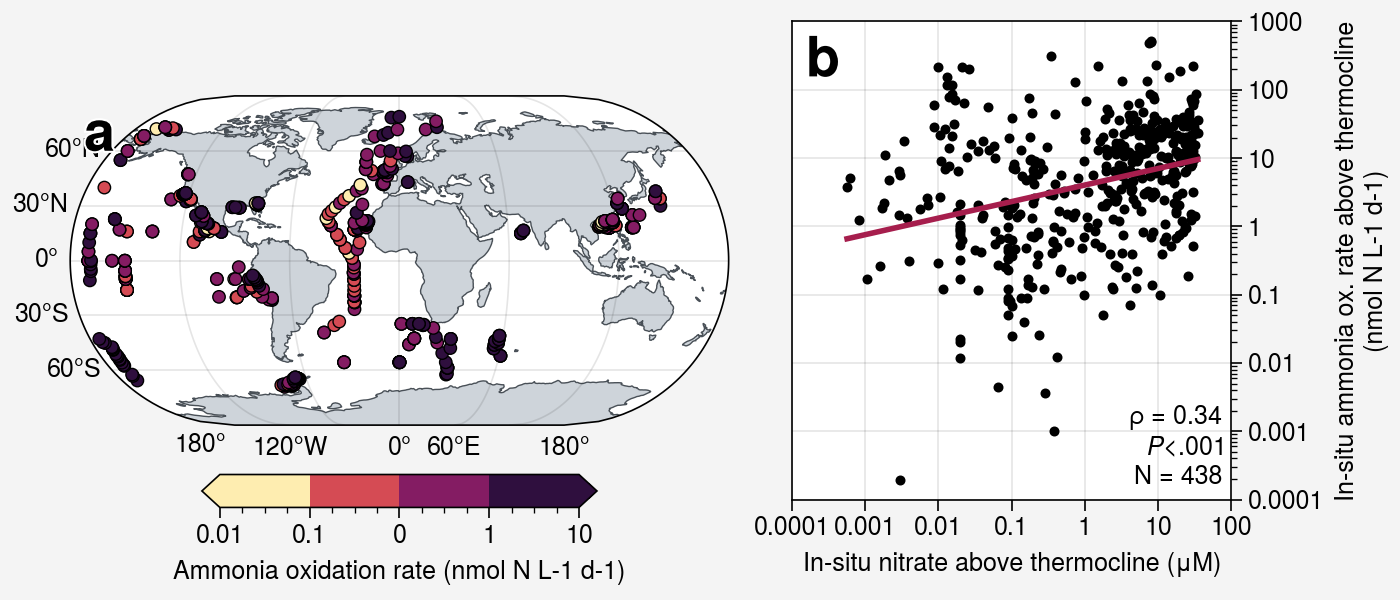

In [56]:
array = [
    [1,2],
]

fig, axs = plot.subplots(array,proj=('eck3',None),
                         wratios=[1.5,1],
                         figsize=(7,3),share=False)

ax = axs[0,0]
ax.format(land=True, landcolor='gray4',landzorder=0,
          coast=True, coastcolor='gray7',coastlinewidth=0.5,coastzorder=1,
          latlabels='l', lonlabels=True)

plot_data = plot_data_only_ammOx
plot_x = plot_data['lon']
plot_y = plot_data['lat']
plot_c = plot_data['ammOxRate_median']
m = ax.scatter(plot_x,plot_y,
              c=plot_c,cmap='matter',
              levels=[1e-2,1e-1,1e0,1e1,1e2],
              robust=True,
              s=20,mec='k',mew=0.5,
              zorder=2)
# ax.colorbar(m,loc='r',shrink=0.6,extend='both',)
axins1 = inset_axes(
    ax,
    width="60%",
    height="10%",
    loc="lower center",
    bbox_to_anchor=(0,-0.25,1,1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
axins1.patch.set_alpha(0)
cbar = fig.colorbar(m,
             cax=axins1,
             orientation="horizontal",
             label='Ammonia oxidation rate (nmol N L-1 d-1)',
             extend='both',
             )
axins1.xaxis.set_ticks_position('bottom')
axins1.xaxis.set_label_position('bottom')
axins1.xaxis.set_ticklabels(['0.01','0.1','0','1','10'])

################################################3
ax = axs[0,1]
plot_data = plot_data_ammOx_no3
plot_x_param = 'NO3_median'
plot_y_param = 'ammOxRate_median'
ax.scatter(plot_data[plot_x_param],plot_data[plot_y_param],m='.',c='k')

### calculate log10 for plot_x and plot_y
plot_data['Log10_'+plot_x_param] = np.log10(plot_data[plot_x_param])
plot_data['Log10_'+plot_y_param] = np.log10(plot_data[plot_y_param])
plot_data[['Log10_'+plot_x_param,'Log10_'+plot_y_param]] = plot_data[['Log10_'+plot_x_param,'Log10_'+plot_y_param]
                                                            ].replace([np.inf,-np.inf],np.nan)
reg_data = plot_data.dropna(subset=['Log10_'+plot_x_param,'Log10_'+plot_y_param]).reset_index(drop=True)
  
### ols fit
ols = LinearRegression()
X = reg_data['Log10_'+plot_x_param].values.reshape(-1,1)
y = reg_data['Log10_'+plot_y_param]
ols.fit(X,y)
slope = ols.coef_[0]
intercept = ols.intercept_
X_pred = np.linspace(X.min(),X.max(),100)
y_pred = ols.predict(X_pred.reshape(-1,1))
ax.plot(10**X_pred,10**y_pred,c='pink9',lw=2,label='Linear fit')
### rho and p-value
rho,pval = scipy.stats.spearmanr(X,y)
pval_label = label_pvalues(pval)
ax.text(0.98,0.02,
        f'$\\rho$ = {rho:.2f}\n{pval_label}\nN = {len(plot_data)}',
        transform=ax.transAxes,
        ha='right',va='bottom')

ax.format(
    ylabel='In-situ ammonia ox. rate above thermocline\n(nmol N L-1 d-1)',
    xlabel='In-situ nitrate above thermocline (μM)',
    xscale='log',
    yscale='log',
    xlim=(1e-4,1e2),
    xticks=[1e-4,1e-3,1e-2,1e-1,1e0,1e1,1e2],
    ylim=(1e-4,1e3),
    ytickloc='right'
)


axs.format(
    abc=True,abcloc='ul',abcstyle='a',
    rc_kw={'abc.size':20},
)

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S1_gridded_nitrate_with_ammOxR.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300,bb_inches='tight')

In [57]:
thermo_ammOxR = merged_ammOxR_gridded_ds.where(merged_ammOxR_gridded_ds.depth<=thermocline_depth_da).mean(dim='depth',skipna=True)
thermo_ammOxR

<xarray.Dataset>
Dimensions:           (lat: 720, lon: 1440)
Coordinates:
  * lat               (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon               (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables: (12/16)
    ammOxRate_count   (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    ammOxRate_median  (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    ammOxRate_mean    (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    ammOxRate_std     (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NH4_count         (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NH4_median        (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    ...                ...
    NO2_mean          (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NO2_std           (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NO3_count         (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NO3_median        (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NO3_mean          (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NO3_std           (lat, lon) float64 nan nan nan nan nan ... nan nan nan nan

In [58]:
import numpy as np
import xarray as xr
from scipy.spatial import cKDTree

da = thermo_ammOxR.ammOxRate_mean

# 1) build the 2D mesh of lat/lon coords
lons, lats = np.meshgrid(da.lon.values, da.lat.values)
coords = np.column_stack((lats.ravel(), lons.ravel()))

# 2) correctly grab a boolean mask of valid (non-null) points:
valid_mask = da.notnull().values        # ← note the () on notnull()
# (you can also do da.notnull().to_numpy())

# verify
print(type(valid_mask), valid_mask.shape)  
# should be something like: <class 'numpy.ndarray'> (nlat, nlon)

# 3) collect the valid coords and values
valid_pts  = coords[valid_mask.ravel()]
valid_vals = da.values[valid_mask].astype(float)

# 4) build the KDTree on valid points
tree = cKDTree(valid_pts)

# 5) query every cell for the nearest valid point within radius R
R = 5.0  # in the same units as your lat/lon coords
dists, inds = tree.query(coords, k=1, distance_upper_bound=R)

# 6) create a filled array, leaving >R points as NaN
filled_flat = np.full(coords.shape[0], np.nan, dtype=float)
good = (dists != np.inf)
filled_flat[good] = valid_vals[inds[good]]

# 7) reshape back into a DataArray
thermo_ammOxR_filled = xr.DataArray(
    filled_flat.reshape(da.shape),
    coords=da.coords,
    dims=da.dims,
    name=da.name
)


<class 'numpy.ndarray'> (720, 1440)


In [59]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# 1. Pick a few distinct colormaps (or existing rc cyclers)
cmaps = [
    plt.cm.tab20,    # 20 qualitatively distinct colors
    plt.cm.Set3,     # 12 pastel colors
    plt.cm.Dark2     # 8 darker colors
]

# 2. Sample each map evenly
colors = []
for cmap in cmaps:
    # decide how many samples from each map
    n = int(np.ceil(50 * (cmap.N / sum(m.N for m in cmaps))))
    sampled = cmap(np.linspace(0, 1, n, endpoint=True))
    colors.extend(sampled)

# 3. Trim or pad to exactly 50
colors = colors[:50]

# 4. Apply as the new default color cycle
plt.rcParams['axes.prop_cycle'] = cycler('color', colors)




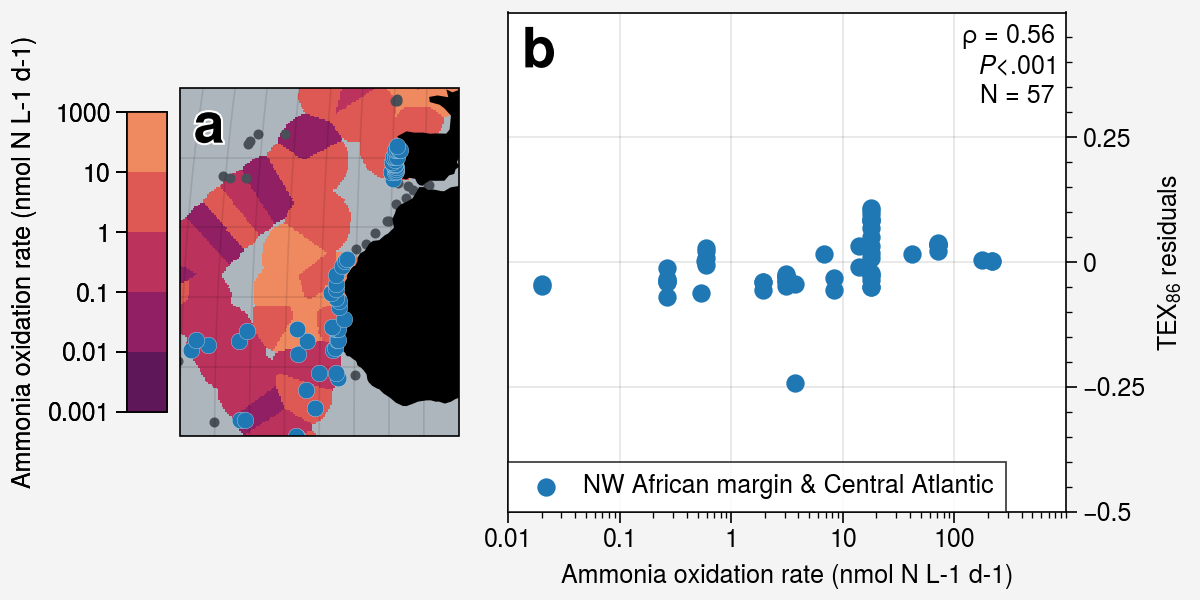

In [60]:
%matplotlib inline
from matplotlib.colors import LogNorm

fig, axs = plot.subplots(ncols=2,
                         proj=('eck3',None),
                         wratios=[0.5,1],
                         figsize=(6,3),share=False,)
axs.format(
    land=True,landzorder=1,
    latlim=(0,50),
    lonlim=(-40,0),
)

ax = axs[0]
ax.format(facecolor='gray5',)
# compute robust-ish vmin/vmax if you like:
vmin, vmax = np.nanpercentile(thermo_ammOxR_filled, [2,98])
m = thermo_ammOxR_filled.plot(ax = ax, robust=True,cmap='matter_r',
                            #   norm=LogNorm(vmin=vmin, vmax=vmax),
                              add_colorbar=False,
                              zorder=0,rasterized=True,
                              levels=[1e-3,1e-2,1e-1,1e0,1e1,1e3],)


ax.colorbar(m,loc='l',shrink=0.6,extend='both',
          label='Ammonia oxidation rate (nmol N L-1 d-1)',
          )
### plot coretop data
plot_data = plot_coretop
plot_x = plot_data['lon']
plot_y = plot_data['lat']
ax.scatter(plot_x,plot_y,m='.',c='gray7',zorder=1,
           transform=ccrs.PlateCarree())    

merged_ds = xr.merge([thermo_ammOxR_filled,gridded_coretop_ds])
nonnan_idx = ~merged_ds['ammOxRate_mean'].isnull() & ~merged_ds['tex_residuals'].isnull()
merged_da = merged_ds.where(nonnan_idx).to_dataframe().reset_index().dropna(subset=['ammOxRate_mean','tex_residuals'])

### build a new color cycle with 50 colors by combining different color cycles


grouped = merged_da[merged_da['lat']<70].groupby('region_ID')
for i, (name, group) in enumerate(grouped):
    if (name == 44.0 or name == 43.0):
        ax.scatter(group['lon'],group['lat'],m='o',mec='w',mew=0.1,zorder=2,c=colors[0],label='')

ax = axs[1]
for i, (name, group) in enumerate(grouped):
    if (name == 44.0 or name == 43.0):
        ax.scatter(group['ammOxRate_mean'],group['tex_residuals'],m='o',zorder=2,c=colors[0],label='NW African margin & Central Atlantic')

reg_data = merged_da[merged_da['region_ID'].isin([44.0,43.0])]
rho, pval = scipy.stats.spearmanr(reg_data['ammOxRate_mean'],reg_data['tex_residuals'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,
        f'$\\rho$ = {rho:.2f}\n{pval_label}\nN = {len(reg_data)}',
        transform=ax.transAxes,
        ha='right',va='top')

h, l = ax.get_legend_handles_labels()
ax.legend(h[1],l[1],loc='ll',ncol=1,fontsize=12)
ax.format(
    xscale='log',
)

ax.format(
    xlabel='Ammonia oxidation rate (nmol N L-1 d-1)',
    ylabel='TEX$_{86}$ residuals',
    xlim=(1e-2,1e3),
    ylim=(-0.5,0.5),
    xticks=[1e-2,1e-1,1e0,1e1,1e2],
    ytickloc='right',
    ytickrange=(-0.5,0.5,0.25),
    yticks=[-0.5,-0.25,0,0.25],
)
### calculate grouped mean and std for tex_residuals and ammOxRate_mean
grouped = merged_da[merged_da['lat']<70].groupby('region_ID')
grouped_mean = grouped[['ammOxRate_mean','tex_residuals']].mean()

axs.format(
    abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':20},
)
fpath = fr'{local_github_path}/figures/'
fname = 'R2R_fig_ammOxR_tex_residuals.png'
fig.savefig(os.path.join(fpath,fname),dpi=300,bb_inches='tight',rasterized=True)

## Fig. S2. Comparison between thermo-T and sub-T from BAYSPAR and TEX86H models

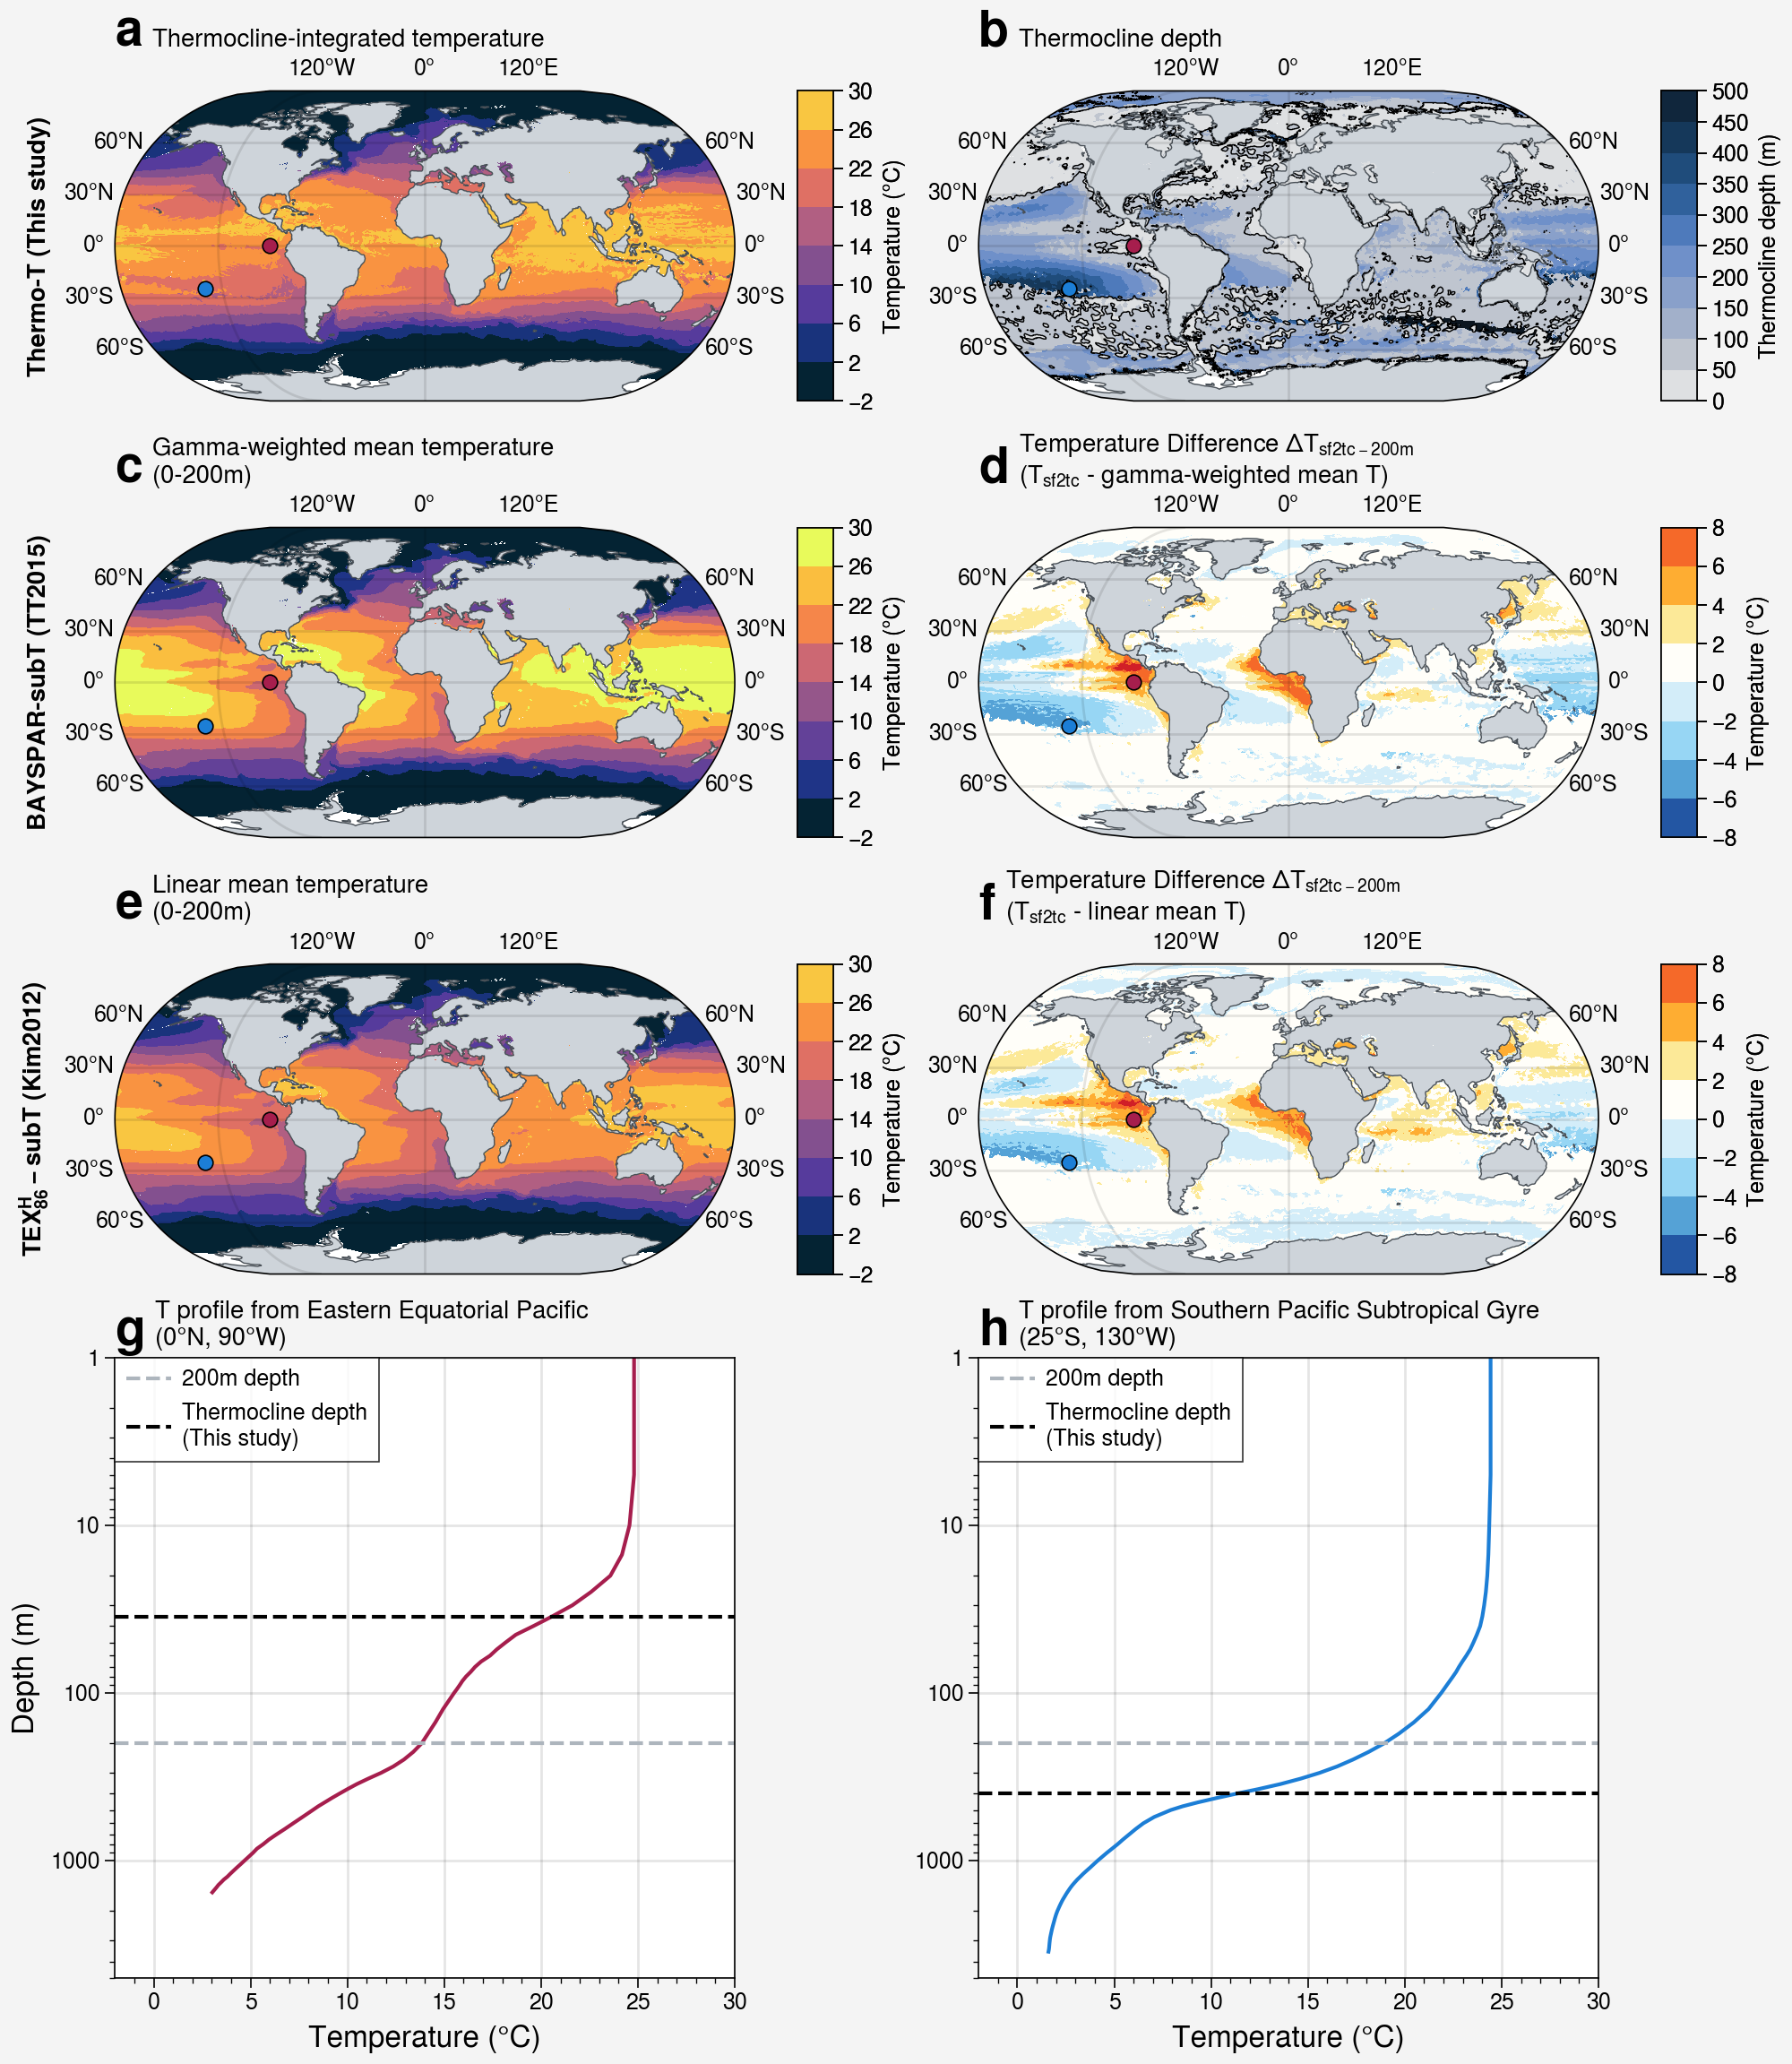

In [61]:
array = [
    [1,2],
    [3,4],
    [5,6],
    [7,8],
    [7,8],
]

fig, axs = plot.subplots(array,
                         proj=('eck3','eck3','eck3','eck3','eck3','eck3',None),
                         share=False,
                         width=10
                         )

ax = axs[0]
m = t_sf2tc_da.plot(ax=ax,levels=np.arange(-2,31,4),
                  cmap='thermal',
                  add_labels=False,
                  cbar_kwargs={'label':'Temperature (\N{DEGREE SIGN}C)'},
                  robust=True,
                  rasterized=True,
                  transform=ccrs.PlateCarree(),
                  )

### plot 200 meter depth contour
ax = axs[1]
thermocline_depth_da.plot(ax=ax,levels=np.arange(0,501,50),
                    cmap='oslo_r',
                    add_labels=False,
                    cbar_kwargs={'label':'Thermocline depth (m)'},
                    rasterized=True,
                    transform=ccrs.PlateCarree(),
                    )

## add 50m contour line
m2 = thermocline_depth_da.plot.contour(ax=ax,levels=[0,50],
                                                 linewidths=0.5,
                                                 colors='k',robust=True)

ax = axs[2]
T_0_200m_gamma_mean.plot(ax=ax,levels=np.arange(-2,31,4),
                  cmap='thermal',
                  add_labels=False,
                  cbar_kwargs={'label':'Temperature (\N{DEGREE SIGN}C)'},
                  robust=True,
                  rasterized=True,
                  transform=ccrs.PlateCarree(),
                  )

### diff T
ax = axs[3]
(t_sf2tc_da-T_0_200m_gamma_mean).plot(ax=ax,levels=np.arange(-8,9,2),
                  cmap='hotcold_r',
                  add_labels=False,
                  cbar_kwargs={'label':'Temperature (\N{DEGREE SIGN}C)'},
                  rasterized=True,
                  transform=ccrs.PlateCarree(),
                  )

ax = axs[4]
T_0_200m_linear_mean.plot(ax=ax,levels=np.arange(-2,31,4),
                  cmap='thermal',
                  add_labels=False,
                  cbar_kwargs={'label':'Temperature (\N{DEGREE SIGN}C)'},
                  rasterized=True,
                  robust=True,
                  transform=ccrs.PlateCarree(),
                  )

### diff T
ax = axs[5]
(t_sf2tc_da-T_0_200m_linear_mean).plot(ax=ax,levels=np.arange(-8,9,2),
                  cmap='hotcold_r',
                  add_labels=False,
                  cbar_kwargs={'label':'Temperature (\N{DEGREE SIGN}C)'},
                  rasterized=True,
                  transform=ccrs.PlateCarree(),
                  )

### example vertical profile
sel_lat = 0
sel_lon = -90
axs[0:6].scatter(sel_lon,sel_lat,
           m='o',c='pink9',mec='k',zorder=2,label='')


ax = axs[6]
plot_T = T_da.sel(lat=sel_lat,lon=sel_lon,method='nearest')
plot_depth = plot_T['depth'].values
ax.plot(plot_T,plot_depth,c='pink9')
ax.format(
    xlabel='Temperature (\N{DEGREE SIGN}C)',
    ylabel='Depth (m)',
    xlim=(-2,30),
    ylim=(5000,1),
    yscale='log',
)

thermoT_depth = thermocline_depth_da.sel(lat=sel_lat,lon=sel_lon,method='nearest')
ax.axhline(thermoT_depth,ls='--',c='k',label='Thermocline depth\n(This study)')
ax.axhline(200,ls='--',c='gray5',label='200m depth')


### example vertical profile
sel_lat = -25
sel_lon = -130
axs[0:6].scatter(sel_lon,sel_lat,
           m='o',c='blue7',mec='k',zorder=2,label='')


ax = axs[7]
plot_T = T_da.sel(lat=sel_lat,lon=sel_lon,method='nearest')
plot_depth = plot_T['depth'].values
ax.plot(plot_T,plot_depth,c='blue7')
ax.format(
    xlabel='Temperature (\N{DEGREE SIGN}C)',
    ylabel='',
    xlim=(-2,30),
    ylim=(5000,1),
    yscale='log',
)

thermoT_depth = thermocline_depth_da.sel(lat=sel_lat,lon=sel_lon,method='nearest')
ax.axhline(thermoT_depth,ls='--',c='k',label='Thermocline depth\n(This study)')
ax.axhline(200,ls='--',c='gray5',label='200m depth')

h, l = axs[7].get_legend_handles_labels()
axs[-1,:].legend(h[::-1],l[::-1],loc='ul',ncols=1)

title_list = [
    'Thermocline-integrated temperature',
    'Thermocline depth',
    'Gamma-weighted mean temperature\n(0-200m)',
    'Temperature Difference $\Delta$T$_{sf2tc - 200m}$\n(T$_{sf2tc}$ - gamma-weighted mean T)',
    'Linear mean temperature\n(0-200m)',
    'Temperature Difference $\Delta$T$_{sf2tc - 200m}$\n(T$_{sf2tc}$ - linear mean T)',
    'T profile from Eastern Equatorial Pacific\n(0\N{DEGREE SIGN}N, 90\N{DEGREE SIGN}W)',
    'T profile from Southern Pacific Subtropical Gyre\n(25\N{DEGREE SIGN}S, 130\N{DEGREE SIGN}W)',
]

for i in range(8):
    axs[i].format(ltitle=title_list[i],)

axs.format(
    abc=True, abcloc='l', abcstyle='a', rc_kw={'abc.size':20},
    land=True, landcolor='gray4', landzorder=0, latlabels='lr', lonlabels='top',
    gridcolor='k', gridlinewidth=1,
    latlines=30, latlocator=[-60,-30,0,30,60],
    lonlines=120, lonlocator=[-120,0,120],
    coast=True, coastcolor='gray7', coastlinewidth=0.5, coastzorder=1,
    labelsize=12,
    rowlabels=[
        'Thermo-T (This study)',
        'BAYSPAR-subT (TT2015)',
        'TEX$_{86}^{H}-subT$ (Kim2012)',
        ''
    ]
)

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S2_subsurface_T_comparison.png'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660,
  rasterize=['contourf', 'pcolormesh'])

## Fig S4. New core-top measurements

In [62]:
fpath = fr'{local_github_path}/spreadsheets/'
fname = 'ds01_updated_global_coretop_tex.csv'

coretop_raw_df = pd.read_csv(os.path.join(fpath,fname))
coretop_raw_df

,index_column,core_name,core_type,sample_depth_start,sample_depth_end,latitude,longitude,depth,tex86,fGDGT_0,...,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,bit,publicationYear,reference_name,remark,reference_link,dataset_DOI
0,JET_RR_00001,GeoB7702-3,GC,5.0000,6.0000,31.6517,34.0733,562.0000,0.6620,NaN,...,NaN,NaN,NaN,NaN,0.2560,2010,Castaneda2010,Data published in Tierney & Tingley (2015),http://dx.doi.org/10.1029/2009PA001740,'https://doi.org/10.25921/wt2r-sc81
1,JET_RR_00002,KNR195-5-5 MC11,MC,6.0000,8.0000,-1.5327,-86.7852,2288.0000,0.6029,0.3306,...,0.0642,0.0049,0.4992,0.0336,0.0268,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,10.5281/zenodo.14806962
2,JET_RR_00003,KNR195-5-6 MC12,MC,0.0000,1.0000,-3.7105,-81.1153,378.0000,0.5700,NaN,...,NaN,NaN,NaN,NaN,NaN,2011,Chazen2011,Data published in Tierney & Tingley (2015),https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81
3,JET_RR_00004,KNR195-5-7 MC16,MC,0.0000,1.0000,-3.7502,-81.1358,379.0000,0.5720,NaN,...,NaN,NaN,NaN,NaN,NaN,2011,Chazen2011,Data published in Tierney & Tingley (2015),https://repository.library.brown.edu/studio/it...,'https://doi.org/10.25921/wt2r-sc81
4,JET_RR_00005,KNR195-5-8 MC18,MC,4.0000,6.0000,-3.9690,-81.3100,1024.0000,0.5994,0.2824,...,0.0524,0.0107,0.5608,0.0309,0.0334,2025,this study,Reanalysed samples of Chazen2011 by this study,NaN,10.5281/zenodo.14806962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2079,JET_RR_02080,AMD17_176_BC,NaN,NaN,NaN,69.6000,-65.4000,267.0000,0.4000,0.6900,...,0.0030,0.0010,0.2920,0.0020,NaN,2023,Harning2023,Data from original source,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212
2080,JET_RR_02081,AMD17_8.1_BC,NaN,NaN,NaN,69.4100,-64.4000,1054.0000,0.3226,0.7100,...,0.0060,0.0010,0.2610,0.0030,NaN,2023,Harning2023,Data from original source,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212
2081,JET_RR_02082,AMD17_Disko_Fan_BC,NaN,NaN,NaN,67.9700,-59.4900,1012.0000,0.3750,0.6800,...,0.0070,0.0020,0.2920,0.0030,NaN,2023,Harning2023,Data from original source,https://doi.org/10.5194/bg-20-229-2023,https://doi.org/10.1594/PANGAEA.956212
2082,JET_RR_02083,DSDP591_0-3cm_PC,PC,0.0000,3.0000,-31.5843,164.4487,2131.0000,0.6712,0.2832,...,0.0778,0.0117,0.5042,0.0532,0.0690,2025,this study,New GDGT measurements published in this study,NaN,10.5281/zenodo.14806962


This study: 170
TT2015: 865
post TT2015: 1049


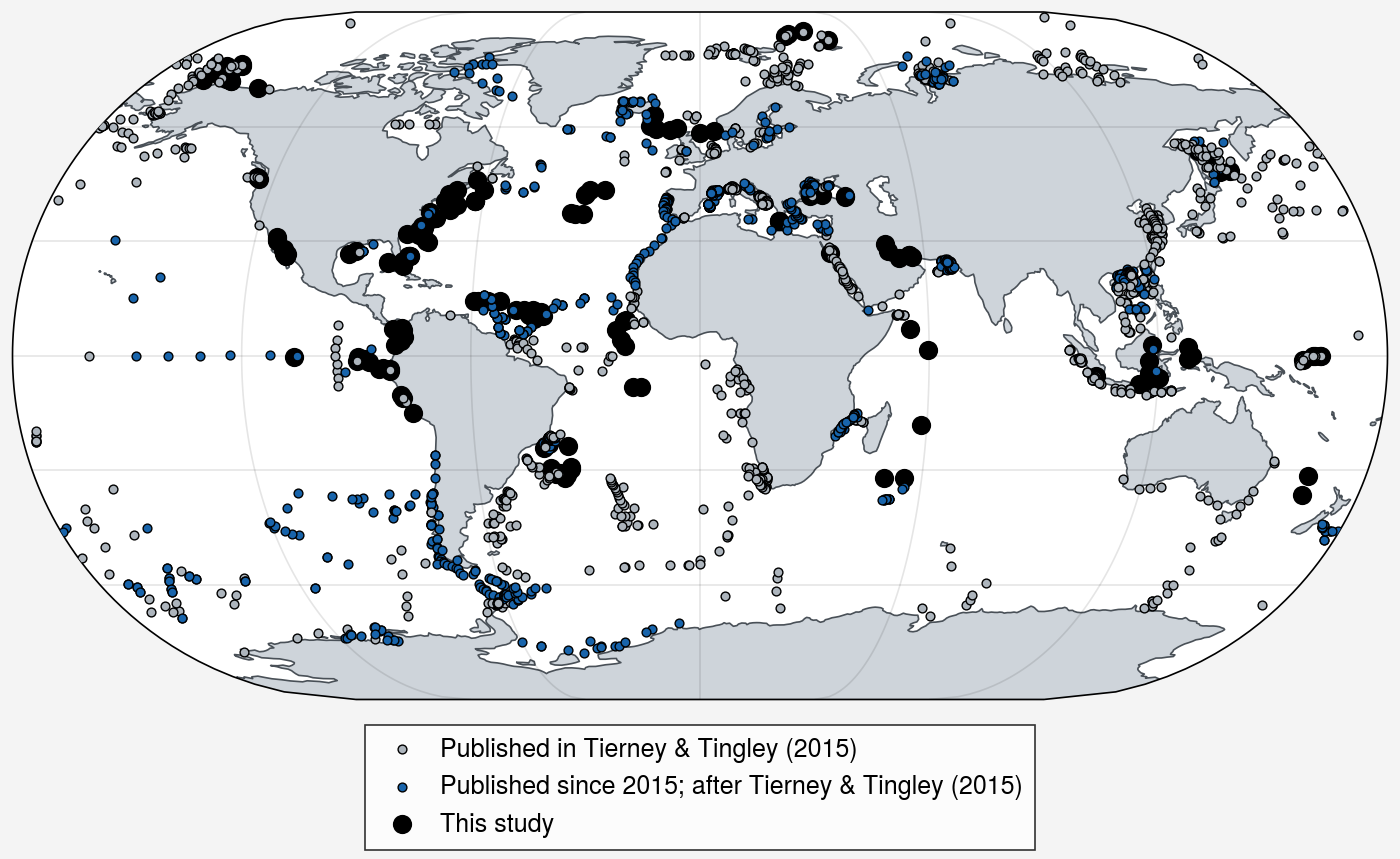

In [63]:
plot.rc.abc = False
fig, axs = plot.subplots(proj=('eck3'),share=0,width=7)

ax = axs[0]
ax.format(
    land=True,landcolor='gray4',landzorder=0,
    coast=True,coastcolor='gray7',coastzorder=1,
)
plot_data = coretop_raw_df
grouped = plot_data.groupby('reference_name')
post_TT2015_data = 0
TT2015_data = 0
thisStudy_data = 0
for name, group in grouped:
    plot_lat = group['latitude']
    plot_lon = group['longitude']
    
    if name == 'this study':
        ax.scatter(plot_lon,plot_lat,
                   c='k',marker='o',s=40,
                   zorder=2,
                   label=name)
        thisStudy_data += len(group)
    elif ((group['publicationYear'].unique()[0] < 2015)
          and name != 'Tierney2015'):
        ax.scatter(plot_lon,plot_lat,
                   c='gray5',marker='o',s=10,
                   mec='k',mew=0.5,
                   zorder=3,
                   label=name)
        post_TT2015_data += len(group)
    else:
        ax.scatter(plot_lon,plot_lat,
                   c='blue9',marker='o',s=10,
                   mec='k',mew=0.5,
                   zorder=3,
                   label=name)
        TT2015_data += len(group)
        
print(f'This study: {thisStudy_data}')
print(f'TT2015: {TT2015_data}')
print(f'post TT2015: {post_TT2015_data}')
h, l = ax.get_legend_handles_labels()
item_idx = [-2,-4,-1]
fig.legend([h[i] for i in item_idx],
           labels=['Published in Tierney & Tingley (2015)',
                   'Published since 2015; after Tierney & Tingley (2015)',
                   'This study'
                   ],
           loc='b',ncol=1,fontsize=10)
        
fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S4_coretop_sites.pdf'
fig.save(fpath+fname,dpi=330,bbox_inches='tight',embed_fonts=True)


## Fig. S5 Sliding Window for low nutrient-threshold

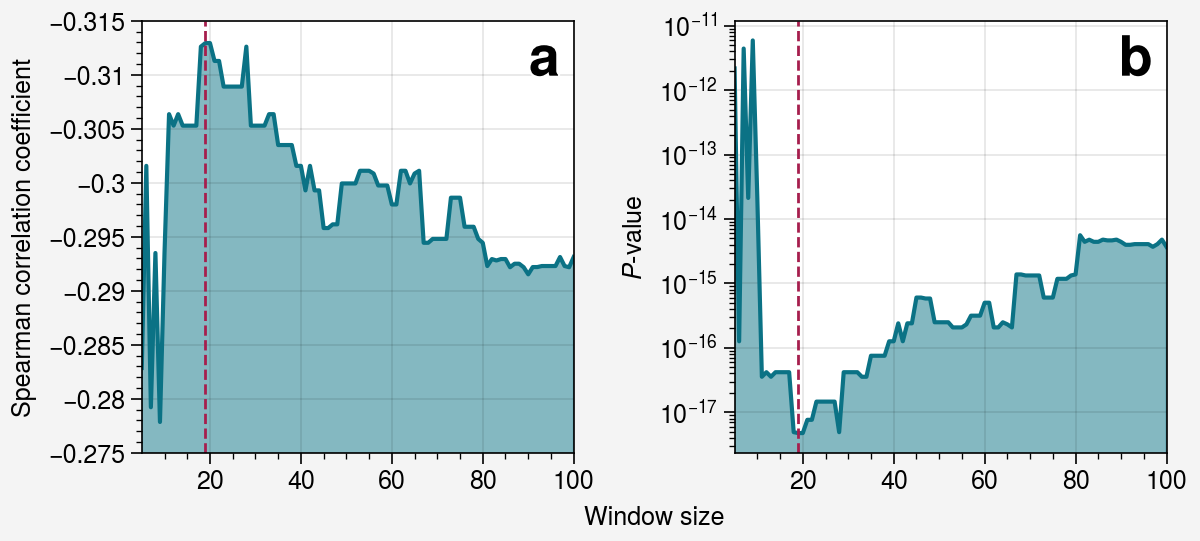

In [64]:
fig, axs = plot.subplots(width=6,ncols=2,sharey=0)

window_size_score_df = pd.DataFrame({'window_size':window_size_fig1,
                                     'score':score_list_fig1,
                                     'pval':pval_list_fig1})

ax = axs[0]
### fill_between y
ax.fill_between(window_size_score_df['window_size'],window_size_score_df['score'],
                color='cyan9',alpha=0.5)
ax.plot(window_size_score_df['window_size'],window_size_score_df['score'],c='cyan9')

ax.format(
    xlabel='Window size',
    ylabel='Spearman correlation coefficient',
    ylim=(-0.275,-0.315)
)

ax = axs[1]
### fill_between y
ax.fill_between(window_size_score_df['window_size'],window_size_score_df['pval'],
                color='cyan9',alpha=0.5)
ax.plot(window_size_score_df['window_size'],window_size_score_df['pval'],c='cyan9')

ax.format(
    xlabel='Window size',
    ylabel=r'$\it{P}$-value',
    yscale='log',
    yformatter='log',
)

#### ax.axvline at the highest score and lowest pval
window_size = window_size_score_df['window_size']
score_list = window_size_score_df['score']
best_window_size = window_size[np.argmin(score_list)]
axs.axvline(best_window_size,c='pink9',ls='--',lw=1)
# ax.text(best_window_size,0.98,f'{best_window_size}',transform=ax.get_yaxis_transform(),
#         ha='center',va='top',rotation=90)

#########################################################################################
axs.format(abc=True,abcloc='ur',abcstyle='a',rc_kw={'abc.size':20},)

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S5_sliding_window_scores.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

## Fig. S6. Comparison of nutrient effect from different calibrations

best_window_size = 19
best_window_size = 20
BAYSPAR r2 = 0.822
best_window_size = 55
Kim2012 r2 = 0.344
best_window_size = 84


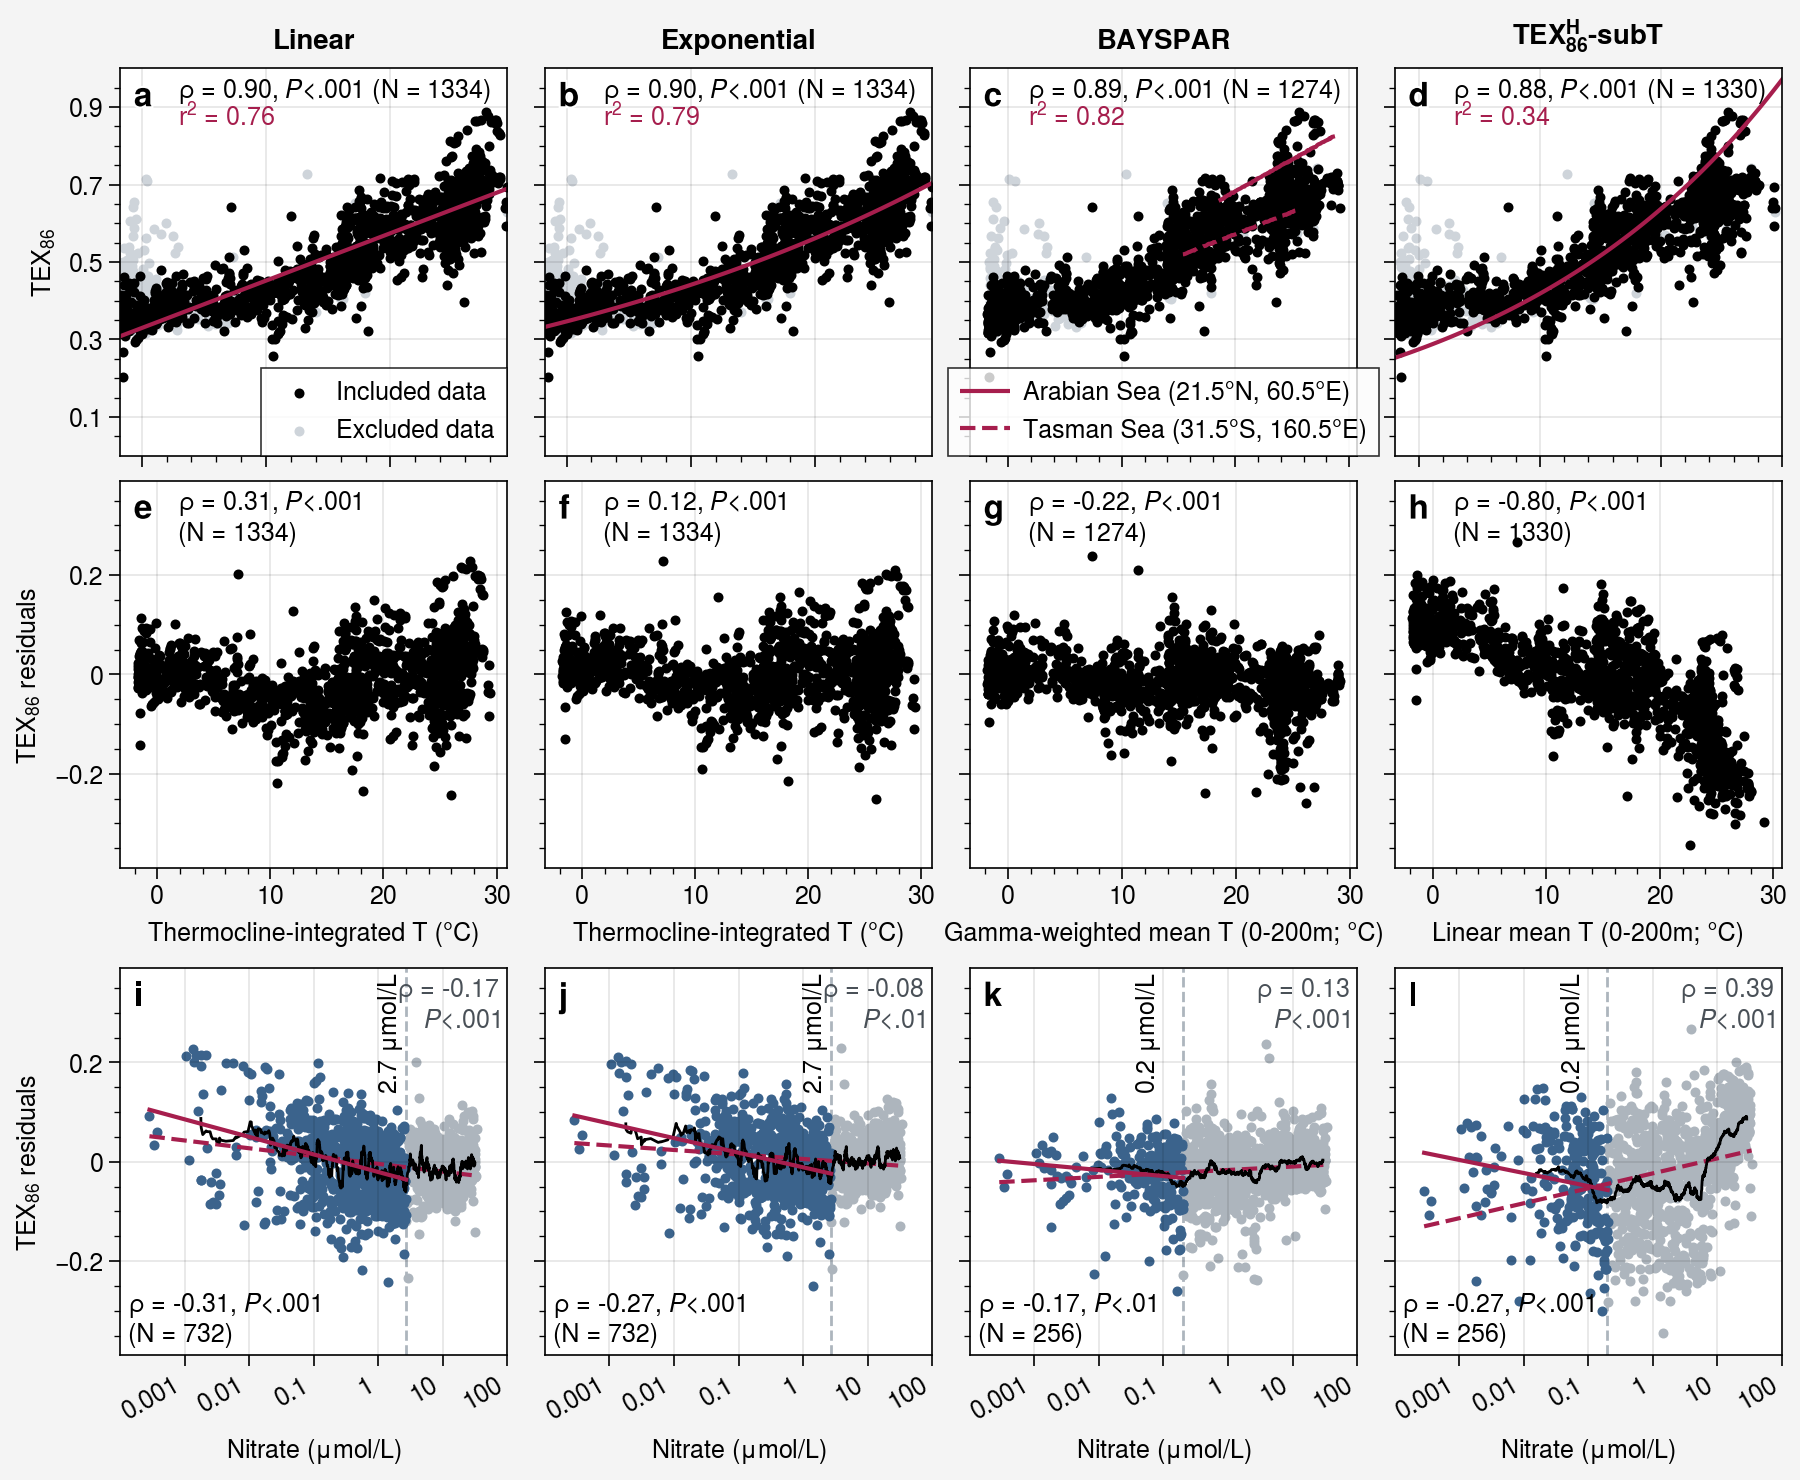

In [65]:
# qt or inline
%matplotlib inline

def running_mean_log10(x, y, window_size):
        # Convert x to log10 scale
        log_x = np.log10(x)
        
        # Create a DataFrame with log_x and y
        df = pd.DataFrame({'log_x': log_x, 'y': y})
        
        # Sort the DataFrame by log_x
        df = df.sort_values(by='log_x')
        
        # Calculate the running mean of y with the specified window size
        df['y_running_mean'] = df['y'].rolling(window=window_size, center=True).mean()
        
        return df['log_x'], df['y_running_mean']



fig, axs = plot.subplots(width=9,
                         ncols=4,nrows=3,
                         share=False,
                         wspace=1.5,
                         hspace=[1,4]
                         )

####### plot coretop data 

plot_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['t_sf2tc_avg',
                                                  'tex_median']).reset_index()
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
axs[0,:2].scatter(plot_x,plot_y,
           m='.',c='k',zorder=2,label='Included data')

plot_data = plot_coretop[plot_coretop['lat']>70].dropna(subset=['t_sf2tc_avg','tex_median'])
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_median']
axs[0,:2].scatter(plot_x,plot_y,
           m='.',c='gray4',zorder=1,
           label='Excluded data')

plot_x = exclude_coretop['thermocline_T_depthIntegral']
plot_y = exclude_coretop['TEX86']
axs[0,:2].scatter(plot_x,plot_y,m='.',c='gray4',zorder=0,label='')

#### plot coretop data for BAYSPAR

plot_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['subT_gamma_mean_200m','tex_median'])
plot_x = plot_data['subT_gamma_mean_200m']
plot_y = plot_data['tex_median']
axs[0,2].scatter(plot_x,plot_y,
                  m='.',c='k',zorder=2,label='Included data')
plot_data = plot_coretop[plot_coretop['lat']>70].dropna(subset=['subT_gamma_mean_200m','tex_median'])
plot_x = plot_data['subT_gamma_mean_200m']
plot_y = plot_data['tex_median']
axs[0,2].scatter(plot_x,plot_y,
                m='.',c='gray4',zorder=1,
                label='Excluded data')
plot_x = exclude_coretop['subT_gamma_mean_200m']
plot_y = exclude_coretop['TEX86']
axs[0,2].scatter(plot_x,plot_y,m='.',c='gray4',zorder=0,label='')

#### plot coretop data for Kim2012
plot_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['subT_linear_mean_200m','tex_median'])
plot_x = plot_data['subT_linear_mean_200m']
plot_y = plot_data['tex_median']
axs[0,3].scatter(plot_x,plot_y,
                        m='.',c='k',zorder=2,label='Included data')
plot_data = plot_coretop[plot_coretop['lat']>70].dropna(subset=['subT_linear_mean_200m','tex_median'])
plot_x = plot_data['subT_linear_mean_200m']
plot_y = plot_data['tex_median']
axs[0,3].scatter(plot_x,plot_y,
                m='.',c='gray4',zorder=1,
                label='Excluded data')
plot_x = exclude_coretop['subT_linear_mean_200m']
plot_y = exclude_coretop['TEX86']
axs[0,3].scatter(plot_x,plot_y,m='.',c='gray4',zorder=0,label='')

##########################################################################################
ax = axs[0,0]
reg_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['t_sf2tc_avg','tex_median'])
reg_data2 = reg_data.dropna(subset=['t_sf2tc_avg','tex_median'])
ols_thermoT_thisStudy = LinearRegression()

XX = reg_data2['t_sf2tc_avg']
yy = reg_data2['tex_median']

ols_thermoT_thisStudy.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols_thermoT_thisStudy.predict(XX_sample.reshape(-1,1))
ax.plot(XX_sample,yy_pred,c='pink9')
rho, pval = spearmanr(reg_data2['t_sf2tc_avg'],reg_data2['tex_median'])
pval_label = label_pvalues(pval)
r2_ = ols_thermoT_thisStudy.score(XX.values.reshape(-1,1),yy)

ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(reg_data2)})',
        transform=ax.transAxes,
        ha='left',va='top')
ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
        color='pink9',
        transform=ax.transAxes,
        ha='left',va='top')

h, l = ax.get_legend_handles_labels()
ax.legend(h,l,loc='lr',ncols=1)
ax.format(
        ylim=(0,0.95),
        yticks=np.arange(0.1,1,0.2),
)

ax = axs[1,0]
plot_data = reg_data2
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_residuals']
ax.scatter(plot_x,plot_y,m='.',c='k',zorder=2,label='Included data')

rho, pval = spearmanr(plot_x,plot_y)
pval_label = label_pvalues(pval)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')

ax = axs[2,0]
reg_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['no3_sf2tc_avg','tex_median'])
reg_data2 = reg_data.dropna(subset=['no3_sf2tc_avg','tex_median'])
reg_data2['log_thermocl_depthIntg_nitrate'] = np.log10(reg_data2['no3_sf2tc_avg'])
reg_data2['log_thermocl_depthIntg_nitrate'] = reg_data2['log_thermocl_depthIntg_nitrate'].replace([-np.inf,np.inf],np.nan)
ols = LinearRegression()
XX = reg_data2['log_thermocl_depthIntg_nitrate']
yy = reg_data2['tex_residuals']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))
ax.plot(10**XX_sample,yy_pred,c='pink9',ls='--')
rho, pval = spearmanr(reg_data2['no3_sf2tc_avg'],reg_data2['tex_residuals'])
pval_label = label_pvalues(pval)
r2_ = ols.score(XX.values.reshape(-1,1),yy)

ax.text(0.98,0.98,f'$\\rho$ = {rho:.2f}\n{pval_label}',
        transform=ax.transAxes,
        ha='right',va='top',
        c='gray7')

sel_x_param = 'no3_sf2tc_avg'
sel_y_param = 'tex_residuals'
### linear fit between log(nitrate) and TEX residuals
pre_reg_data = reg_data2
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)

### determine best window size
window_size = np.arange(5,101,1)
score_list = []
pval_list = []
for sel_window_size in window_size:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size)
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data2 = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data2[sel_x_param],reg_data2[sel_y_param])
        score_list.append(rho)
        pval_list.append(pval)
best_window_size = window_size[np.argmin(score_list)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size)
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)
ax.plot(10**log_x,y_running_mean,c='k',lw=1)

plot_x = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_x_param]
plot_y = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_y_param]
ax.scatter(plot_x,plot_y,marker='.',color='denim',label='Coretops')

plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=[sel_x_param,sel_y_param])
plot_x_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_x_param]
plot_y_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_y_param]
ax.scatter(plot_x_exclude,plot_y_exclude,
            marker='.',color='gray5',
            label='Excluded data',zorder=0)


reg_data_filtered = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold]

reg_data_filtered['log_'+sel_x_param] = np.log10(reg_data_filtered[sel_x_param])
reg_data_filtered['log_'+sel_x_param] = reg_data_filtered['log_'+sel_x_param].replace([-np.inf,np.inf],np.nan)
reg_data_filtered = reg_data_filtered.dropna(how='any',subset=[sel_x_param,sel_y_param,'log_'+sel_x_param])

ols = LinearRegression()
ols.fit(reg_data_filtered['log_'+sel_x_param].values.reshape(-1,1),reg_data_filtered[sel_y_param])
plot_x_fit = np.linspace(reg_data_filtered['log_'+sel_x_param].min(),reg_data_filtered['log_'+sel_x_param].max(),100)
plot_y_fit = ols.predict(plot_x_fit.reshape(-1,1))
ax.plot(10**plot_x_fit,plot_y_fit,c='pink9',
        label='TEX residuals')

rho, pval = spearmanr(reg_data_filtered[sel_x_param],reg_data_filtered[sel_y_param])
pval_label = label_pvalues(pval)
r2_ = ols.score(reg_data_filtered['log_'+sel_x_param].values.reshape(-1,1),reg_data_filtered[sel_y_param])

ax.text(0.02,0.02,
        f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(reg_data_filtered)})',
        transform=ax.transAxes,
        ha='left',va='bottom')

# ax = axs[3,0]
# plot_data = pre_reg_data[pre_reg_data[sel_x_param]>lowno3_threshold]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['tex_median']
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')

# ols_lineartex_highno3 = LinearRegression()
# ols_lineartex_highno3.fit(plot_data['t_sf2tc_avg'].values.reshape(-1,1),plot_data['tex_median'])
# XX_sample = np.linspace(plot_data['t_sf2tc_avg'].min(),plot_data['t_sf2tc_avg'].max(),100)
# yy_pred = ols_lineartex_highno3.predict(XX_sample.reshape(-1,1))
# ax.plot(XX_sample,yy_pred,c='pink9')

# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)
# r2_ = ols_lineartex_highno3.score(plot_data['t_sf2tc_avg'].values.reshape(-1,1),plot_data['tex_median'])
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')
# ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
#         color='pink9',
#         transform=ax.transAxes,
#         ha='left',va='top')

# plot_data['pred_tex_filtered'] = ols_lineartex_highno3.predict(plot_data['t_sf2tc_avg'].values.reshape(-1,1))
# plot_data['tex_filtered_residuals'] = plot_data['tex_median'] - plot_data['pred_tex_filtered']
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['tex_filtered_residuals']

# ax = axs[4,0]
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')
# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')


######################################################################
ax = axs[0,1]
reg_data = plot_coretop[plot_coretop['lat']<70].dropna(subset=['t_sf2tc_avg','tex_median'])
reg_data2 = reg_data.dropna(subset=['t_sf2tc_avg','tex_median'])
ols_Lntex_thermoT_thisStudy = LinearRegression()
ols_Logtex_thermoT_thisStudy = LinearRegression()

XX = reg_data2['t_sf2tc_avg']
yy = np.log(reg_data2['tex_median'])
yy2 = np.log10(reg_data2['tex_median'])

ols_Lntex_thermoT_thisStudy.fit(XX.values.reshape(-1,1),yy)
# ols_Logtex_thermoT_thisStudy.fit(XX.values.reshape(-1,1),yy2)

XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols_Lntex_thermoT_thisStudy.predict(XX_sample.reshape(-1,1))
# yy2_pred = ols_Logtex_thermoT_thisStudy.predict(XX_sample.reshape(-1,1))

ax.plot(XX_sample,np.exp(yy_pred),c='pink9')
# ax.plot(XX_sample,10**yy2_pred,c='pink9',ls='--')

rho, pval = spearmanr(reg_data2['t_sf2tc_avg'],reg_data2['tex_median'])
pval_label = label_pvalues(pval)
r2_ = ols_Lntex_thermoT_thisStudy.score(XX.values.reshape(-1,1),yy)

ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(reg_data2)})',
        transform=ax.transAxes,
        ha='left',va='top')
ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
        color='pink9',
        transform=ax.transAxes,
        ha='left',va='top')


ax = axs[1,1]
plot_data = reg_data2
plot_data['pred_exp_tex_thermoT'] = np.exp(ols_Lntex_thermoT_thisStudy.predict(XX.values.reshape(-1,1)))
plot_data['tex_exp_residuals'] = plot_data['tex_median'] - plot_data['pred_exp_tex_thermoT']
plot_x = plot_data['t_sf2tc_avg']
plot_y = plot_data['tex_exp_residuals']
ax.scatter(plot_x,plot_y,m='.',c='k',zorder=2,label='Included data')

rho, pval = spearmanr(plot_x,plot_y)
pval_label = label_pvalues(pval)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')

ax = axs[2,1]
plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['no3_sf2tc_avg','tex_residuals'])
pred_Lntex = ols_Lntex_thermoT_thisStudy.predict(plot_data['t_sf2tc_avg'].values.reshape(-1,1))
plot_data['tex_residuals_exp'] = plot_data['tex_median'] - np.exp(pred_Lntex)
reg_data = plot_data
reg_data['log_thermocl_depthIntg_nitrate'] = np.log10(reg_data['no3_sf2tc_avg'])
reg_data['log_thermocl_depthIntg_nitrate'] = reg_data['log_thermocl_depthIntg_nitrate'].replace([-np.inf,np.inf],np.nan)
ols = LinearRegression()
XX = reg_data['log_thermocl_depthIntg_nitrate']
yy = reg_data['tex_residuals_exp']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))
ax.plot(10**XX_sample,yy_pred,c='pink9',ls='--')
rho, pval = spearmanr(reg_data['no3_sf2tc_avg'],reg_data['tex_residuals_exp'])
r2 = ols.score(XX.values.reshape(-1,1),yy)
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'$\\rho$ = {rho:.2f}\n{pval_label}',
        transform=ax.transAxes,
        ha='right',va='top',
        c='gray7')

sel_x_param = 'no3_sf2tc_avg'
sel_y_param = 'tex_residuals_exp'
### linear fit between log(nitrate) and TEX residuals
pre_reg_data = plot_data
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)

### determine best window size
window_size = np.arange(5,101,1)
score_list = []
pval_list = []
for sel_window_size in window_size:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size)
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
        score_list.append(rho)
        pval_list.append(pval)
best_window_size = window_size[np.argmin(score_list)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size)
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)
ax.plot(10**log_x,y_running_mean,c='k',lw=1)

plot_x = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_x_param]
plot_y = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_y_param]
ax.scatter(plot_x,plot_y,marker='.',color='denim',label='Coretops')


plot_data = pre_reg_data[pre_reg_data['lat']<70].dropna(subset=[sel_x_param,sel_y_param])
plot_x_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_x_param]
plot_y_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_y_param]
ax.scatter(plot_x_exclude,plot_y_exclude,
            marker='.',color='gray5',
            label='Excluded data',zorder=0)


reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold]

reg_data['log_'+sel_x_param] = np.log10(reg_data[sel_x_param])
reg_data['log_'+sel_x_param] = reg_data['log_'+sel_x_param].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=[sel_x_param,sel_y_param,'log_'+sel_x_param])
ols = LinearRegression()
ols.fit(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
plot_x_fit = np.linspace(reg_data['log_'+sel_x_param].min(),reg_data['log_'+sel_x_param].max(),100)
plot_y_fit = ols.predict(plot_x_fit.reshape(-1,1))
ax.plot(10**plot_x_fit,plot_y_fit,c='pink9',
        label='TEX residuals')
### print regression equation

rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
pval_label = label_pvalues(pval)
r2_ = ols.score(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
ax.text(0.02,0.02,
        f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(reg_data)})',
        transform=ax.transAxes,
        ha='left',va='bottom')

# ax = axs[3,1]

# plot_data = pre_reg_data[pre_reg_data[sel_x_param]>lowno3_threshold]
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['tex_median']
# ln_plot_y = np.log(plot_data['tex_median'])
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')

# ols_lntex_highno3 = LinearRegression()
# ols_lntex_highno3.fit(plot_x.values.reshape(-1,1),ln_plot_y)
# XX_sample = np.linspace(plot_x.min(),plot_x.max(),100)
# yy_pred = ols_lntex_highno3.predict(XX_sample.reshape(-1,1))
# ax.plot(XX_sample,np.exp(yy_pred),c='pink9')

# rho, pval = spearmanr(plot_x,ln_plot_y)
# pval_label = label_pvalues(pval)
# r2_ = ols_lntex_highno3.score(plot_x.values.reshape(-1,1),ln_plot_y)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')
# ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
#         color='pink9',
#         transform=ax.transAxes,
#         ha='left',va='top')

# plot_data['pred_tex_exp_filtered'] = np.exp(ols_lntex_highno3.predict(plot_x.values.reshape(-1,1)))
# plot_data['tex_exp_filtered_residuals'] = plot_data['tex_median'] - plot_data['pred_tex_exp_filtered']
# plot_x = plot_data['t_sf2tc_avg']
# plot_y = plot_data['tex_exp_filtered_residuals']

# ax = axs[4,1]
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')
# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')

#########################################################################################
# Plot bayspar subT for comparison

ax = axs[0,2]
plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['t_sf2tc_avg',
                                                  'tex_median']).reset_index()

plot_data['pred_bsr_subt_tex'] = plot_data['pred_bsr_subt_tex'].replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['pred_bsr_subt_tex'])
plot_data['tex_residuals_bayspar'] = plot_data['tex_median'] - plot_data['pred_bsr_subt_tex']
plot_data['tex_residuals_bayspar'] = plot_data['tex_residuals_bayspar'].replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['pred_bsr_subt_tex','tex_residuals_bayspar'])

## calculate r2 for the BAYSPAR data by hand between the predicted and observed TEX
SSR = np.sum((plot_data['pred_bsr_subt_tex'] - plot_data['tex_median'])**2)
SST = np.sum((plot_data['tex_median'] - plot_data['tex_median'].mean())**2)
r2_ = 1 - SSR/SST
print(f'BAYSPAR r2 = {r2_:.3f}')

### plot BAYSPAR curve for selected lat/lon
sel_lat = 21.5
sel_lon = 60.5
sel_t = np.atleast_1d(T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values)[0]
subt_range = np.arange(sel_t-5,sel_t+5,0.1)
pred_bayspar_subt_tex = bsr.predict_tex(subt_range,sel_lat,sel_lon,temptype='subt').percentile(50)
ax.plot(subt_range,pred_bayspar_subt_tex,c='pink9',label='Arabian Sea (21.5\N{DEGREE SIGN}N, 60.5\N{DEGREE SIGN}E)')

sel_lat = -31.5
sel_lon = 160.5
sel_t = np.atleast_1d(T_0_200m_gamma_mean.sel(lat=sel_lat,lon=sel_lon,method='nearest').values)[0]
subt_range = np.arange(sel_t-5,sel_t+5,0.1)
pred_bayspar_subt_tex = bsr.predict_tex(subt_range,sel_lat,sel_lon,temptype='subt').percentile(50)
ax.plot(subt_range,pred_bayspar_subt_tex,c='pink9',ls='--',label='Tasman Sea (31.5\N{DEGREE SIGN}S, 160.5\N{DEGREE SIGN}E)')

rho, pval = spearmanr(plot_data['subT_gamma_mean_200m'],plot_data['tex_median'])
pval_label = label_pvalues(pval)

ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')
ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
        color='pink9',
        transform=ax.transAxes,
        ha='left',va='top')

h, l = ax.get_legend_handles_labels()
ax.legend(h[:2],l[:2],loc='lower center',ncols=1)
ax.format(
        ylim=(0,0.95),
        yticks=np.arange(0.1,1,0.2),
)

ax = axs[1,2]
plot_x = plot_data['subT_gamma_mean_200m']
plot_y = plot_data['tex_residuals_bayspar']
ax.scatter(plot_x,plot_y,m='.',c='k',zorder=2,label='Included data')

rho, pval = spearmanr(plot_x,plot_y)
pval_label = label_pvalues(pval)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')


#### BAYSPAR nitrate vs tex residuals
ax = axs[2,2]
plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['t_sf2tc_avg',
                                                  'tex_median']).reset_index()


plot_data['pred_bsr_subt_tex'] = plot_data['pred_bsr_subt_tex'].replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['pred_bsr_subt_tex'])
plot_data['tex_residuals_bayspar'] = plot_data['tex_median'] - plot_data['pred_bsr_subt_tex']
plot_data['tex_residuals_bayspar'] = plot_data['tex_residuals_bayspar'].replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['pred_bsr_subt_tex','tex_residuals_bayspar'])

reg_data = plot_data
reg_data['log_thermocl_depthIntg_nitrate'] = np.log10(reg_data['no3_sf2tc_avg'])
reg_data['log_thermocl_depthIntg_nitrate'] = reg_data['log_thermocl_depthIntg_nitrate'].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=['log_thermocl_depthIntg_nitrate'])
ols = LinearRegression()
XX = reg_data['log_thermocl_depthIntg_nitrate']
yy = reg_data['tex_residuals_bayspar']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))

ax.plot(10**XX_sample,yy_pred,c='pink9',ls='--')
rho, pval = spearmanr(reg_data['no3_sf2tc_avg'],reg_data['tex_residuals_bayspar'])
r2 = ols.score(XX.values.reshape(-1,1),yy)
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'$\\rho$ = {rho:.2f}\n{pval_label}',
        transform=ax.transAxes,
        ha='right',va='top',
        c='gray7')
sel_x_param = 'no3_sf2tc_avg'
sel_y_param = 'tex_residuals_bayspar'
### linear fit between log(nitrate) and TEX residuals
pre_reg_data = plot_data.dropna(subset=[sel_x_param,sel_y_param])
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)
### determine best window size
window_size = np.arange(5,101,1)
score_list = []
pval_list = []
for sel_window_size in window_size:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size)
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
        score_list.append(rho)
        pval_list.append(pval)
best_window_size = window_size[np.argmin(score_list)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size)
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)

ax.plot(10**log_x,y_running_mean,c='k',lw=1)
plot_x = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_x_param]
plot_y = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_y_param]
ax.scatter(plot_x,plot_y,marker='.',color='denim',label='Coretops')
plot_data = pre_reg_data[pre_reg_data['lat']<70].dropna(subset=[sel_x_param,sel_y_param])
plot_x_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_x_param]
plot_y_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_y_param]
ax.scatter(plot_x_exclude,plot_y_exclude,
            marker='.',color='gray5',
            label='Excluded data',zorder=0)
reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold]
reg_data['log_'+sel_x_param] = np.log10(reg_data[sel_x_param])
reg_data['log_'+sel_x_param] = reg_data['log_'+sel_x_param].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=[sel_x_param,sel_y_param,'log_'+sel_x_param])
ols = LinearRegression()
ols.fit(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
plot_x_fit = np.linspace(reg_data['log_'+sel_x_param].min(),reg_data['log_'+sel_x_param].max(),100)
plot_y_fit = ols.predict(plot_x_fit.reshape(-1,1))
ax.plot(10**plot_x_fit,plot_y_fit,c='pink9',
        label='TEX residuals')

rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
pval_label = label_pvalues(pval)
r2_ = ols.score(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
ax.text(0.02,0.02,
        f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(reg_data)})',
        transform=ax.transAxes,
        ha='left',va='bottom')
ax.format(
    xscale='log',
    xgridminor=True,
)

# ax = axs[3,2]

# plot_data = pre_reg_data[pre_reg_data[sel_x_param]>lowno3_threshold]
# plot_x = plot_data['subT_gamma_mean_200m']
# plot_y = plot_data['tex_median']
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')

# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)

# ### calculate r2 for the BAYSPAR data by hand between the predicted and observed TEX
# SSR = np.sum((plot_data['pred_bsr_subt_tex'] - plot_data['tex_median'])**2)
# SST = np.sum((plot_data['tex_median'] - plot_data['tex_median'].mean())**2)
# r2_ = 1 - SSR/SST

# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')
# ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
#         color='pink9',
#         transform=ax.transAxes,
#         ha='left',va='top')


# plot_x = plot_data['subT_gamma_mean_200m']
# plot_y = plot_data['tex_residuals_bayspar']

# ax = axs[4,2]
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')
# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')

###################################################################################
## plot calibration cuvre for Kim2012

ax = axs[0,3]

plot_data = plot_coretop[plot_coretop['lat']<70]
plot_data = plot_data.replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['subT_linear_mean_200m','tex_median','pred_kim12_subt_tex']).reset_index()

xx = np.linspace(-2,30,100)
pred_tex_kim12 = 10**((xx - 30.7)/54.7)
ax.plot(xx,pred_tex_kim12,c='pink9')

### calculate r2 for the Kim2012 data by hand between the predicted and observed TEX
SSR = np.sum((plot_data['pred_kim12_subt_tex'] - plot_data['tex_median'])**2)
SST = np.sum((plot_data['tex_median'] - plot_data['tex_median'].mean())**2)
r2_ = 1 - SSR/SST
print(f'Kim2012 r2 = {r2_:.3f}')

rho, pval = spearmanr(plot_data['subT_linear_mean_200m'],plot_data['tex_median'])
pval_label = label_pvalues(pval)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')
ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
        color='pink9',
        transform=ax.transAxes,
        ha='left',va='top')



ax = axs[1,3]
plot_data['tex_residuals_kim12'] = plot_data['tex_median'] - plot_data['pred_kim12_subt_tex']
plot_x = plot_data['subT_linear_mean_200m']
plot_y = plot_data['tex_residuals_kim12']
ax.scatter(plot_x,plot_y,m='.',c='k',zorder=2,label='Included data')

rho, pval = spearmanr(plot_x,plot_y)
pval_label = label_pvalues(pval)
ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,
        ha='left',va='top')

#### TEX86H-subT nitrate vs tex residuals
ax = axs[2,3]
plot_data = plot_coretop_no3[plot_coretop_no3['lat']<70].dropna(subset=['t_sf2tc_avg',
                                                  'tex_median']).reset_index()


plot_data['pred_kim12_subt_tex'] = plot_data['pred_kim12_subt_tex'].replace([-np.inf,np.inf],np.nan)
plot_data['tex_residuals_kim12_subt'] = plot_data['tex_median'] - plot_data['pred_kim12_subt_tex']
plot_data['tex_residuals_kim12_subt'] = plot_data['tex_residuals_kim12_subt'].replace([-np.inf,np.inf],np.nan)
plot_data = plot_data.dropna(subset=['pred_kim12_subt_tex','tex_residuals_kim12_subt'])

reg_data = plot_data
reg_data['log_thermocl_depthIntg_nitrate'] = np.log10(reg_data['no3_sf2tc_avg'])
reg_data['log_thermocl_depthIntg_nitrate'] = reg_data['log_thermocl_depthIntg_nitrate'].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=['log_thermocl_depthIntg_nitrate'])
ols = LinearRegression()
XX = reg_data['log_thermocl_depthIntg_nitrate']
yy = reg_data['tex_residuals_kim12_subt']
ols.fit(XX.values.reshape(-1,1),yy)
XX_sample = np.linspace(XX.min(),XX.max(),100)
yy_pred = ols.predict(XX_sample.reshape(-1,1))

ax.plot(10**XX_sample,yy_pred,c='pink9',ls='--')
rho, pval = spearmanr(reg_data['no3_sf2tc_avg'],reg_data['tex_residuals_kim12_subt'])
r2 = ols.score(XX.values.reshape(-1,1),yy)
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'$\\rho$ = {rho:.2f}\n{pval_label}',
        transform=ax.transAxes,
        ha='right',va='top',
        c='gray7')
sel_x_param = 'no3_sf2tc_avg'
sel_y_param = 'tex_residuals_kim12_subt'
### linear fit between log(nitrate) and TEX residuals
pre_reg_data = plot_data.dropna(subset=[sel_x_param,sel_y_param])
pre_reg_data = pre_reg_data.sort_values(by=sel_x_param).reset_index(drop=True)
### determine best window size
window_size = np.arange(5,101,1)
score_list = []
pval_list = []
for sel_window_size in window_size:
        log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],sel_window_size)
        lowno3_threshold_tmp = 10**log_x[y_running_mean.idxmin()]
        reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold_tmp]
        rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
        score_list.append(rho)
        pval_list.append(pval)
best_window_size = window_size[np.argmin(score_list)]
# best_window_size = 100
print(f'best_window_size = {best_window_size}')
### find x value with minimum running mean of y
log_x, y_running_mean = running_mean_log10(pre_reg_data[sel_x_param],pre_reg_data[sel_y_param],best_window_size)
ax.axvline(10**log_x[y_running_mean.idxmin()],color='gray5',ls='--',lw=1,zorder=0)
lowno3_threshold = np.round(10**log_x[y_running_mean.idxmin()],decimals=1)
ax.text(lowno3_threshold-0.1,0.99,f'{lowno3_threshold:.1f} $\mu$mol/L',transform=ax.get_xaxis_transform(),
        ha='right',va='top',
        rotation=90)

ax.plot(10**log_x,y_running_mean,c='k',lw=1)
plot_x = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_x_param]
plot_y = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold][sel_y_param]
ax.scatter(plot_x,plot_y,marker='.',color='denim',label='Coretops')
plot_data = pre_reg_data[pre_reg_data['lat']<70].dropna(subset=[sel_x_param,sel_y_param])
plot_x_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_x_param]
plot_y_exclude = plot_data[plot_data[sel_x_param]>lowno3_threshold][sel_y_param]
ax.scatter(plot_x_exclude,plot_y_exclude,
            marker='.',color='gray5',
            label='Excluded data',zorder=0)
reg_data = pre_reg_data[pre_reg_data[sel_x_param]<lowno3_threshold]
reg_data['log_'+sel_x_param] = np.log10(reg_data[sel_x_param])
reg_data['log_'+sel_x_param] = reg_data['log_'+sel_x_param].replace([-np.inf,np.inf],np.nan)
reg_data = reg_data.dropna(how='any',subset=[sel_x_param,sel_y_param,'log_'+sel_x_param])
ols = LinearRegression()
ols.fit(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
plot_x_fit = np.linspace(reg_data['log_'+sel_x_param].min(),reg_data['log_'+sel_x_param].max(),100)
plot_y_fit = ols.predict(plot_x_fit.reshape(-1,1))
ax.plot(10**plot_x_fit,plot_y_fit,c='pink9',
        label='TEX residuals')

rho, pval = spearmanr(reg_data[sel_x_param],reg_data[sel_y_param])
pval_label = label_pvalues(pval)
r2_ = ols.score(reg_data['log_'+sel_x_param].values.reshape(-1,1),reg_data[sel_y_param])
ax.text(0.02,0.02,
        f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(reg_data)})',
        transform=ax.transAxes,
        ha='left',va='bottom')
ax.format(
    xscale='log',
    xgridminor=True,
)

# ax = axs[3,3]

# plot_data = pre_reg_data[pre_reg_data[sel_x_param]>lowno3_threshold]
# plot_x = plot_data['subT_linear_mean_200m']
# plot_y = plot_data['tex_median']
# log10_plot_y = np.log10(plot_data['tex_median'])
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')

# ols_tex_kim12_highno3 = LinearRegression()
# ols_tex_kim12_highno3.fit(plot_x.values.reshape(-1,1),log10_plot_y)
# XX_sample = np.linspace(plot_x.min(),plot_x.max(),100)
# yy_pred = ols_tex_kim12_highno3.predict(XX_sample.reshape(-1,1))
# ax.plot(XX_sample,10**yy_pred,c='pink9')

# rho, pval = spearmanr(plot_x,log10_plot_y)
# pval_label = label_pvalues(pval)
# r2_ = ols_tex_kim12_highno3.score(plot_x.values.reshape(-1,1),log10_plot_y)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label} (N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')
# ax.text(0.15,0.91,f'r$^{2}$ = {r2_:.2f}',
#         color='pink9',
#         transform=ax.transAxes,
#         ha='left',va='top')

# plot_data['pred_tex_kim12_filtered'] = ols_tex_kim12_highno3.predict(plot_x.values.reshape(-1,1))
# plot_data['tex_kim12_filtered_residuals'] = plot_data['tex_median'] - 10**plot_data['pred_tex_kim12_filtered']
# plot_x = plot_data['subT_gamma_mean_200m']
# plot_y = plot_data['tex_kim12_filtered_residuals']

# ax = axs[4,3]
# ax.scatter(plot_x,plot_y,m='.',c='gray5',zorder=2,label='Included data')
# rho, pval = spearmanr(plot_x,plot_y)
# pval_label = label_pvalues(pval)
# ax.text(0.15,0.98,f'$\\rho$ = {rho:.2f}, {pval_label}\n(N = {len(plot_data)})',
#         transform=ax.transAxes,
#         ha='left',va='top')

#########################################################################################
axs.format(abc=True,abcloc='ul',abcstyle='a',rc_kw={'abc.size':12},
           collabels=[
                   'Linear',
                   'Exponential',
                   'BAYSPAR',
                   'TEX$_{86}^{H}$-subT',
           ],
           )
row_idx = [0]
for row in row_idx:
        axs[row,:].format(
        xlabel='',
        xticklabels=[]
        )

        # axs[row,2].format(
        # xlabel='',
        # xticklabels=[]
        # )

        # axs[row,3].format(
        # xlabel='',
        # xticklabels=[]
        # )

row_idx = [1]
for row in row_idx:
        axs[row,:2].format(
        xlabel='Thermocline-integrated T (\N{DEGREE SIGN}C)',
        )

        axs[row,2].format(
        xlabel='Gamma-weighted mean T (0-200m; \N{DEGREE SIGN}C)',
        )

        axs[row,3].format(
        xlabel='Linear mean T (0-200m; \N{DEGREE SIGN}C)',
        )

row_idx = [0]
for row in row_idx:
        axs[row,:2].format(
        ylabel='TEX$_{86}$',
        ylim=(0,1),
        yticks=np.arange(0.1,1,0.2),
        )

        axs[row,2].format(
        ylabel='TEX$_{86}$',
        ylim=(0,1),
        yticks=np.arange(0.1,1,0.2),
        )

        axs[row,3].format(
        ylabel='TEX$_{86}$',
        ylim=(0,1),
        yticks=np.arange(0.1,1,0.2),
        )


row_idx = [1]
for row in row_idx:
        axs[row,:].format(
        ylabel='TEX$_{86}$ residuals',
        ylim=(-0.39,0.39),
        )

axs[2,:].format(
    xscale='log',
    xgridminor=True,
    xlim=(1e-4,1e2),
    xticks=[1e-3,1e-2,1e-1,1e0,1e1,1e2],
    ylim=(-0.39,0.39),
    xminorticks=True,
    xrotation=30,
    xlabel='Nitrate ($\mu$mol/L)',
    ylabel='TEX$_{86}$ residuals'
)
axs[:,1:].format(ylabel='',yticklabels=[])

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S6_tex86_subT_nitrate_residuals_comparison.pdf'
fig.savefig(os.path.join(fpath,fname),bbox_inches='tight',embed_fonts=True,dpi=660)

## Fig. S8. d15N vs SST anomalies - Arabian Sea

In [66]:
### create a dataframe that contains uk_sst, tex_sst, and d15N for both sites
age_step = np.arange(0,20.1,0.1)

### get interpolated uk_sst and tex_sst and d15N for 905 to this time step
uk_905 = np.interp(age_step,NIOP905_SST_df['Age_kaBP'],NIOP905_SST_df['uk37'])
uk_sst_905 = np.interp(age_step,NIOP905_SST_df['Age_kaBP'],NIOP905_SST_df['sst'])
tex_905 = np.interp(age_step,NIOP905_tex_df['Age']*1000,NIOP905_tex_df['ProxyValue'])
tex_sst_905 = np.interp(age_step,NIOP905_tex_df['Age']*1000,NIOP905_tex_df['subT'])
d15N_905 = np.interp(age_step,downcore_d15N_df[downcore_d15N_df['core_name']=='NIOP 905']['Age'],downcore_d15N_df[downcore_d15N_df['core_name']=='NIOP 905']['d15N'])
core_name_repeat = ['NIOP 905']*len(age_step)
core_name_repeat = pd.Series(core_name_repeat).astype('category')

### build a df for 905
NIOP905_df = pd.DataFrame({'Age':age_step,
                           'uk':uk_905,
                           'uk_sst':uk_sst_905,
                           'tex':tex_905,
                           'tex_sst':tex_sst_905,
                           'd15N':d15N_905,
                           'core_name':core_name_repeat})
modern_tex = tex_905[:10].mean()
NIOP905_df['tex_residual'] = NIOP905_df['tex'] - modern_tex

### get interpolated uk_sst and tex_sst and d15N for SO42 to this time step
uk_SO42 = np.interp(age_step,SO42_75KL_SST_df['Age_kaBP'],SO42_75KL_SST_df['uk37'])
uk_sst_SO42 = np.interp(age_step,SO42_75KL_SST_df['Age_kaBP'],SO42_75KL_SST_df['sst'])
tex_SO42 = np.interp(age_step,SO42_75KL_tex_df['Age']*1000,SO42_75KL_tex_df['ProxyValue'])
tex_sst_SO42 = np.interp(age_step,SO42_75KL_tex_df['Age']*1000,SO42_75KL_tex_df['subT'])
d15N_SO42 = np.interp(age_step,downcore_d15N_df[downcore_d15N_df['core_name']=='SO42-74KL']['Age'],downcore_d15N_df[downcore_d15N_df['core_name']=='SO42-74KL']['d15N'])
core_name_repeat = ['SO42-74KL']*len(age_step)
core_name_repeat = pd.Series(core_name_repeat).astype('category')

### build a df for SO42
SO42_df = pd.DataFrame({'Age':age_step,
                        'uk':uk_SO42,
                        'uk_sst':uk_sst_SO42,
                        'tex':tex_SO42,
                        'tex_sst':tex_sst_SO42,
                        'd15N':d15N_SO42,
                        'core_name':core_name_repeat})
modern_tex = tex_SO42[:10].mean()
SO42_df['tex_residual'] = SO42_df['tex'] - modern_tex

### join two dataframes
paleo_df = pd.concat([NIOP905_df,SO42_df],ignore_index=True)
paleo_df['core_name'] = paleo_df['core_name'].astype('category')
paleo_df['delta_SST'] = paleo_df['tex_sst'] - paleo_df['uk_sst']
paleo_df

,Age,uk,uk_sst,tex,tex_sst,d15N,core_name,tex_residual,delta_SST
0,0.0000,0.9119,26.6184,0.6660,27.4811,NaN,NIOP 905,-0.0053,0.8627
1,0.1000,0.9123,26.6473,0.6694,27.7612,NaN,NIOP 905,-0.0019,1.1139
2,0.2000,0.9128,26.6829,0.6737,28.1070,NaN,NIOP 905,0.0023,1.4240
3,0.3000,0.9129,26.6654,0.6706,27.8563,NaN,NIOP 905,-0.0007,1.1909
4,0.4000,0.9130,26.6489,0.6671,27.5680,NaN,NIOP 905,-0.0043,0.9192
...,...,...,...,...,...,...,...,...,...
397,19.6000,0.8695,24.6372,0.6470,25.9291,7.7444,SO42-74KL,-0.0365,1.2919
398,19.7000,0.8672,24.5347,0.6474,25.9623,7.6333,SO42-74KL,-0.0361,1.4277
399,19.8000,0.8682,24.5749,0.6492,26.1099,7.5759,SO42-74KL,-0.0343,1.5350
400,19.9000,0.8692,24.6152,0.6510,26.2575,7.5414,SO42-74KL,-0.0325,1.6423


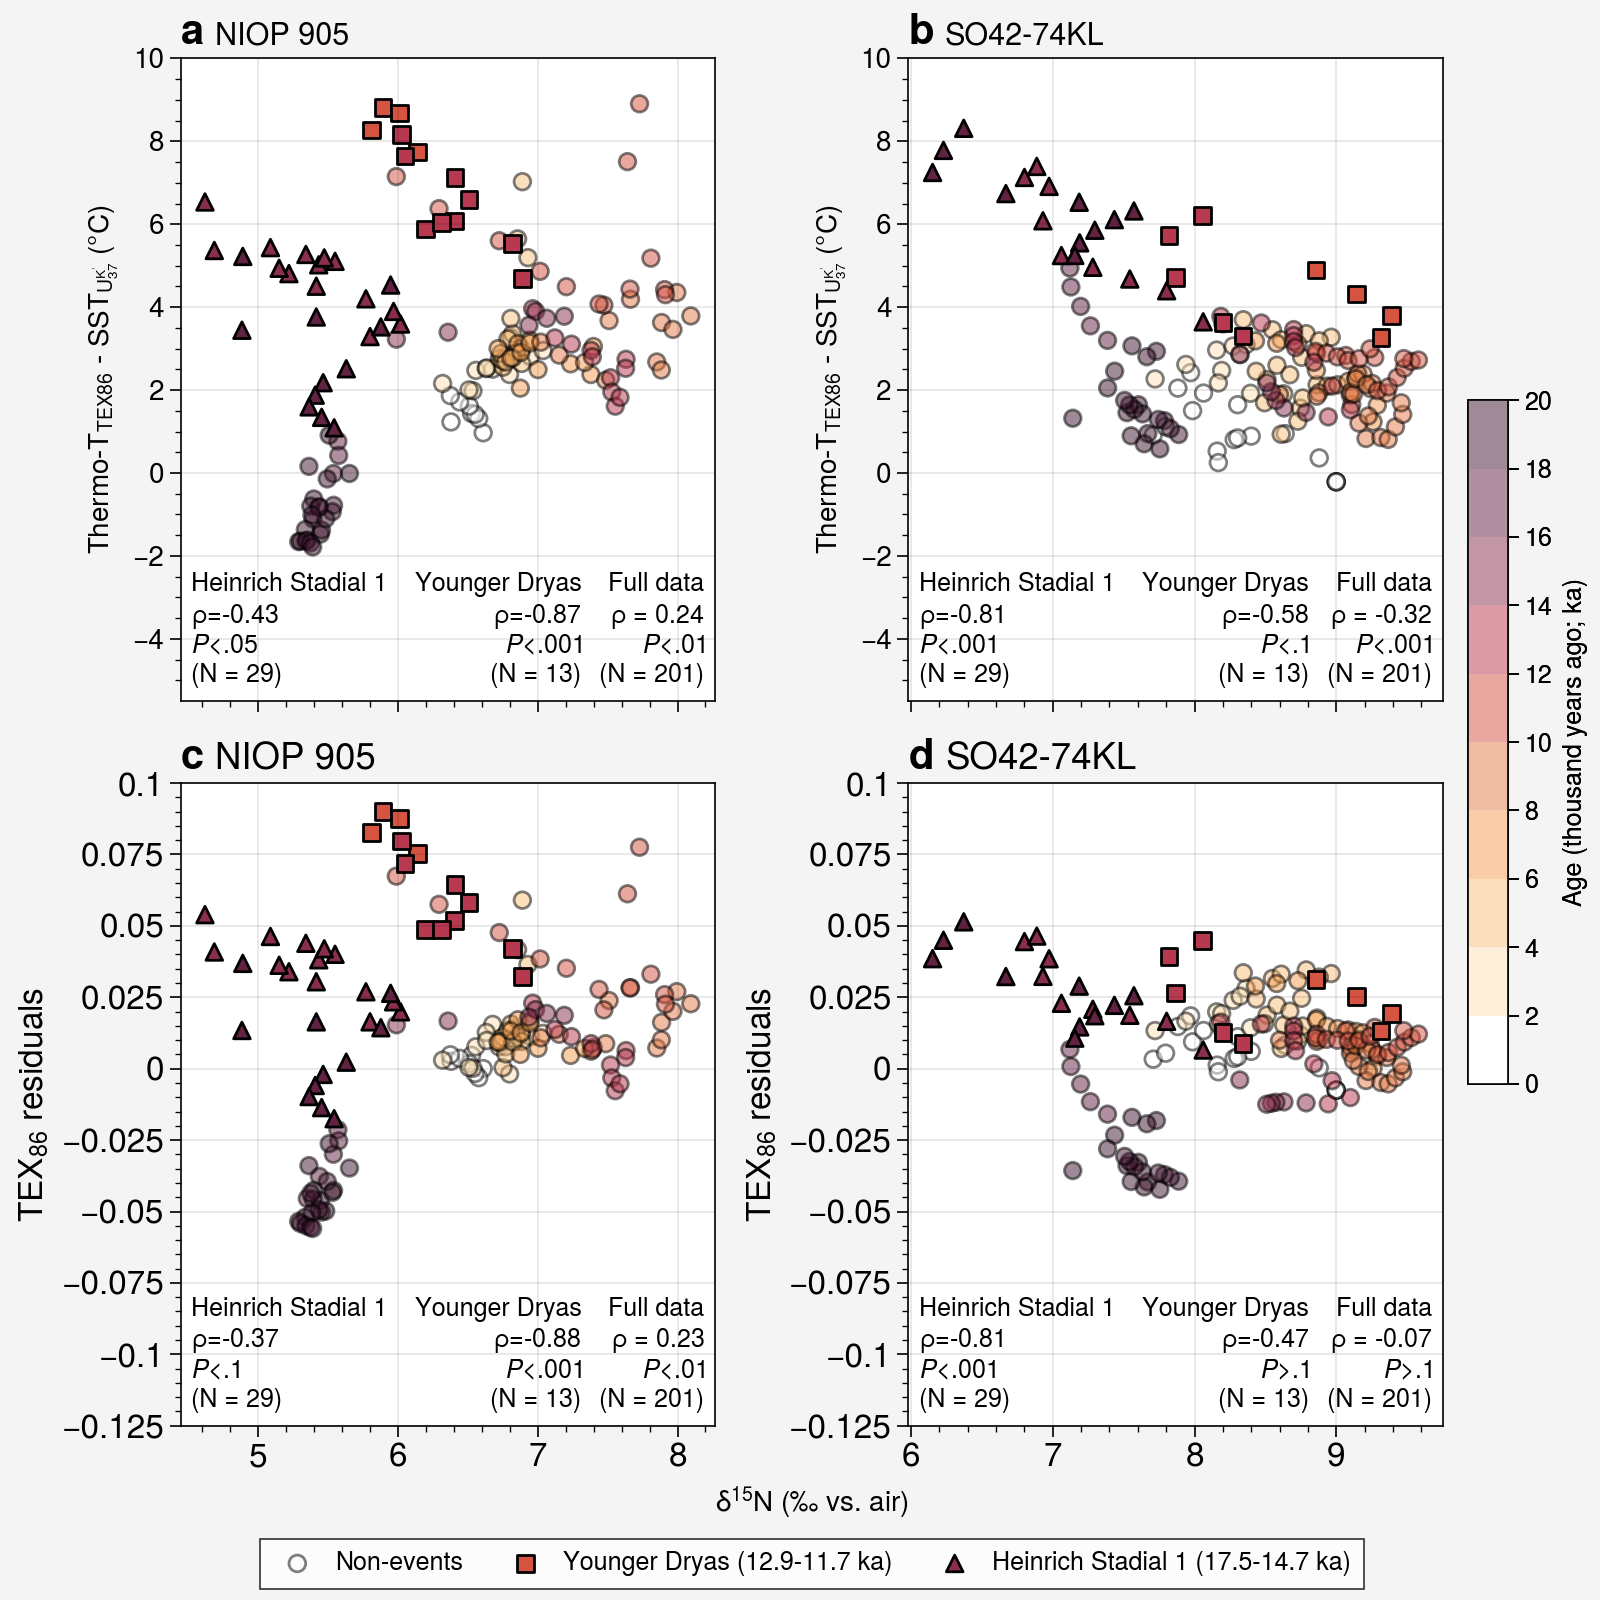

In [67]:

fig, axs = plot.subplots(ncols=2,nrows=2,
                         figsize=(8,8),
                         sharey=0)

grouped = paleo_df.groupby('core_name')
for i, (name, group) in enumerate(grouped):
        ax = axs[0,i]
        ax.format(
                ltitle=name,
                fontsize=10
        )
        group = group.sort_values(by='Age').reset_index(drop=True)
        ### calculate spearman rho and pval between d15N and delta_SST
        reg_data = group[['d15N','delta_SST']].dropna()
        rho, pval = spearmanr(reg_data['d15N'],reg_data['delta_SST'])
        pval_label = label_pvalues(pval)
        ax.text(0.98,0.02,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(group)})',
                transform=ax.transAxes,
                ha='right',va='bottom')
        
        
        group_YD = group[(group['Age']>=11.7) & (group['Age']<=12.9)]
        ### calculate spearman rho and pval between d15N and delta_SST during YD
        reg_data_YD = group_YD[['d15N','delta_SST']].dropna()
        rho_YD, pval_YD = spearmanr(reg_data_YD['d15N'],reg_data_YD['delta_SST'])
        pval_label_YD = label_pvalues(pval_YD)
        ax.text(0.75,0.02,f'Younger Dryas\n$\\rho$={rho_YD:.2f}\n{pval_label_YD}\n(N = {len(group_YD)})',
                transform=ax.transAxes,
                ha='right',va='bottom')
        
        group_HS1 = group[(group['Age']>=14.7) & (group['Age']<=17.5)]
        ### calculate spearman rho and pval between d15N and delta_SST during HS1
        reg_data_HS1 = group_HS1[['d15N','delta_SST']].dropna()
        rho_HS1, pval_HS1 = spearmanr(reg_data_HS1['d15N'],reg_data_HS1['delta_SST'])
        pval_label_HS1 = label_pvalues(pval_HS1)
        ax.text(0.02,0.02,f'Heinrich Stadial 1\n$\\rho$={rho_HS1:.2f}\n{pval_label_HS1}\n(N = {len(group_HS1)})',
                transform=ax.transAxes,
                ha='left',va='bottom')
        group_nonYDHS1 = group[(group['Age']<11.7) | (group['Age']>12.9) & ((group['Age']<14.7) | (group['Age']>17.5))]
        
        ### plot non-events data
        plot_x = group_nonYDHS1['d15N']
        plot_y = group_nonYDHS1['delta_SST']
        plot_c = group_nonYDHS1['Age']
        m = ax.scatter(plot_x,plot_y,
                        c=plot_c,levels=np.arange(0,20.1,2),
                        mec='k',lw=1,label='Non-events',
                        alpha=0.5)
        
        ### plot YD and HS1 data
        plot_x = group_YD['d15N']
        plot_y = group_YD['delta_SST']
        plot_c = group_YD['Age']
        ax.scatter(plot_x,plot_y,m='s',
                c=plot_c,levels=np.arange(0,20.1,2),
                mec='k',lw=1,label='Younger Dryas (12.9-11.7 ka)',)
        
        plot_x = group_HS1['d15N']
        plot_y = group_HS1['delta_SST']
        plot_c = group_HS1['Age']
        ax.scatter(plot_x,plot_y,m='^',
                c=plot_c,levels=np.arange(0,20.1,2),
                mec='k',lw=1,label='Heinrich Stadial 1 (17.5-14.7 ka)',)
        
        ### plot d15N vs tex_residuals
        ax = axs[1,i]
        ax.format(
                ltitle=name,
                fontsize=12
        )
        
        group = group.sort_values(by='Age').reset_index(drop=True)
        ### calculate spearman rho and pval between d15N and delta_SST
        reg_data = group[['d15N','tex_residual']].dropna()
        rho, pval = spearmanr(reg_data['d15N'],reg_data['tex_residual'])
        pval_label = label_pvalues(pval)
        ax.text(0.98,0.02,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(group)})',
                transform=ax.transAxes,
                ha='right',va='bottom')
        group_YD = group[(group['Age']>=11.7) & (group['Age']<=12.9)]
        ### calculate spearman rho and pval between d15N and delta_SST during YD
        reg_data_YD = group_YD[['d15N','tex_residual']].dropna()
        rho_YD, pval_YD = spearmanr(reg_data_YD['d15N'],reg_data_YD['tex_residual'])
        pval_label_YD = label_pvalues(pval_YD)
        ax.text(0.75,0.02,f'Younger Dryas\n$\\rho$={rho_YD:.2f}\n{pval_label_YD}\n(N = {len(group_YD)})',
                transform=ax.transAxes,
                ha='right',va='bottom')
        group_HS1 = group[(group['Age']>=14.7) & (group['Age']<=17.5)]
        ### calculate spearman rho and pval between d15N and delta_SST during YD
        reg_data_HS1 = group_HS1[['d15N','tex_residual']].dropna()
        rho_HS1, pval_HS1 = spearmanr(reg_data_HS1['d15N'],reg_data_HS1['tex_residual'])
        pval_label_HS1 = label_pvalues(pval_HS1)
        ax.text(0.02,0.02,f'Heinrich Stadial 1\n$\\rho$={rho_HS1:.2f}\n{pval_label_HS1}\n(N = {len(group_HS1)})',
                transform=ax.transAxes,
                ha='left',va='bottom')
        group_nonYDHS1 = group[(group['Age']<11.7) | (group['Age']>12.9) & ((group['Age']<14.7) | (group['Age']>17.5))]
        ### plot non-events data
        plot_x = group_nonYDHS1['d15N']
        plot_y = group_nonYDHS1['tex_residual']
        plot_c = group_nonYDHS1['Age']
        m = ax.scatter(plot_x,plot_y,
                        c=plot_c,levels=np.arange(0,20.1,2),
                        mec='k',lw=1,label='Non-events',
                        alpha=0.5)
        
        ### plot YD and HS1 data
        plot_x = group_YD['d15N']
        plot_y = group_YD['tex_residual']
        plot_c = group_YD['Age']
        ax.scatter(plot_x,plot_y,m='s',
                c=plot_c,levels=np.arange(0,20.1,2),
                mec='k',lw=1,label='Younger Dryas (12.9-11.7 ka)',)
        
        plot_x = group_HS1['d15N']
        plot_y = group_HS1['tex_residual']
        plot_c = group_HS1['Age']
        ax.scatter(plot_x,plot_y,m='^',
                c=plot_c,levels=np.arange(0,20.1,2),
                mec='k',lw=1,label='Heinrich Stadial 1 (17.5-14.7 ka)',)
        
        
        

    
h, l = axs[0].get_legend_handles_labels()
fig.legend(h,l,loc='bottom',c='k')

axs[0,:].format(
        xlabel='$\delta^{15}$N (‰ vs. air)',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        ylim=(-5.5,10)
)

axs[1,:].format(
        xlabel='$\delta^{15}$N (‰ vs. air)',
        ylabel=r"TEX$_{86}$ residuals",
        ylim=(-0.125,0.1)
        )

# axs[2,:].format(
#         xlabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
#         ylabel=r"TEX$_{86}$ residuals",
#         ylim=(-0.125,0.1)
#         )

axs.format(abc='a',abcloc='l',
           rc_kw={'abc.size':15})
    
### add colorbar
fig.colorbar(m,loc='r',label='Age (thousand years ago; ka)',shrink=0.5)

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S8_paleo_showcase_d15N_deltaSST_ArabianSea.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300,bbox_inches='tight',embed_fonts=True)

In [68]:
DSDP591_merged_df = pd.merge(DSDP591_uk37_df,DSDP591_tex86_df,
                            how='inner',on=['Depth_mbsf','Depth_mbsf'])
DSDP591_merged_df['sst_diff'] = DSDP591_merged_df['subt_new'] - DSDP591_merged_df['SST_bayspline']
display(DSDP591_merged_df)

IODPU1510_merged_df = pd.merge(IODPU1510_uk37_df,IODPU1510_tex86_df,
                            how='inner',on=['Depth_mbsf','Depth_mbsf'])
IODPU1510_merged_df['sst_diff'] = IODPU1510_merged_df['subt_new'] - IODPU1510_merged_df['SST_bayspline']
IODPU1510_merged_df = IODPU1510_merged_df[IODPU1510_merged_df['uk37_conc_ng_g']<8000].reset_index(drop=True)
display(IODPU1510_merged_df)

,Depth_mbsf,Age_x,uk37,SST_bayspline,uk37_conc_ng_g,Age_y,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m,sst_diff
0,0.0800,3.7333,0.7803,21.5670,60.1421,3.7333,0.6421,0.0376,0.2215,34.7351,25.4377,26.2825,15.9661,6.7420,25.5248,24.1769,20.1740,3.9578
1,0.1300,6.0667,0.7821,21.6121,55.2160,6.0667,0.6422,0.0531,0.2209,31.2206,25.4445,26.4147,10.1822,7.3327,25.5367,24.1408,20.1794,3.9247
2,0.1500,7.0000,0.7784,21.5189,42.3467,7.0000,0.6544,0.0497,0.2256,33.1066,26.0049,27.0389,5.3064,7.0530,26.5358,25.0305,20.6276,5.0170
3,0.2100,9.8000,0.7586,20.9047,51.5504,9.8000,0.6687,0.2402,0.2060,33.4894,26.6438,28.1010,4.7224,6.7164,27.6980,25.7192,21.1386,6.7934
4,0.2600,12.1333,0.7519,20.7060,51.6537,12.1333,0.6160,0.1937,0.2178,32.8025,24.2080,24.4703,3.0878,6.4497,23.3980,22.4670,19.1906,2.6920
5,0.3000,14.0000,0.6929,18.9267,967.4542,14.0000,0.6273,0.1672,0.2038,32.6273,24.7472,25.2692,4.7964,7.0317,24.3198,23.2474,19.6218,5.3931
6,0.3600,15.2632,0.7450,20.4948,61.1464,15.2632,0.6399,0.1270,0.2088,33.6796,25.3388,26.1571,10.8396,6.9723,25.3504,23.9995,20.0949,4.8556
7,0.3800,15.6842,0.7080,19.3682,95.8060,15.6842,0.6205,0.1982,0.1928,32.6629,24.4252,24.7689,12.3521,7.1717,23.7672,22.7524,19.3643,4.3991
8,0.4100,16.3158,0.7030,19.2093,103.4530,16.3158,0.6335,0.2808,0.1908,33.0868,25.0406,25.7467,18.6393,7.2643,24.8283,23.6242,19.8564,5.6191
9,0.4500,17.1579,0.6884,18.7824,192.9993,17.1579,0.5572,0.1080,0.1914,38.7403,21.2283,20.8631,52.9443,6.6025,18.5956,18.7847,16.8077,-0.1868


,Depth_mbsf,Age_x,uk37,SST_bayspline,uk37_conc_ng_g,Age_y,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m,sst_diff
0,0.0700,1.4651,0.6335,17.1269,83.5713,1.4651,0.5573,0.0289,0.2026,40.0189,21.2341,19.8962,41.7409,7.6450,18.6044,17.9588,16.8123,1.4775
1,0.2600,5.4419,0.6981,19.0839,58.1933,5.4419,0.6051,0.2859,0.2115,39.1803,23.6774,23.0845,13.5792,6.6879,22.5073,21.0771,18.7663,3.4233
2,0.3900,8.1628,0.6731,18.3331,85.3466,8.1628,0.5867,0.2219,0.2187,39.8798,22.7586,21.7442,29.9760,6.1144,21.0018,19.9302,18.0315,2.6687
3,0.4800,10.0465,0.6598,17.9272,117.0404,10.0465,0.5844,0.0681,0.2030,37.3392,22.6425,21.7445,111.2544,8.5746,20.8149,19.7274,17.9387,2.8877
4,0.6000,12.5581,0.6488,17.6053,174.6079,12.5581,0.5572,0.0931,0.2382,43.7782,21.2256,19.9518,116.0566,8.4501,18.5915,18.0167,16.8056,0.9862
5,0.7200,15.0698,0.5688,15.2184,233.4698,15.0698,0.4984,0.0571,0.2122,45.2189,17.9156,16.1339,252.0179,10.8876,13.7925,14.3203,14.1585,-1.4259
6,0.8400,17.5814,0.5270,13.9621,519.8478,17.5814,0.4597,0.0589,0.2360,52.3594,15.5112,13.6715,480.4127,7.0630,10.6270,11.9913,12.2357,-3.3352
7,0.9300,21.0800,0.5254,13.9143,435.8783,21.0800,0.4297,0.0383,0.2238,52.6999,13.5093,11.5820,696.4507,8.5700,8.1799,10.0799,10.6348,-5.7344
8,0.9800,23.2800,0.5373,14.2667,421.6222,23.2800,0.4560,0.0581,0.2391,53.0676,15.2734,13.3194,463.6241,7.2519,10.3275,11.6651,12.0455,-3.9391
9,1.0600,26.8000,0.5656,15.1016,493.3082,26.8000,0.4486,0.0541,0.1959,51.2852,14.7844,12.8990,463.9540,7.6608,9.7195,11.1987,11.6545,-5.3821


## Fig. S9. alkenone concentrations vs SST anomalies

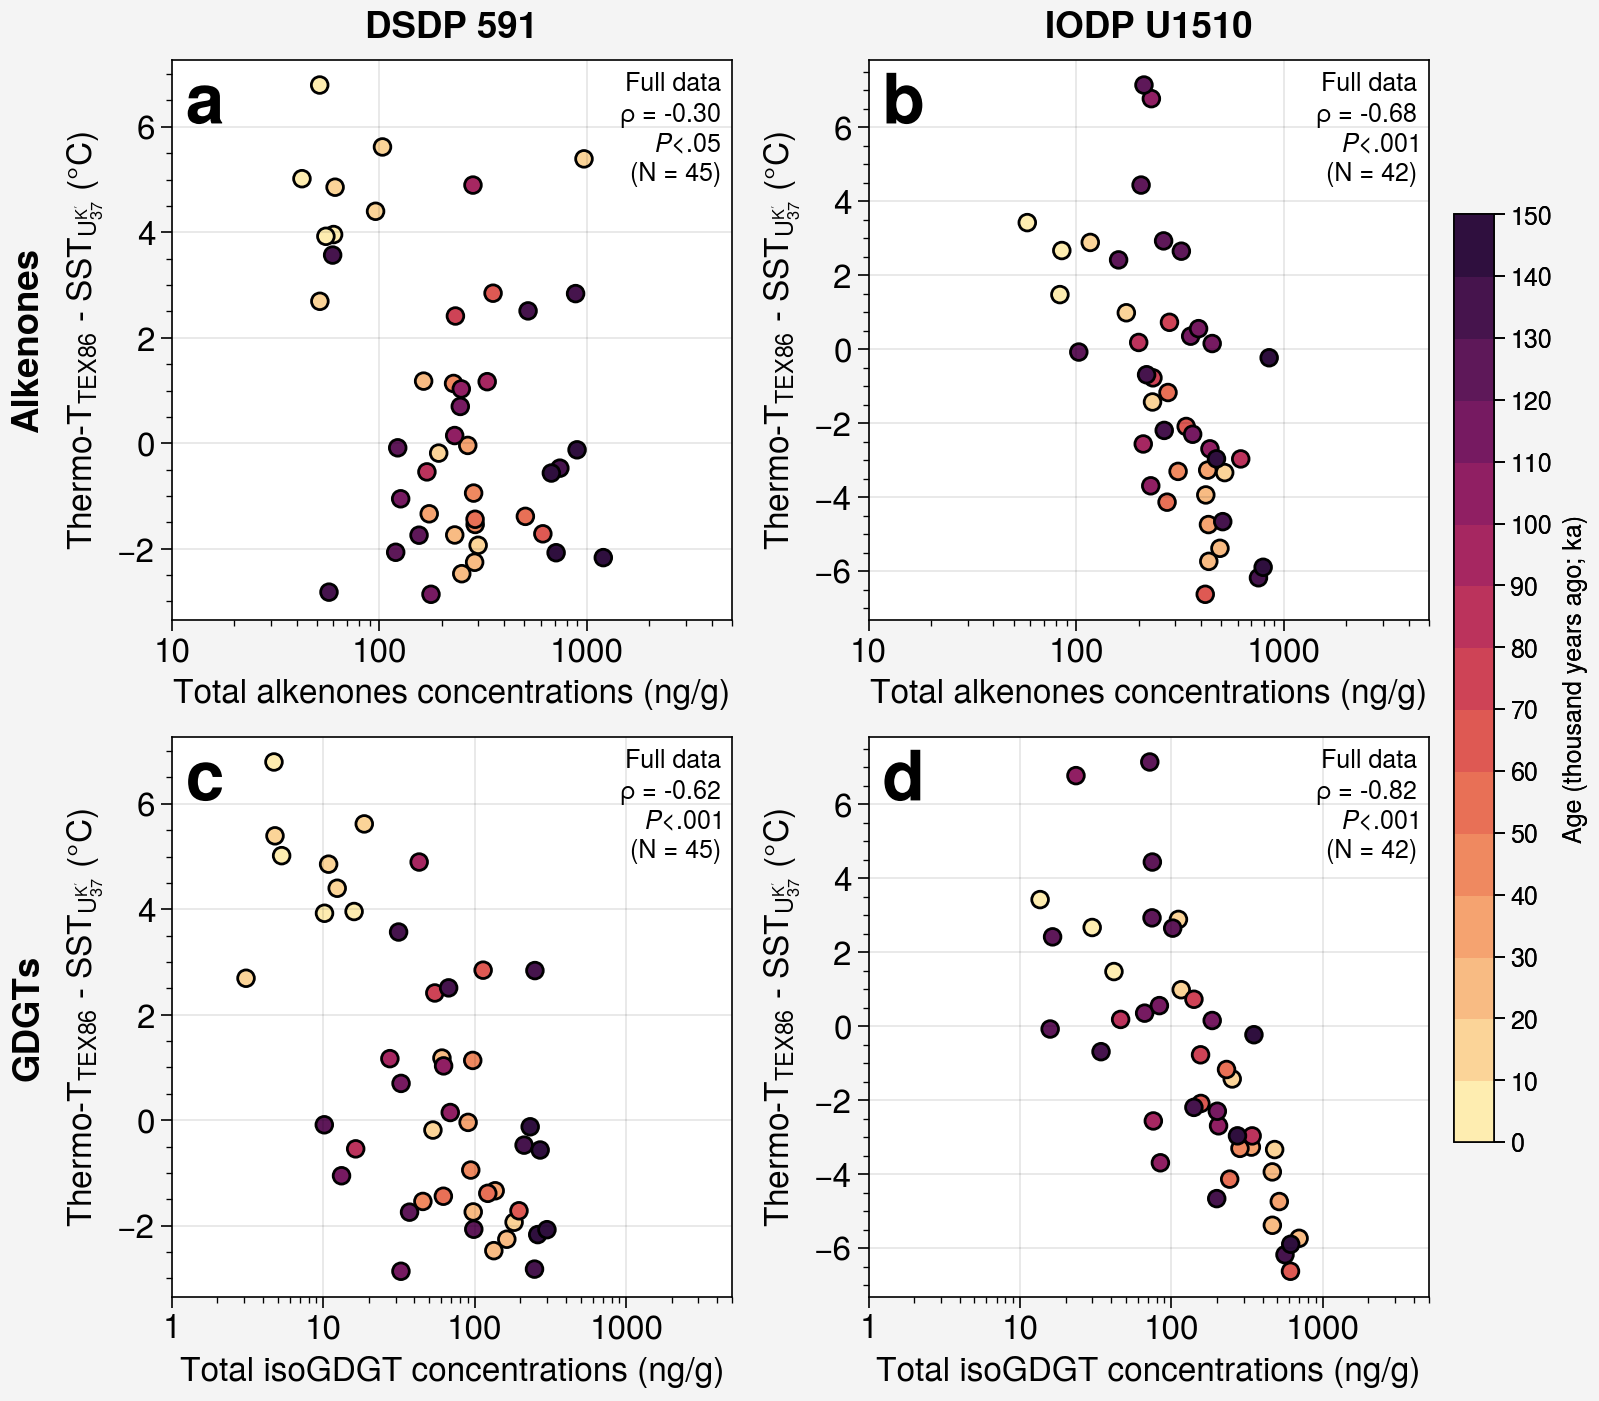

In [69]:
fig, axs = plot.subplots(ncols=2,
                         nrows=2,
                         width=8,
                         share=0)

axs.format(
    collabels=['DSDP 591','IODP U1510'],
    rowlabels=['Alkenones','GDGTs'],
    fontsize=12,
    abc='a',abcloc='ul',rc_kw={'abc.size':25}
)

plot_data = DSDP591_merged_df
plot_x = plot_data['uk37_conc_ng_g']
plot_y = plot_data['sst_diff']
plot_c = plot_data['Age_x']
ax = axs[0,0]
ax.scatter(plot_x,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)

### spearman rho and pval
reg_data = plot_data[['uk37_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['uk37_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[1,0]
plot_x2 = plot_data['gdgt_conc_ng_g']
ax.scatter(plot_x2,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)

### spearman rho and pval
reg_data = plot_data[['gdgt_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['gdgt_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

##################################################################################
plot_data = IODPU1510_merged_df
plot_x = plot_data['uk37_conc_ng_g']
plot_y = plot_data['sst_diff']
plot_c = plot_data['Age_x']
ax = axs[0,1]
m=ax.scatter(plot_x,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)
### spearman rho and pval
reg_data = plot_data[['uk37_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['uk37_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[1,1]
plot_x2 = plot_data['gdgt_conc_ng_g']
ax.scatter(plot_x2,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)
### spearman rho and pval
reg_data = plot_data[['gdgt_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['gdgt_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

#################################################################
axs[0,:].format(
        xlabel='Total alkenones concentrations (ng/g)',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        xlim=(1e1,5000),
        xscale='log',
)
axs[1,:].format(
        xlabel='Total isoGDGT concentrations (ng/g)',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        xlim=(1e0,5000),
        xscale='log',
)
    
### add colorbar
fig.colorbar(m,loc='r',label='Age (thousand years ago; ka)',shrink=0.75)

# fpath = fr'{local_github_path}/figures/'
# fname = 'Fig_S9_paleo_showcase_alkenoneConc_deltaSST_ArabianSea.pdf'
# fig.savefig(os.path.join(fpath,fname),dpi=300,bbox_inches='tight',embed_fonts=True)

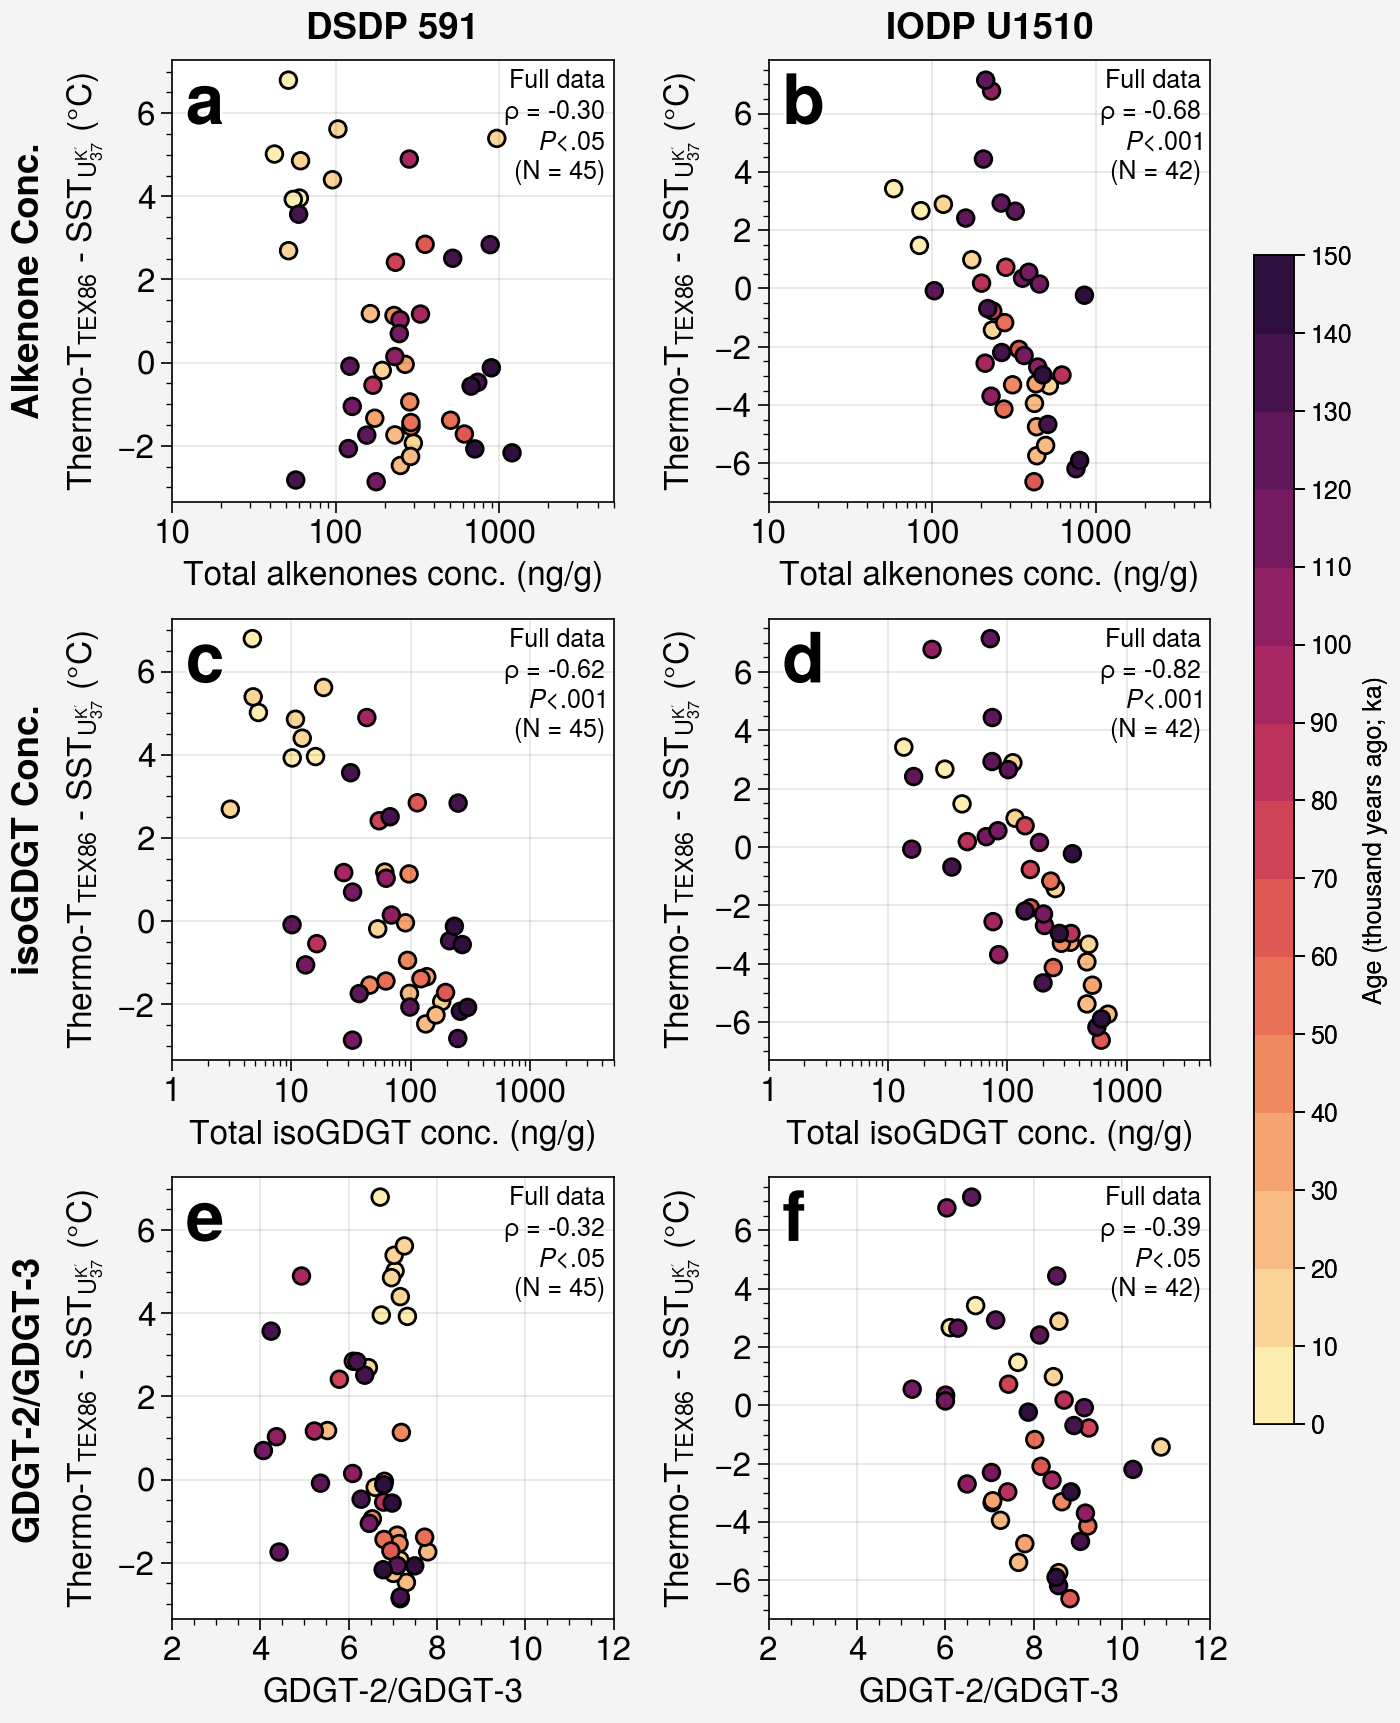

In [70]:
fig, axs = plot.subplots(ncols=2,
                         nrows=3,
                         width=7,
                         share=0)



plot_data = DSDP591_merged_df
plot_x = plot_data['uk37_conc_ng_g']
plot_y = plot_data['sst_diff']
plot_c = plot_data['Age_x']
ax = axs[0,0]
ax.scatter(plot_x,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)

### spearman rho and pval
reg_data = plot_data[['uk37_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['uk37_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[1,0]
plot_x2 = plot_data['gdgt_conc_ng_g']
ax.scatter(plot_x2,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)

### spearman rho and pval
reg_data = plot_data[['gdgt_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['gdgt_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[2,0]
plot_x3 = plot_data['GDGT-2/GDGT-3']
ax.scatter(plot_x3,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)

### spearman rho and pval
reg_data = plot_data[['GDGT-2/GDGT-3','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['GDGT-2/GDGT-3'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

##################################################################################
plot_data = IODPU1510_merged_df
plot_x = plot_data['uk37_conc_ng_g']
plot_y = plot_data['sst_diff']
plot_c = plot_data['Age_x']
ax = axs[0,1]
m=ax.scatter(plot_x,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)
### spearman rho and pval
reg_data = plot_data[['uk37_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['uk37_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[1,1]
plot_x2 = plot_data['gdgt_conc_ng_g']
ax.scatter(plot_x2,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)
### spearman rho and pval
reg_data = plot_data[['gdgt_conc_ng_g','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['gdgt_conc_ng_g'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

ax = axs[2,1]
plot_x3 = plot_data['GDGT-2/GDGT-3']
ax.scatter(plot_x3,plot_y,
           c=plot_c,cmap='matter',
           levels=np.arange(0,151,10),
           mec='k',lw=1)
### spearman rho and pval
reg_data = plot_data[['GDGT-2/GDGT-3','sst_diff']].dropna()
rho, pval = spearmanr(reg_data['GDGT-2/GDGT-3'],reg_data['sst_diff'])
pval_label = label_pvalues(pval)
ax.text(0.98,0.98,f'Full data\n$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(plot_data)})',
        transform=ax.transAxes,va='top',ha='right')

#################################################################
axs[0,:].format(
        xlabel='Total alkenones conc. (ng/g)',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        xlim=(1e1,5000),
        xscale='log',
)
axs[1,:].format(
        xlabel='Total isoGDGT conc. (ng/g)',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        xlim=(1e0,5000),
        xscale='log',
)

axs[2,:].format(
        xlabel='GDGT-2/GDGT-3',
        ylabel=r"Thermo-T$_{TEX86}$ - SST$_{U^{K'}_{37}}$ ($\degree$C)",
        xlim=(2,12),
)
    
### add colorbar
fig.colorbar(m,loc='r',label='Age (thousand years ago; ka)',shrink=0.75)


axs.format(
    collabels=['DSDP 591','IODP U1510'],
    rowlabels=['Alkenone Conc.','isoGDGT Conc.','GDGT-2/GDGT-3'],
    fontsize=12,
    abc='a',abcloc='ul',rc_kw={'abc.size':25}
)

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S9_paleo_showcase_alkenoneConc_deltaSST_ArabianSea.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300,bbox_inches='tight',embed_fonts=True)

In [71]:
### create a dataframe that contains uk_sst, tex_sst, and d15N for both sites
age_step = np.arange(0,150.1,5)

### get interpolated alkenone and GDGT concentrations to the same time step with LR04 stack for DSDP 591
LR04_benthic_interp = np.interp(age_step,LR04_benthic_df['Age_kyrBP'],LR04_benthic_df['d18O_benthic'])
alkenone_conc_591 = np.interp(age_step,DSDP591_merged_df['Age_x'],DSDP591_merged_df['uk37_conc_ng_g'])
gdgt_conc_591 = np.interp(age_step,DSDP591_merged_df['Age_x'],DSDP591_merged_df['gdgt_conc_ng_g'])
core_name_repeat = ['DSDP 591']*len(age_step)
core_name_repeat = pd.Series(core_name_repeat).astype('category')

### build a df for DSDP 591
DSDP591_df = pd.DataFrame({'Age':age_step,
                            'LR04_benthic':LR04_benthic_interp,
                            'alkenone_conc':alkenone_conc_591,
                            'gdgt_conc':gdgt_conc_591,
                            'core_name':core_name_repeat})


### get interpolated alkenone and GDGT concentrations to the same time step with LR04 stack for IODP U1510
alkenone_conc_U1510 = np.interp(age_step,IODPU1510_merged_df['Age_x'],IODPU1510_merged_df['uk37_conc_ng_g'])
gdgt_conc_U1510 = np.interp(age_step,IODPU1510_merged_df['Age_x'],IODPU1510_merged_df['gdgt_conc_ng_g'])
core_name_repeat = ['IODP U1510']*len(age_step)
core_name_repeat = pd.Series(core_name_repeat).astype('category')

### build a df for IODP U1510
IODPU1510_df = pd.DataFrame({'Age':age_step,
                            'LR04_benthic':LR04_benthic_interp,
                            'alkenone_conc':alkenone_conc_U1510,
                            'gdgt_conc':gdgt_conc_U1510,
                            'core_name':core_name_repeat})

### join two dataframes
paleo_df = pd.concat([DSDP591_df,IODPU1510_df],ignore_index=True)
paleo_df['core_name'] = paleo_df['core_name'].astype('category')
paleo_df




,Age,LR04_benthic,alkenone_conc,gdgt_conc,core_name
0,0.0000,3.2300,60.1421,15.9661,DSDP 591
1,5.0000,3.2600,57.4679,12.8263,DSDP 591
2,10.0000,3.5200,51.5592,4.5823,DSDP 591
3,15.0000,4.4900,249.9605,9.5806,DSDP 591
4,20.0000,4.9900,259.6604,143.7470,DSDP 591
...,...,...,...,...,...
57,130.0000,3.6700,196.7403,27.5920,IODP U1510
58,135.0000,4.8600,508.7969,199.1407,IODP U1510
59,140.0000,4.9800,780.0268,592.3855,IODP U1510
60,145.0000,4.7400,612.2430,418.4452,IODP U1510


## Fig. S10. Alkenone concentrations vs d18O

In [72]:
### interpolate LR04 to the same time step of paleo records
### site DSDP 591
age_steps = DSDP591_merged_df['Age_x'].values
LR04_benthic_interp_dsdp519 = np.interp(age_steps,LR04_benthic_df['Age_kyrBP'],LR04_benthic_df['d18O_benthic'])

DSDP591_merged_df['LR04_benthic'] = LR04_benthic_interp_dsdp519
display(DSDP591_merged_df)

age_steps = IODPU1510_merged_df['Age_x'].values
LR04_benthic_interp_IODPU1510 = np.interp(age_steps,LR04_benthic_df['Age_kyrBP'],LR04_benthic_df['d18O_benthic'])
IODPU1510_merged_df['LR04_benthic'] = LR04_benthic_interp_IODPU1510
IODPU1510_merged_df

,Depth_mbsf,Age_x,uk37,SST_bayspline,uk37_conc_ng_g,Age_y,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m,sst_diff,LR04_benthic
0,0.0800,3.7333,0.7803,21.5670,60.1421,3.7333,0.6421,0.0376,0.2215,34.7351,25.4377,26.2825,15.9661,6.7420,25.5248,24.1769,20.1740,3.9578,3.2973
1,0.1300,6.0667,0.7821,21.6121,55.2160,6.0667,0.6422,0.0531,0.2209,31.2206,25.4445,26.4147,10.1822,7.3327,25.5367,24.1408,20.1794,3.9247,3.3327
2,0.1500,7.0000,0.7784,21.5189,42.3467,7.0000,0.6544,0.0497,0.2256,33.1066,26.0049,27.0389,5.3064,7.0530,26.5358,25.0305,20.6276,5.0170,3.3700
3,0.2100,9.8000,0.7586,20.9047,51.5504,9.8000,0.6687,0.2402,0.2060,33.4894,26.6438,28.1010,4.7224,6.7164,27.6980,25.7192,21.1386,6.7934,3.4920
4,0.2600,12.1333,0.7519,20.7060,51.6537,12.1333,0.6160,0.1937,0.2178,32.8025,24.2080,24.4703,3.0878,6.4497,23.3980,22.4670,19.1906,2.6920,3.9387
5,0.3000,14.0000,0.6929,18.9267,967.4542,14.0000,0.6273,0.1672,0.2038,32.6273,24.7472,25.2692,4.7964,7.0317,24.3198,23.2474,19.6218,5.3931,4.2800
6,0.3600,15.2632,0.7450,20.4948,61.1464,15.2632,0.6399,0.1270,0.2088,33.6796,25.3388,26.1571,10.8396,6.9723,25.3504,23.9995,20.0949,4.8556,4.5584
7,0.3800,15.6842,0.7080,19.3682,95.8060,15.6842,0.6205,0.1982,0.1928,32.6629,24.4252,24.7689,12.3521,7.1717,23.7672,22.7524,19.3643,4.3991,4.6679
8,0.4100,16.3158,0.7030,19.2093,103.4530,16.3158,0.6335,0.2808,0.1908,33.0868,25.0406,25.7467,18.6393,7.2643,24.8283,23.6242,19.8564,5.6191,4.7911
9,0.4500,17.1579,0.6884,18.7824,192.9993,17.1579,0.5572,0.1080,0.1914,38.7403,21.2283,20.8631,52.9443,6.6025,18.5956,18.7847,16.8077,-0.1868,4.9021


,Depth_mbsf,Age_x,uk37,SST_bayspline,uk37_conc_ng_g,Age_y,TEX86,BIT,MI,%GDGT-0,TEX86H-derived SST,BAYSPAR-derived SST,gdgt_conc_ng_g,GDGT-2/GDGT-3,subt_new,subT_bsr,subT_kim12_0_200m,sst_diff,LR04_benthic
0,0.0700,1.4651,0.6335,17.1269,83.5713,1.4651,0.5573,0.0289,0.2026,40.0189,21.2341,19.8962,41.7409,7.6450,18.6044,17.9588,16.8123,1.4775,3.2067
1,0.2600,5.4419,0.6981,19.0839,58.1933,5.4419,0.6051,0.2859,0.2115,39.1803,23.6774,23.0845,13.5792,6.6879,22.5073,21.0771,18.7663,3.4233,3.2909
2,0.3900,8.1628,0.6731,18.3331,85.3466,8.1628,0.5867,0.2219,0.2187,39.8798,22.7586,21.7442,29.9760,6.1144,21.0018,19.9302,18.0315,2.6687,3.4135
3,0.4800,10.0465,0.6598,17.9272,117.0404,10.0465,0.5844,0.0681,0.2030,37.3392,22.6425,21.7445,111.2544,8.5746,20.8149,19.7274,17.9387,2.8877,3.5237
4,0.6000,12.5581,0.6488,17.6053,174.6079,12.5581,0.5572,0.0931,0.2382,43.7782,21.2256,19.9518,116.0566,8.4501,18.5915,18.0167,16.8056,0.9862,3.9981
5,0.7200,15.0698,0.5688,15.2184,233.4698,15.0698,0.4984,0.0571,0.2122,45.2189,17.9156,16.1339,252.0179,10.8876,13.7925,14.3203,14.1585,-1.4259,4.5081
6,0.8400,17.5814,0.5270,13.9621,519.8478,17.5814,0.4597,0.0589,0.2360,52.3594,15.5112,13.6715,480.4127,7.0630,10.6270,11.9913,12.2357,-3.3352,4.9614
7,0.9300,21.0800,0.5254,13.9143,435.8783,21.0800,0.4297,0.0383,0.2238,52.6999,13.5093,11.5820,696.4507,8.5700,8.1799,10.0799,10.6348,-5.7344,4.9076
8,0.9800,23.2800,0.5373,14.2667,421.6222,23.2800,0.4560,0.0581,0.2391,53.0676,15.2734,13.3194,463.6241,7.2519,10.3275,11.6651,12.0455,-3.9391,4.8460
9,1.0600,26.8000,0.5656,15.1016,493.3082,26.8000,0.4486,0.0541,0.1959,51.2852,14.7844,12.8990,463.9540,7.6608,9.7195,11.1987,11.6545,-5.3821,4.7340


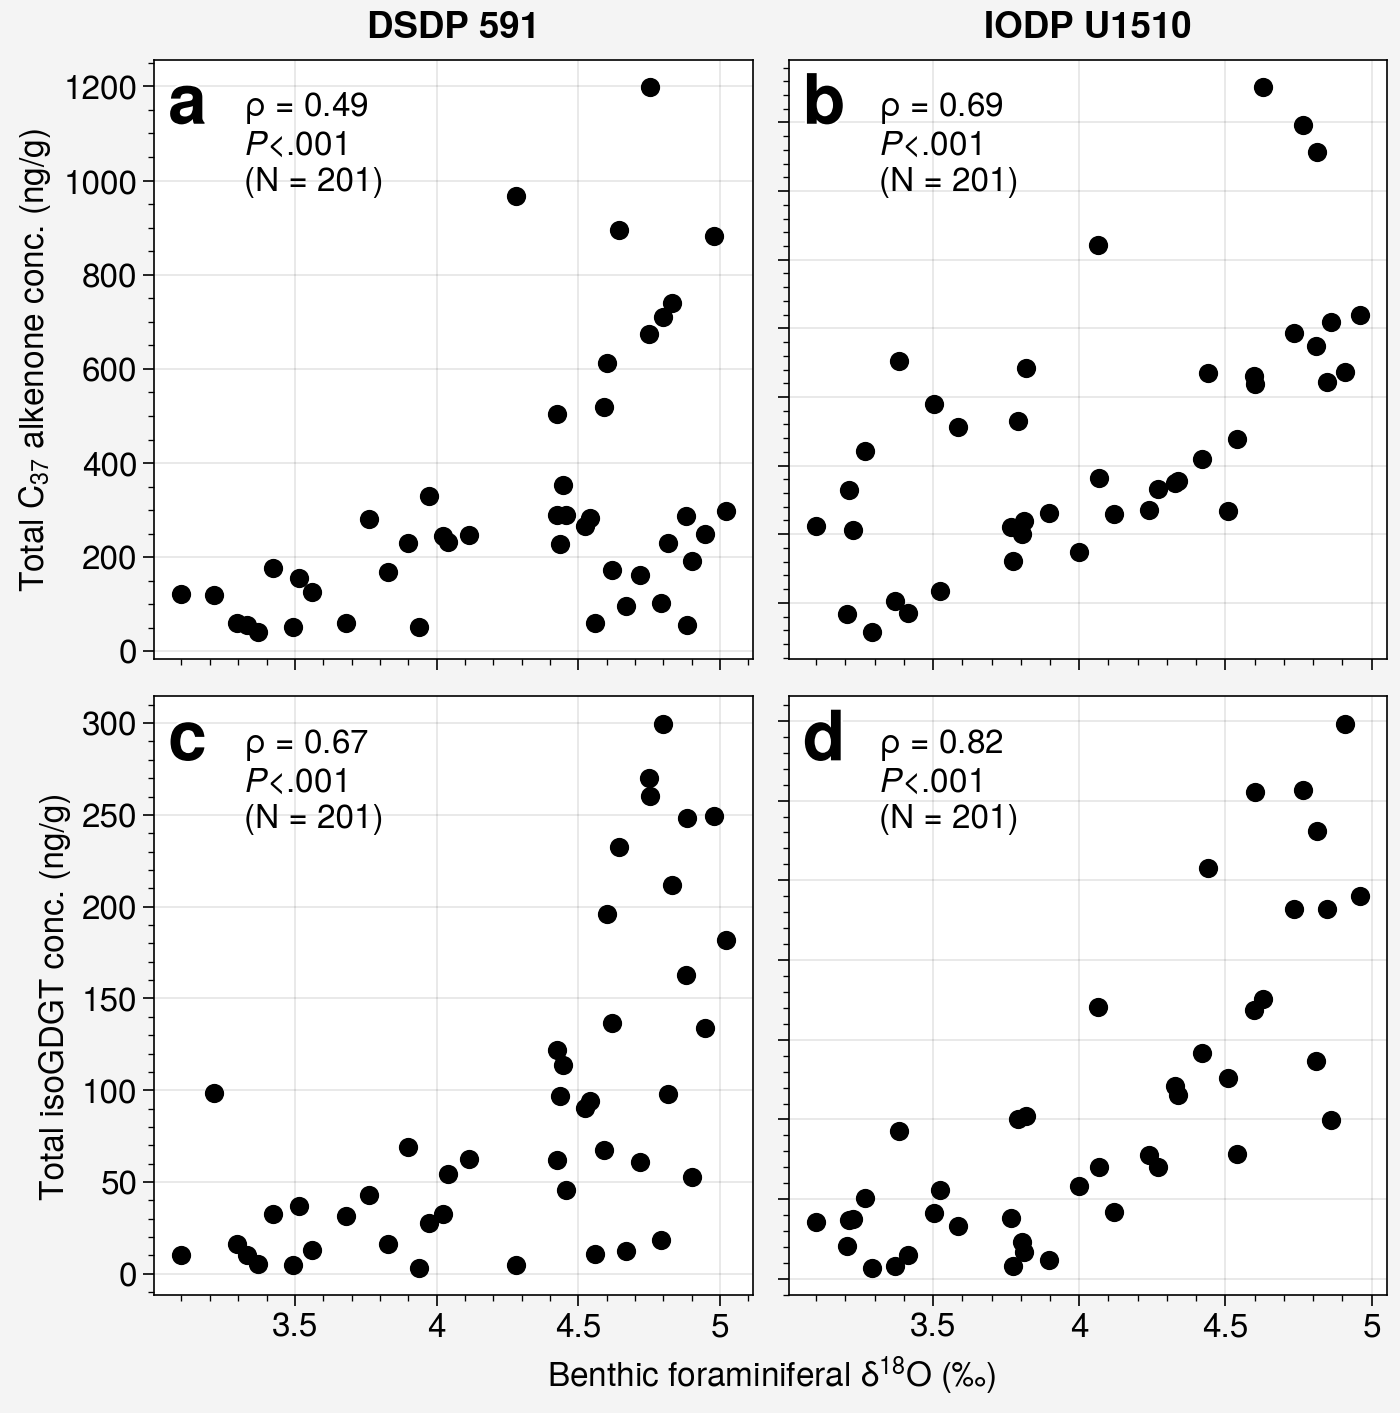

In [73]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

d18o_change_threshold = 0.1
fig, axs = plot.subplots(ncols=2,nrows=2,width=7,sharey=0)
axs.format(
    collabels=['DSDP 591','IODP U1510'],
    fontsize=12,
    abc='a',abcloc='ul',rc_kw={'abc.size':25}
)
y_params = ['uk37_conc_ng_g','gdgt_conc_ng_g']
for i, y_param in enumerate(y_params):
    ax = axs[i,0]

    plot_data = DSDP591_merged_df.sort_values(by='Age_x',ascending=False).reset_index(drop=True)
    plot_x = plot_data['LR04_benthic']
    plot_y = plot_data[y_param]
    ax.scatter(plot_x,plot_y,
            c='k',m='o',s=40,
            zorder=2)
    ### spreadman rho and pval
    reg_data = plot_data[['LR04_benthic',y_param]].dropna()
    rho, pval = spearmanr(reg_data['LR04_benthic'],reg_data[y_param])
    pval_label = label_pvalues(pval)
    ax.text(0.15,0.95,f'$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(group)})',
            transform=ax.transAxes,ha='left',va='top',fontsize=12)


    ax = axs[i,1]

    plot_data = IODPU1510_merged_df.sort_values(by='Age_x',ascending=False).reset_index(drop=True)
    plot_x = plot_data['LR04_benthic']
    plot_y = plot_data[y_param]
    ax.scatter(plot_x,plot_y,
            c='k',m='o',s=40,
            zorder=2)
    ### spreadman rho and pval
    reg_data = plot_data[['LR04_benthic',y_param]].dropna()
    rho, pval = spearmanr(reg_data['LR04_benthic'],reg_data[y_param])
    pval_label = label_pvalues(pval)
    ax.text(0.15,0.95,f'$\\rho$ = {rho:.2f}\n{pval_label}\n(N = {len(group)})',
            transform=ax.transAxes,ha='left',va='top',fontsize=12)


axs[0,:].format(
    xlabel='Benthic foraminiferal $\delta^{18}$O (‰)',
    ylabel='Total C$_{37}$ alkenone conc. (ng/g)',
)
    
    
axs[1,:].format(
    xlabel='Benthic foraminiferal $\delta^{18}$O (‰)',
    ylabel='Total isoGDGT conc. (ng/g)',
)

axs[:,1].format(ylabel='',yticklabels=[])
axs[:,1].format(yticklabels=[])

fpath = fr'{local_github_path}/figures/'
fname = 'Fig_S10_paleo_showcase_alkenoneConc_LR04_TasmanSea.pdf'
fig.savefig(os.path.join(fpath,fname),dpi=300,bbox_inches='tight',embed_fonts=True)